# Module 4 - VSCMG Dynamics

Variable-Speed Control Moment Gyroscopes (VSCMGs) combine the operating principles of **reaction wheels (RWs)** and **control moment gyroscopes (CMGs)**. By controlling both rotor spin speed and gimbal motion, a VSCMG can exchange angular momentum with the spacecraft through two independent actuator motions.

The basic mechanics of momentum-exchange devices were developed in the first *Spacecraft Dynamics and Control* specialization. This module builds on that foundation by revisiting the single-VSCMG model compactly, then extending it to the numerical modeling of spacecraft carrying multiple VSCMGs.

The development follows the progression

$$
\boxed{
\text{geometry and moving frames}
\;\rightarrow\;
\text{inertia and angular momentum}
\;\rightarrow\;
\text{equations of motion}
\;\rightarrow\;
\text{motor torques}
\;\rightarrow\;
\text{numerical simulation}
}
$$

The single-VSCMG model is developed first from its geometry and momentum relations. Reaction-wheel and CMG behavior then appear naturally as special cases of the general VSCMG formulation. The same device-level model is subsequently extended to multiple VSCMGs, with particular attention given to numerical implementation, simulation, and verification using the work-energy principle.

This notebook therefore focuses on **reconstructing, implementing, and verifying** the dynamics rather than repeating the full derivations developed previously.

> **Prior material:**  
> [Specialization 1, Course 2, Module 4 - Equations of Motion with Momentum Exchange Devices](https://github.com/johnm3398/Spacecraft-Dynamics-and-Control/blob/main/01_spacecraft_dynamics_and_control_specialization/02_kinetics/Module%204%20-%20Equations%20of%20Motion%20with%20Momentum%20Exchange%20Devices.ipynb)  
> [Specialization 1, Course 2 - Momentum Exchange Devices Slides](https://github.com/johnm3398/Spacecraft-Dynamics-and-Control/blob/main/01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf)

In [1]:
import numpy as np

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, r"../../")
import AttitudeKinematicsLib as ak

# 1 - Single VSCMG Modeling

## 1.1 - Momentum Exchange Devices and the VSCMG

A **momentum exchange device** controls spacecraft rotation by exchanging angular momentum between an internal rotating assembly and the spacecraft body.

In the absence of external torque, the total angular momentum of the spacecraft-device system is conserved. The actuator therefore does not create angular momentum; instead, an internal motor changes the momentum stored in the device and the spacecraft body responds with an equal and opposite change.

Conceptually,

$$
\boxed{
\text{change device angular momentum}
\;\Longleftrightarrow\;
\text{change spacecraft angular momentum}
}
$$

The three devices of interest differ primarily in **how the internal angular momentum is changed**:

- A **reaction wheel (RW)** has a fixed spin axis. Control is generated by changing the rotor spin rate and therefore the magnitude of its angular momentum.
- A **control moment gyroscope (CMG)** typically maintains a large rotor spin rate and generates control torque by gimbaling the rotor, thereby changing the **direction** of its angular momentum.
- A **variable-speed control moment gyroscope (VSCMG)** allows both the rotor speed and gimbal angle to vary.

A VSCMG therefore combines the two actuation mechanisms:

$$
\boxed{
\dot{\Omega}
\;\rightarrow\;
\text{change momentum magnitude}
}
$$

and

$$
\boxed{
\dot{\gamma}
\;\rightarrow\;
\text{change momentum direction}.
}
$$

This makes the VSCMG the most general of the three models. Reaction-wheel and conventional CMG behavior can later be recovered as special cases by restricting one of these internal motions.

The first step in constructing its equations of motion is therefore to define the geometry of the rotating assembly and the moving basis vectors attached to it.

## 1.2 - VSCMG Geometry and Moving Frames

A VSCMG has two internal motions going on at the same time: the rotor spins about its own axis, while the gimbal rotates that whole rotor assembly about a second axis.

It is easiest to keep track of all of this using the three orthogonal directions shown below.

<img src="Images/VSCMG_Frame.PNG" alt="VSCMG Frame" width="500" align="left" style="margin-right: 20px;"/>

- <ins>**Spin axis**</ins> ($\hat{\mathbf g}_s$)  
  The axis the rotor actually spins about. The rotor spin rate about this axis is $\Omega$.

- <ins>**Gimbal axis**</ins> ($\hat{\mathbf g}_g$)  
  The axis about which the entire rotor-gimbal assembly rotates. This axis is fixed relative to the spacecraft body frame $\mathcal{B}$.

- <ins>**Transverse axis**</ins> ($\hat{\mathbf g}_t$)  
  The third direction needed to complete the right-handed orthonormal triad,

  $$
  \hat{\mathbf g}_t = \hat{\mathbf g}_g \times \hat{\mathbf g}_s.
  $$

- <ins>**Rotor spin rate**</ins> ($\Omega$)  
  The angular velocity of the rotor relative to the gimbal frame about $\hat{\mathbf g}_s$.

- <ins>**Gimbal angle**</ins> ($\gamma$)  
  Describes how far the gimbal has rotated about $\hat{\mathbf g}_g$.

- <ins>**Gimbal rate**</ins> ($\dot{\gamma}$)  
  The angular velocity of the gimbal frame relative to the spacecraft body.

- <ins>**Gimbal frame**</ins> ($\mathcal{G}$)

  $$
  \mathcal{G} =
  \left\{
  \hat{\mathbf g}_s,\,
  \hat{\mathbf g}_t,\,
  \hat{\mathbf g}_g
  \right\}.
  $$

  These three unit vectors define the moving coordinate frame attached to the gimbal assembly.

<br clear="left"/>

The key thing to notice is this: once we bolt the gimbal axis, $\hat{\mathbf g}_g$, to the spacecraft body, that axis becomes fixed with respect to the body frame. The momentum exchange device can then rotate about $\hat{\mathbf g}_g$.

The same is not true for $\hat{\mathbf g}_s$ and $\hat{\mathbf g}_t$. These two axes sit in the rotating gimbal frame, so as the gimbal moves, they rotate about $\hat{\mathbf g}_g$.

The angular velocity of the gimbal frame relative to the spacecraft body is therefore

$$
\boxed{
\boldsymbol{\omega}_{G/B} = \dot{\gamma}\, \hat{\mathbf g}_g.
}
$$

The rotor then has another rotation on top of this: it spins relative to the gimbal frame about $\hat{\mathbf g}_s$,

$$
\boxed{
\boldsymbol{\omega}_{W/G} = \Omega\, \hat{\mathbf g}_s.
}
$$

So there are really two nested rotations taking place:

$$
\boxed{
\mathcal{B}
\;\xrightarrow{\;\dot{\gamma}\hat{\mathbf g}_g\;}
\mathcal{G}
\;\xrightarrow{\;\Omega\hat{\mathbf g}_s\;}
\mathcal{W}.
}
$$

**TO NOTE**: Here, $\mathcal{B}$ is the spacecraft body frame, $\mathcal{G}$ is the gimbal frame, and $\mathcal{W}$ is the spinning rotor frame.

**<ins>How the Gimbal-Frame Axes Move</ins>**

As an observer sitting inside the gimbal frame, $\mathcal G$, the three basis vectors $\hat{\mathbf g}_s$, $\hat{\mathbf g}_t$, and $\hat{\mathbf g}_g$ are, of course, constant. They are the axes that define the frame itself, so from within $\mathcal G$ none of them appear to move.

Things look different when we observe the same axes from the spacecraft body frame, $\mathcal B$. Since the gimbal axis $\hat{\mathbf g}_g$ is bolted to the spacecraft body, it remains fixed relative to $\mathcal B$. The spin and transverse axes, $\hat{\mathbf g}_s$ and $\hat{\mathbf g}_t$, however, rotate about $\hat{\mathbf g}_g$ as the gimbal angle $\gamma$ changes.

Let's write down that motion before taking any derivatives.

To keep the geometry and algebra neat, let's measure the gimbal motion relative to some reference orientation at some intial time, $t_0$. Let

$$
\gamma_0 = \gamma(t_0),
$$

and define the angular displacement from that reference as

$$
\Delta\gamma = \gamma(t) - \gamma_0.
$$

We will take a positive $\Delta\gamma$ to correspond to a positive rotation about $\hat{\mathbf g}_g$ according to the right-hand rule. With that convention fixed, the spin and transverse axes simply rotate within the plane perpendicular to $\hat{\mathbf g}_g$, while $\hat{\mathbf g}_g$ itself remains unchanged in the body frame.

Writing all three axes in **body-frame components**,

$$
\begin{aligned}
\hat{\mathbf g}_s(t) &=  \cos(\Delta\gamma)\hat{\mathbf g}_s(t_0) + \sin(\Delta\gamma)\hat{\mathbf g}_t(t_0), \\
\hat{\mathbf g}_t(t) &= -\sin(\Delta\gamma)\hat{\mathbf g}_s(t_0) + \cos(\Delta\gamma)\hat{\mathbf g}_t(t_0), \\
\hat{\mathbf g}_g(t) &= \hat{\mathbf g}_g(t_0).
\end{aligned}
$$

The reference directions $\hat{\mathbf g}_s(t_0)$, $\hat{\mathbf g}_t(t_0)$, and $\hat{\mathbf g}_g(t_0)$ are constant when expressed in body-frame components. The equations above then describe how the current spin and transverse axes are obtained by rotating those reference directions through the gimbal displacement $\Delta\gamma$.

At this stage, we are only describing the motion of the gimbal frame relative to the spacecraft body. The spacecraft body's own rotation relative to the inertial frame has not yet been included.

**Differentiate the geometry in the body frame.** Since $d(\Delta\gamma)/dt=\dot{\gamma}$,


The spin axis derivative,

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_s}{dt} 
&= \dot{\gamma}\left[-\sin(\Delta\gamma)\hat{\mathbf g}_s(t_0) + \cos(\Delta\gamma)\hat{\mathbf g}_t(t_0)\right] \\
&= \dot{\gamma}\hat{\mathbf g}_t,
\end{aligned}
$$

and the transverse axis derivative, 

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_t}{dt}
&= -\dot{\gamma}\left[\cos(\Delta\gamma)\hat{\mathbf g}_s(t_0) + \sin(\Delta\gamma)\hat{\mathbf g}_t(t_0)\right] \\
&= -\dot{\gamma}\hat{\mathbf g}_s.
\end{aligned}
$$

and, the gimbal axis,

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_g}{dt}
&= {}^B\frac{d}{dt}\hat{\mathbf g}_g(t_0) \\
&= \mathbf 0,
\end{aligned}
$$

since $\hat{\mathbf g}_g(t_0)$ is fixed relative to the spacecraft body frame.

**The same result can be obtained using the kinematic transport theorem.** For any gimbal-fixed basis vector, indexed by $i=s,t,g$,

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_i}{dt}
&= {}^G\frac{d\hat{\mathbf g}_i}{dt} + \boldsymbol{\omega}_{G/B}\times\hat{\mathbf g}_i \\
&= \mathbf 0 + \dot{\gamma}\hat{\mathbf g}_g\times\hat{\mathbf g}_i.
\end{aligned}
$$

The signs follow from the right-handed triad:

$$
\begin{aligned}
\hat{\mathbf g}_g\times\hat{\mathbf g}_s &= \hat{\mathbf g}_t, \\
\hat{\mathbf g}_g\times\hat{\mathbf g}_t &= -\hat{\mathbf g}_s, \\
\hat{\mathbf g}_g\times\hat{\mathbf g}_g &= \mathbf 0.
\end{aligned}
$$

So the three body-frame rates are

$$
\boxed{
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_s}{dt} &= \dot{\gamma}\hat{\mathbf g}_t, \\
{}^B\frac{d\hat{\mathbf g}_t}{dt} &= -\dot{\gamma}\hat{\mathbf g}_s, \\
{}^B\frac{d\hat{\mathbf g}_g}{dt} &= \mathbf 0.
\end{aligned}
}
$$

At this point, we know the geometry of a general gimbaled momentum exchange device and how it moves relative to the spacecraft body. The next question we need to address is, "How do the gimbal and wheel contribute to the angular momentum of the complete spacecraft-device system, and how can we use that momentum to derive its equations of motion?"

To answer that, we first need to describe the inertia of the gimbal and wheel, then build up the total angular momentum of the system.

## 1.3 - VSCMG Inertia and System Angular Momentum

Now that the momentum exchange device geometry is established, we can start building up the coupled dynamics of the spacecraft and the gimbaled device.

A natural place to start is with **angular momentum**. Much like linear momentum describes translational motion, angular momentum describes rotational motion. For a rigid body rotating about its center of mass,

$$
\mathbf H = [I]\boldsymbol{\omega},
$$

where $[I]$ is the inertia tensor and $\boldsymbol{\omega}$ is the body's inertial angular velocity.

This quantity is especially important for momentum exchange devices because spacecraft attitude control is achieved by changing the angular momentum stored in the device and exchanging that momentum with the spacecraft body. To derive the coupled equations of motion, we therefore first need to account for the angular momentum carried by each part of the spacecraft-VSCMG system.

The total angular momentum is the sum of the spacecraft-body, gimbal, and wheel contributions,

$$
\mathbf H = \mathbf H_B + \mathbf H_G + \mathbf H_W.
$$

Here $\mathbf H_B$ is the spacecraft-body contribution, $\mathbf H_G$ is the gimbal contribution, and $\mathbf H_W$ is the wheel contribution.

The rotational dynamics then follow from the angular-momentum balance,

$$
{}^N\frac{d\mathbf H}{dt} = \mathbf L,
$$

where $\mathcal N$ is the inertial frame and $\mathbf L$ is the net external torque about the complete system's center of mass. The derivative is taken with respect to the inertial frame because torque describes the actual change of angular momentum in inertial space. Since the spacecraft body frame, $\mathcal B$, is itself rotating, we cannot simply replace this with a body-frame derivative without accounting for that frame motion.

We use the balanced-device model underlying the reference derivation. The device centers remain fixed in the spacecraft body, while the gimbal and wheel inertias describe their rotation about their own centers. Any constant inertia contributions due to their offsets are included once in the spacecraft inertia $[I_s]$.

So there are two things we need to do first:

- express the different inertias in a common frame, 

- then apply each inertia to the **inertial angular velocity of that part**. 

From there, we can assemble the total angular momentum and work toward the coupled equations of motion.

**Main mathematical reference:** [Momentum Exchange Devices](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf), slides 14–27 for the single-VSCMG development and slides 29–32 for motor torques. The derivation below fills in the intermediate steps and ends with the grouping used on slide 27.

### 1.3.1 - Device Inertia Representation

**<ins>Gimbal and Wheel Inertias</ins>**

The gimbal axes are principal axes of the gimbal assembly, so its inertia matrix in $\mathcal G$ is

$$
{}^G[I_G] =
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}.
$$

The wheel is axisymmetric about its spin axis. Its spin moment is $I_{W_s}$, while the two transverse moments are identical and given by $I_{W_t}$:

$$
{}^W[I_W] =
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}.
$$

That repeated transverse moment turns out to be useful. Because the wheel is axisymmetric about its spin axis, rotating the wheel about that axis does not change its inertia tensor. We can show this directly by transforming the wheel inertia from the wheel frame, $\mathcal W$, into the gimbal frame, $\mathcal G$.

The wheel spin axis is aligned with the gimbal spin axis,

$$
\hat{\mathbf w}_s = \hat{\mathbf g}_s.
$$

So as the wheel spins relative to the gimbal, this common spin axis does not change. Instead, the other two wheel-frame axes rotate within the plane spanned by $\hat{\mathbf g}_t$ and $\hat{\mathbf g}_g$.

Let $\theta$ be the wheel's positive spin angle relative to the gimbal, with

$$
\dot{\theta} = \Omega.
$$

Taking positive $\theta$ according to the right-hand rule about the common spin axis,

$$
\begin{aligned}
\hat{\mathbf w}_2
&= \cos\theta\,\hat{\mathbf g}_t
 + \sin\theta\,\hat{\mathbf g}_g, \\
\hat{\mathbf w}_3
&= -\sin\theta\,\hat{\mathbf g}_t
 + \cos\theta\,\hat{\mathbf g}_g.
\end{aligned}
$$

We now want the DCM $[GW]$, which maps vector components written in the wheel frame into components written in the gimbal frame,

$$
{}^G\mathbf v = [GW]\,{}^W\mathbf v.
$$

The superscript $G$ simply means that the vector is being **expressed using gimbal-frame components**. For example,

$$
{}^G\hat{\mathbf w}_2
$$

is still the wheel-frame basis vector $\hat{\mathbf w}_2$, but written using the basis vectors of $\mathcal G$.

Since the columns of $[GW]$ are the wheel-frame basis vectors expressed in $\mathcal G$,

$$
[GW] =
\begin{bmatrix}
{}^G\hat{\mathbf w}_s &
{}^G\hat{\mathbf w}_2 &
{}^G\hat{\mathbf w}_3
\end{bmatrix}.
$$

From the geometry above,

$$
{}^G\hat{\mathbf w}_s =
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
\qquad
{}^G\hat{\mathbf w}_2 =
\begin{bmatrix}
0\\
\cos\theta\\
\sin\theta
\end{bmatrix},
\qquad
{}^G\hat{\mathbf w}_3 =
\begin{bmatrix}
0\\
-\sin\theta\\
\cos\theta
\end{bmatrix}.
$$

Therefore,

$$
[GW] =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\theta & -\sin\theta \\
0 & \sin\theta & \cos\theta
\end{bmatrix}.
$$

The first column reflects the fact that the wheel and gimbal spin axes are aligned, while the remaining two columns describe how the wheel's transverse axes rotate about that common spin axis.

We can now transform the wheel inertia into the gimbal frame:

$$
\begin{aligned}
{}^G[I_W]
&= [GW]\,{}^W[I_W]\,[GW]^T \\[4pt]
&=
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\theta & -\sin\theta \\
0 & \sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\theta & \sin\theta \\
0 & -\sin\theta & \cos\theta
\end{bmatrix} \\[6pt]
&=
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t}(\cos^2\theta+\sin^2\theta)
  & I_{W_t}(\cos\theta\sin\theta-\sin\theta\cos\theta) \\
0 & I_{W_t}(\sin\theta\cos\theta-\cos\theta\sin\theta)
  & I_{W_t}(\sin^2\theta+\cos^2\theta)
\end{bmatrix} \\[6pt]
&=
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}.
\end{aligned}
$$

Thus,

$$
\boxed{{}^G[I_W] = {}^W[I_W].}
$$

The wheel and gimbal frames are still different, and the wheel frame continues to rotate relative to the gimbal frame. What does not change is the wheel’s mass distribution about its spin axis. Because the wheel is axisymmetric, spinning it about that axis does not make the mass distribution look any different from the gimbal frame. So no matter how far the wheel rotates, as long as that rotation is about the common spin axis, the inertia tensor keeps the same numerical form in both $\mathcal W$ and $\mathcal G$.

**<ins>Inertias in the Spacecraft Body Frame</ins>**

So far, we have described the gimbal and wheel inertias using the gimbal frame, $\mathcal G$. That was convenient because $\hat{\mathbf g}_s$, $\hat{\mathbf g}_t$, and $\hat{\mathbf g}_g$ are their principal directions.

However, when we start assembling the dynamics of the complete spacecraft-device system, the different inertia tensors and vectors need to be expressed using the **same coordinate frame** before we can combine them. Since the spacecraft equations will ultimately be written using body-frame components, we now want to express the gimbal and wheel inertia tensors in $\mathcal B$.

This is the inertia transformation shown in [slide 17](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=17).

The gimbal-to-body DCM is

$$
[BG] =
\begin{bmatrix}
{}^B\hat{\mathbf g}_s &
{}^B\hat{\mathbf g}_t &
{}^B\hat{\mathbf g}_g
\end{bmatrix},
$$

where each column is one of the gimbal-frame basis vectors expressed using body-frame components. Therefore, for any vector $\mathbf v$,

$$
{}^B\mathbf v = [BG]\,{}^G\mathbf v.
$$

From here on, we will drop the ${}^B$ superscript on $\hat{\mathbf g}_s$, $\hat{\mathbf g}_t$, and $\hat{\mathbf g}_g$ to keep the expressions readable. Unless stated otherwise, these axis vectors are therefore being expressed in body-frame components.

To transform an inertia tensor from $\mathcal G$ into $\mathcal B$, we use

$$
{}^B[I] = [BG]\,{}^G[I]\,[BG]^T.
$$

Let's first apply this to the gimbal inertia,

$$
{}^G[I_G] =
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}.
$$

Substituting,

$$
{}^B[I_G] =
\begin{bmatrix}
\hat{\mathbf g}_s &
\hat{\mathbf g}_t &
\hat{\mathbf g}_g
\end{bmatrix}
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}
\begin{bmatrix}
\hat{\mathbf g}_s^T \\
\hat{\mathbf g}_t^T \\
\hat{\mathbf g}_g^T
\end{bmatrix}.
$$

The first multiplication simply scales each principal-axis column by its corresponding principal moment,

$$
\begin{aligned}
[BG]\,{}^G[I_G]
&=
\begin{bmatrix}
I_{G_s}\hat{\mathbf g}_s &
I_{G_t}\hat{\mathbf g}_t &
I_{G_g}\hat{\mathbf g}_g
\end{bmatrix}.
\end{aligned}
$$

Multiplying by $[BG]^T$ then gives

$$
\begin{aligned}
{}^B[I_G]
&=
\begin{bmatrix}
I_{G_s}\hat{\mathbf g}_s &
I_{G_t}\hat{\mathbf g}_t &
I_{G_g}\hat{\mathbf g}_g
\end{bmatrix}
\begin{bmatrix}
\hat{\mathbf g}_s^T \\
\hat{\mathbf g}_t^T \\
\hat{\mathbf g}_g^T
\end{bmatrix} \\
&=
I_{G_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
+
I_{G_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
+
I_{G_g}\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

This form is actually quite intuitive. Each outer product,

$$
\hat{\mathbf g}_i\hat{\mathbf g}_i^T,
$$

acts like a projector onto one of the gimbal's principal directions. Multiplying it by the corresponding principal moment tells us how much rotational inertia the gimbal carries along that direction.

For example,

$$
\hat{\mathbf g}_s\hat{\mathbf g}_s^T\mathbf v =
\hat{\mathbf g}_s
\left(
\hat{\mathbf g}_s^T\mathbf v
\right),
$$

first takes the component of $\mathbf v$ along $\hat{\mathbf g}_s$, then returns that component along the spin-axis direction. Multiplying by $I_{G_s}$ weights that direction by the gimbal's spin-axis inertia.

The wheel transforms in exactly the same way. From the previous subsection, its inertia expressed in the gimbal frame is

$$
{}^G[I_W] =
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}.
$$

Therefore,

$$
\begin{aligned}
{}^B[I_W]
&= [BG]\,{}^G[I_W]\,[BG]^T \\
&=
\begin{bmatrix}
\hat{\mathbf g}_s &
\hat{\mathbf g}_t &
\hat{\mathbf g}_g
\end{bmatrix}
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
\hat{\mathbf g}_s^T \\
\hat{\mathbf g}_t^T \\
\hat{\mathbf g}_g^T
\end{bmatrix} \\
&=
I_{W_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
+
I_{W_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
+
I_{W_t}\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

So nothing physical about the gimbal or wheel inertia has changed; we have simply **re-expressed the same inertia tensors using spacecraft-body coordinates**.

The principal moments $I_{G_s}$, $I_{G_t}$, $I_{G_g}$, $I_{W_s}$, and $I_{W_t}$ are all constants. What changes as the gimbal rotates is the orientation of $\hat{\mathbf g}_s$ and $\hat{\mathbf g}_t$ relative to the spacecraft body. As a result, the body-frame inertia matrices generally change with the gimbal angle $\gamma$, even though the physical mass distribution of the device itself has not changed.

From here on, $[I_G]$ and $[I_W]$ without component superscripts will refer to these body-frame inertia matrices.

### 1.3.2 - Resolving the Spacercaft Body Rate along the VSCMG device

**<ins>Body Rate Resolved Along the VSCMG Axes</ins>**

Before we build the angular momentum of the gimbal and wheel, it helps to pause and look at the spacecraft angular velocity itself.

Let

$$
\boldsymbol{\omega} \equiv \boldsymbol{\omega}_{B/N}
$$

be the angular velocity of the spacecraft body relative to inertial space.

There is only **one physical angular velocity vector** here. We are not introducing new rotations. We are simply asking a more useful question for the VSCMG:

**How much of the spacecraft's rotation lies along each of the device axes?**

This is useful because the gimbal and wheel inertias are already defined along the principal directions $\hat{\mathbf g}_s$, $\hat{\mathbf g}_t$, and $\hat{\mathbf g}_g$. If we know how much of $\boldsymbol{\omega}$ lies along each of those directions, the angular-momentum expressions become much easier to build.

Since the three VSCMG axes form an orthonormal basis, we can write

$$
\boldsymbol{\omega} =
\omega_s\hat{\mathbf g}_s
+
\omega_t\hat{\mathbf g}_t
+
\omega_g\hat{\mathbf g}_g.
$$

The scalars $\omega_s$, $\omega_t$, and $\omega_g$ simply tell us how much of the spacecraft angular velocity points along each VSCMG axis.

Let's see how we obtain $\omega_s$.

Take the dot product of $\boldsymbol{\omega}$ with the spin-axis unit vector:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\boldsymbol{\omega}
&=
\hat{\mathbf g}_s^T
\left(
\omega_s\hat{\mathbf g}_s
+
\omega_t\hat{\mathbf g}_t
+
\omega_g\hat{\mathbf g}_g
\right) \\
&=
\omega_s\hat{\mathbf g}_s^T\hat{\mathbf g}_s
+
\omega_t\hat{\mathbf g}_s^T\hat{\mathbf g}_t
+
\omega_g\hat{\mathbf g}_s^T\hat{\mathbf g}_g.
\end{aligned}
$$

Because the three axes are mutually perpendicular unit vectors,

$$
\hat{\mathbf g}_s^T\hat{\mathbf g}_s = 1,
\qquad
\hat{\mathbf g}_s^T\hat{\mathbf g}_t = 0,
\qquad
\hat{\mathbf g}_s^T\hat{\mathbf g}_g = 0.
$$

So everything except the spin-axis component disappears:

$$
\hat{\mathbf g}_s^T\boldsymbol{\omega} = \omega_s.
$$

In other words, taking the dot product with $\hat{\mathbf g}_s$ acts like asking:

> "Out of the entire spacecraft angular velocity vector, how much of it points in the $\hat{\mathbf g}_s$ direction?"

The same idea gives

$$
\boxed{
\begin{aligned}
\omega_s &= \hat{\mathbf g}_s^T\boldsymbol{\omega}, \\
\omega_t &= \hat{\mathbf g}_t^T\boldsymbol{\omega}, \\
\omega_g &= \hat{\mathbf g}_g^T\boldsymbol{\omega}.
\end{aligned}
}
$$

These are **scalar projections**. If we wanted the actual vector projection along the spin axis, for example, it would be

$$
\omega_s\hat{\mathbf g}_s =
\left(
\hat{\mathbf g}_s^T\boldsymbol{\omega}
\right)
\hat{\mathbf g}_s.
$$

Adding the three projected vectors together gives us back the original spacecraft angular velocity:

$$
\boxed{
\boldsymbol{\omega} =
\omega_s\hat{\mathbf g}_s
+
\omega_t\hat{\mathbf g}_t
+
\omega_g\hat{\mathbf g}_g.
}
$$

So why are we bothering to do this?

Because the next step is to build the **inertial angular velocity of the gimbal and wheel**.

The gimbal already participates in the spacecraft's rotation, but it also rotates relative to the spacecraft about $\hat{\mathbf g}_g$:

$$
\boldsymbol{\omega}_{G/B} = \dot{\gamma}\hat{\mathbf g}_g.
$$

Therefore,

$$
\boldsymbol{\omega}_{G/N} = \boldsymbol{\omega}_{B/N} + \boldsymbol{\omega}_{G/B},
$$

which becomes

$$
\boldsymbol{\omega}_{G/N} =
\omega_s\hat{\mathbf g}_s
+
\omega_t\hat{\mathbf g}_t
+
(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
$$

The wheel then adds its own relative spin about $\hat{\mathbf g}_s$,

$$
\boldsymbol{\omega}_{W/G} = \Omega\hat{\mathbf g}_s,
$$

so its inertial angular velocity will contain the combination

$$
\omega_s+\Omega
$$

along the spin axis.

This is really why we introduced $\omega_s$, $\omega_t$, and $\omega_g$ in the first place. They tell us how much spacecraft rotation is already present along each VSCMG axis, and we can then add the gimbal and wheel's own relative rotations on top of those components.

One distinction is important:

$$
\omega_s \neq \Omega,
\qquad
\omega_g \neq \dot{\gamma}.
$$

The quantities $\omega_s$, $\omega_t$, and $\omega_g$ come from the **spacecraft body rate**, while $\Omega$ and $\dot{\gamma}$ describe motion of the momentum exchange device relative to its parent frame.

### 1.3.3 - Angular Momentum Contributions

**<ins>Spacecraft Angular Momentum</ins>**

The spacecraft body contribution is just the usual rigid-body result:

$$
\boxed{\mathbf H_B = [I_s]\boldsymbol{\omega}.}
$$

Here, $[I_s]$ is the inertia of the spacecraft body excluding the gimbal and wheel rotational inertias that are being modeled separately.

> **Reference consistency note:** the notation around $[I_s]$ in the slides is somewhat terse. However, the later derivation defines the total spacecraft inertia as $[I]=[I_s]+[J]$, with $[J]=[I_G]+[I_W]$. We therefore take $[I_s]$ to exclude the separately modeled gimbal and wheel rotational inertias so that these contributions are not counted twice. Any fixed mass-offset contributions are included once in $[I_s]$.

**<ins>Gimbal Angular Momentum</ins>**

Start with the gimbal's rigid-body angular momentum relation,

$$
\mathbf H_G=[I_G]\boldsymbol{\omega}_{G/N}.
$$

The gimbal does not rotate in isolation. Since it is mounted to the spacecraft, it inherits the spacecraft's angular velocity, while also having its own relative rotation about $\hat{\mathbf g}_g$. 

Using angular-velocity addition,

$$
\begin{aligned}
\boldsymbol{\omega}_{G/N}
&= \boldsymbol{\omega}_{G/B}+\boldsymbol{\omega}_{B/N} \\
&= \dot{\gamma}\hat{\mathbf g}_g+\boldsymbol{\omega} \\
&= \dot{\gamma}\hat{\mathbf g}_g+\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t+\omega_g\hat{\mathbf g}_g \\
&= \omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
\end{aligned}
$$

All terms are vectors expressed in the same body components. Notice that the gimbal's own relative motion only appears along $\hat{\mathbf g}_g$, so the spacecraft contribution $\omega_g$ and the relative gimbal rate $\dot{\gamma}$ simply add along that axis.

Now substitute the dyadic inertia and distribute the multiplication:

$$
\begin{aligned}
\mathbf H_G
&= \left(I_{G_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +I_{G_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +I_{G_g}\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)
    (\boldsymbol{\omega}+\dot{\gamma}\hat{\mathbf g}_g) \\
&= [I_G]\boldsymbol{\omega}+[I_G](\dot{\gamma}\hat{\mathbf g}_g).
\end{aligned}
$$

**The body-rotation contribution.** Each outer product extracts the corresponding body-rate projection:

$$
\begin{aligned}
[I_G]\boldsymbol{\omega}
&= I_{G_s}\hat{\mathbf g}_s(\hat{\mathbf g}_s^T\boldsymbol{\omega})
    +I_{G_t}\hat{\mathbf g}_t(\hat{\mathbf g}_t^T\boldsymbol{\omega})
    +I_{G_g}\hat{\mathbf g}_g(\hat{\mathbf g}_g^T\boldsymbol{\omega}) \\
&= I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}\omega_g\hat{\mathbf g}_g.
\end{aligned}
$$

**The relative gimbal contribution.** Here orthogonality eliminates the spin and transverse terms:

$$
\begin{aligned}
[I_G](\dot{\gamma}\hat{\mathbf g}_g)
&= I_{G_s}\dot{\gamma}\hat{\mathbf g}_s
    \underbrace{(\hat{\mathbf g}_s^T\hat{\mathbf g}_g)}_{0} \\
&\quad +I_{G_t}\dot{\gamma}\hat{\mathbf g}_t
    \underbrace{(\hat{\mathbf g}_t^T\hat{\mathbf g}_g)}_{0} \\
&\quad +I_{G_g}\dot{\gamma}\hat{\mathbf g}_g
    \underbrace{(\hat{\mathbf g}_g^T\hat{\mathbf g}_g)}_{1} \\
&= I_{G_g}\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

Add the two contributions and collect the gimbal-axis rate:

$$
\boxed{
\mathbf H_G = I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
}
$$

The gimbal therefore carries angular momentum even when it is not moving relative to the spacecraft. The $\omega_s$, $\omega_t$, and $\omega_g$ terms come from the gimbal being carried along by the rotating spacecraft itself, while $\dot{\gamma}$ accounts for the gimbal's additional rotation about its own gimbal axis.

**<ins>Wheel Angular Momentum</ins>**

The wheel inherits the same spacecraft and gimbal motions, then adds its spin relative to $\mathcal G$:

$$
\begin{aligned}
\boldsymbol{\omega}_{W/N}
&= \boldsymbol{\omega}_{W/G}+\boldsymbol{\omega}_{G/B}+\boldsymbol{\omega}_{B/N} \\
&= \Omega\hat{\mathbf g}_s+\dot{\gamma}\hat{\mathbf g}_g+\boldsymbol{\omega} \\
&= (\omega_s+\Omega)\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
\end{aligned}
$$

As before, multiply by the inertia of that part, and keep the three motions separate for a moment:

$$
\begin{aligned}
\mathbf H_W &= [I_W]\boldsymbol{\omega}_{W/N} \\
&= [I_W]\boldsymbol{\omega}
    +[I_W](\dot{\gamma}\hat{\mathbf g}_g)
    +[I_W](\Omega\hat{\mathbf g}_s).
\end{aligned}
$$

**1. Momentum inherited from the spacecraft rotation.** The wheel is carried around by the spacecraft itself, so the same dyadic multiplication used for the gimbal gives

$$
\begin{aligned}
[I_W]\boldsymbol{\omega}
&= \left(I_{W_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +I_{W_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +I_{W_t}\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)\boldsymbol{\omega} \\
&= I_{W_s}\omega_s\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}\omega_g\hat{\mathbf g}_g.
\end{aligned}
$$

**2. Momentum from relative gimbal motion.** In $\mathcal G$, this angular velocity has only a third component. Multiply there, then map the resulting column back to body components:

$$
\begin{aligned}
[I_W](\dot{\gamma}\hat{\mathbf g}_g)
&= [BG]
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
0 \\ 0 \\ \dot{\gamma}
\end{bmatrix} \\
&= [BG]
\begin{bmatrix}
0 \\ 0 \\ I_{W_t}\dot{\gamma}
\end{bmatrix} \\
&= I_{W_t}\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

**3. Momentum from relative wheel spin.** This time the relative angular velocity has only a first component. Since we already showed that the axisymmetric wheel has the same numerical inertia matrix in $\mathcal W$ and $\mathcal G$, we can work directly with its gimbal-frame inertia:

$$
\begin{aligned}
[I_W](\Omega\hat{\mathbf g}_s)
&= [BG]
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
\Omega \\ 0 \\ 0
\end{bmatrix} \\
&= [BG]
\begin{bmatrix}
I_{W_s}\Omega \\ 0 \\ 0
\end{bmatrix} \\
&= I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

Putting the three pieces together,

$$
\begin{aligned}
\mathbf H_W
&= I_{W_s}\omega_s\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}\omega_g\hat{\mathbf g}_g \\
&\quad +I_{W_t}\dot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

Therefore,

$$
\boxed{
\mathbf H_W = I_{W_s}(\omega_s+\Omega)\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
}
$$

The wheel's relative spin momentum is along $\hat{\mathbf g}_s$, but the wheel's total angular momentum need not lie along the spin axis. The wheel is also being carried, both by the spacecraft and the gimbal, so its transverse inertai, $I_{W_t}$, contributes to momentum terms along both $\hat{\mathbf g}_t$ & $\hat{\mathbf g}_g$. We keep all of these contributions in the full dynamics.

### 1.3.4 - Combined VSCMG Inertia and System Momentum

**<ins>Combined VSCMG Inertia</ins>**

The gimbal and wheel share the same principal directions in $\mathcal G$, so their inertias will keep appearing in pairs. Define

$$
[J]=[I_G]+[I_W].
$$

Add the matrices in the **same component frame**:

$$
\begin{aligned}
{}^G[J]
&= {}^G[I_G]+{}^G[I_W] \\
&=
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}
+\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix} \\
&=
\begin{bmatrix}
J_s & 0 & 0 \\
0 & J_t & 0 \\
0 & 0 & J_g
\end{bmatrix},
\end{aligned}
$$

where

$$
\boxed{
\begin{aligned}
J_s &= I_{G_s}+I_{W_s}, \\
J_t &= I_{G_t}+I_{W_t}, \\
J_g &= I_{G_g}+I_{W_t}.
\end{aligned}
}
$$

The combined moments are constant. The combined **body-frame matrix**, however, generally is not:

$$
\begin{aligned}
[J] &= [BG] {}^G[J] [BG]^T \\
&= J_s\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +J_t\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +J_g\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

In derivative notation,

$$
{}^G\frac{d[J]}{dt}=0,
\qquad
{}^B\frac{d[J]}{dt}\ne 0\quad\text{in general}.
$$

The difference is entirely in the moving axes. We will account for that motion when differentiating momentum, rather than treating $[J]$ as a body-fixed inertia.

> **Earlier-notebook correction:** $\mathcal G$ and $\mathcal W$ generally do not coincide. We can add the inertias in $\mathcal G$ because axisymmetry gives ${}^G[I_W]={}^W[I_W]$. Also, the body-frame $[J]$ depends on gimbal angle $\gamma$, not on wheel spin rate $\Omega$.


**<ins>Total System Angular Momentum</ins>**

Now add the gimbal and wheel momenta, collecting one direction at a time. The spin-axis terms give

$$
\begin{aligned}
I_{G_s}\omega_s+I_{W_s}(\omega_s+\Omega)
&= (I_{G_s}+I_{W_s})\omega_s+I_{W_s}\Omega \\
&= J_s\omega_s+I_{W_s}\Omega.
\end{aligned}
$$

The transverse terms give

$$
I_{G_t}\omega_t+I_{W_t}\omega_t=J_t\omega_t,
$$

and the gimbal-axis terms give

$$
\begin{aligned}
I_{G_g}(\omega_g+\dot{\gamma})+I_{W_t}(\omega_g+\dot{\gamma})
&= (I_{G_g}+I_{W_t})(\omega_g+\dot{\gamma}) \\
&= J_g(\omega_g+\dot{\gamma}).
\end{aligned}
$$

So the combined device momentum is

$$
\begin{aligned}
\mathbf H_G+\mathbf H_W
&= (J_s\omega_s+I_{W_s}\Omega)\hat{\mathbf g}_s
    +J_t\omega_t\hat{\mathbf g}_t
    +J_g(\omega_g+\dot{\gamma})\hat{\mathbf g}_g \\
&= [J]\boldsymbol{\omega}
    +I_{W_s}\Omega\hat{\mathbf g}_s
    +J_g\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

Adding the spacecraft body gives the total:

$$
\boxed{
\mathbf H=([I_s]+[J])\boldsymbol{\omega}
    +I_{W_s}\Omega\hat{\mathbf g}_s
    +J_g\dot{\gamma}\hat{\mathbf g}_g.
}
$$

Written out in the same directions,

$$
\begin{aligned}
\mathbf H &= [I_s]\boldsymbol{\omega}
    +J_s\omega_s\hat{\mathbf g}_s+J_t\omega_t\hat{\mathbf g}_t \\
&\quad +J_g(\omega_g+\dot{\gamma})\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

That completes the momentum bookkeeping. Before differentiating, we need to finish the kinematics: how these axes move **inertially**, and how the body's scalar projections change as the axes turn.


### 1.3.5 - The derivative 'blocks' needed to construct the VSCMG EOM

**<ins>Inertial Rates of the Gimbal Axes</ins>**

Section 1.2 gave the axis rates seen from the spacecraft. An inertial observer also sees the spacecraft turning. For any vector $\mathbf v$, the transport theorem adds that extra motion:

$$
{}^N\frac{d\mathbf v}{dt}
= {}^B\frac{d\mathbf v}{dt}+\boldsymbol{\omega}\times\mathbf v.
$$

Here, the superscript on $d/dt$ identifies the **observing frame**. It does not require us to express the answer in that frame's coordinates; the expressions below resolve the resulting vectors along the gimbal basis. This is the distinction used on [slide 23](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=23).

The cyclic cross products are

$$
\hat{\mathbf g}_s\times\hat{\mathbf g}_t=\hat{\mathbf g}_g,
\qquad
\hat{\mathbf g}_t\times\hat{\mathbf g}_g=\hat{\mathbf g}_s,
\qquad
\hat{\mathbf g}_g\times\hat{\mathbf g}_s=\hat{\mathbf g}_t.
$$

Reversing a pair changes its sign. Let's use these explicitly for each axis.

**Spin direction.** Substitute its body-frame rate and expand the body angular velocity:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_s}{dt}
&= {}^B\frac{d\hat{\mathbf g}_s}{dt}
    +\boldsymbol{\omega}\times\hat{\mathbf g}_s \\
&= \dot{\gamma}\hat{\mathbf g}_t
    +(\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
      +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_s \\
&= \dot{\gamma}\hat{\mathbf g}_t
    -\omega_t\hat{\mathbf g}_g+\omega_g\hat{\mathbf g}_t \\
&= (\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g.
\end{aligned}
$$

**Transverse direction.** The body-frame derivative has the opposite sign:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_t}{dt}
&= {}^B\frac{d\hat{\mathbf g}_t}{dt}
    +\boldsymbol{\omega}\times\hat{\mathbf g}_t \\
&= -\dot{\gamma}\hat{\mathbf g}_s
    +(\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
      +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_t \\
&= -\dot{\gamma}\hat{\mathbf g}_s
    +\omega_s\hat{\mathbf g}_g-\omega_g\hat{\mathbf g}_s \\
&= -(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g.
\end{aligned}
$$

**Gimbal direction.** Its body-frame derivative vanishes, but its inertial derivative generally does not:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_g}{dt}
&= \mathbf 0+\boldsymbol{\omega}\times\hat{\mathbf g}_g \\
&= (\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_g \\
&= -\omega_s\hat{\mathbf g}_t+\omega_t\hat{\mathbf g}_s.
\end{aligned}
$$

Keep these three results together for the momentum derivatives:

$$
\boxed{
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_s}{dt}
&= (\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g, \\
{}^N\frac{d\hat{\mathbf g}_t}{dt}
&= -(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g, \\
{}^N\frac{d\hat{\mathbf g}_g}{dt}
&= \omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t.
\end{aligned}
}
$$

Equivalently, each one is $\boldsymbol{\omega}_{G/N}\times\hat{\mathbf g}_i$. Notice that $\Omega$ does not appear: these are the gimbal axes, even when we use them to describe the spinning wheel's momentum.


**<ins>Rates of the Body-Rate Components</ins>**

There is one more moving-axis effect to keep track of. The scalar $\omega_s=\hat{\mathbf g}_s^T\boldsymbol{\omega}$ can change because the body angular velocity changes, because the spin axis moves, or both.

An overdot on a scalar means its ordinary time derivative. For the body angular velocity, we define

$$
\dot{\boldsymbol{\omega}}\equiv{}^B\frac{d\boldsymbol{\omega}}{dt}.
$$

Its inertial vector derivative happens to be the same:

$$
\begin{aligned}
{}^N\frac{d\boldsymbol{\omega}}{dt}
&= {}^B\frac{d\boldsymbol{\omega}}{dt}
    +\boldsymbol{\omega}\times\boldsymbol{\omega} \\
&= \dot{\boldsymbol{\omega}}.
\end{aligned}
$$

That equality is special to $\boldsymbol{\omega}_{B/N}$; we cannot use it for a general vector or for the moving axes.

**Spin-axis component.** Apply the product rule using body-frame derivatives for both vectors:

$$
\begin{aligned}
\dot{\omega}_s
&= \frac{d}{dt}(\hat{\mathbf g}_s^T\boldsymbol{\omega}) \\
&= \left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}} \\
&= \dot{\gamma}\hat{\mathbf g}_t^T\boldsymbol{\omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}} \\
&= \dot{\gamma}\omega_t+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

**Transverse component.** Use ${}^B d\hat{\mathbf g}_t/dt=-\dot{\gamma}\hat{\mathbf g}_s$:

$$
\begin{aligned}
\dot{\omega}_t
&= \left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\hat{\mathbf g}_s^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

**Gimbal component.** This direction stays fixed in the body:

$$
\begin{aligned}
\dot{\omega}_g
&= \left({}^B\frac{d\hat{\mathbf g}_g}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}} \\
&= \hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$


Collecting the three results, as on [slide 24](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=24),

$$
\boxed{
\begin{aligned}
\dot{\omega}_s &= \dot{\gamma}\omega_t+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}, \\
\dot{\omega}_t &= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}, \\
\dot{\omega}_g &= \hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
\end{aligned}
}
$$

The distinction matters: $\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}$ is a projection of angular acceleration, while $\dot{\omega}_s$ is the derivative of a projection onto a moving axis. Even if $\dot{\boldsymbol{\omega}}=\mathbf 0$, gimbal motion can change $\omega_s$ and $\omega_t$.


**<ins>Quick Frame-Derivative Check</ins>**

We should get the same scalar rates if we differentiate inertially. Take the transverse projection as a check:

$$
\begin{aligned}
\dot{\omega}_t
&= \left({}^N\frac{d\hat{\mathbf g}_t}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\,{}^N\frac{d\boldsymbol{\omega}}{dt} \\
&= \left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s
    +\omega_s\hat{\mathbf g}_g\right]^T\boldsymbol{\omega}+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -(\dot{\gamma}+\omega_g)\omega_s+\omega_s\omega_g+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

The $\omega_s\omega_g$ terms cancel. More generally, the extra transport contribution to a scalar projection is

$$
(\boldsymbol{\omega}\times\hat{\mathbf g}_i)^T\boldsymbol{\omega}=0,
$$

because the cross product is perpendicular to $\boldsymbol{\omega}$. So either observing frame gives the same scalar derivative, provided both vectors in the product rule use that frame consistently.

We now have everything needed for the EOM: the three momenta, the inertial basis rates, and the scalar component rates. The next step is to put those pieces through the product rule.


## 1.4 - Single-VSCMG EOM

**<ins>From Angular Momentum to the EOM</ins>**

Our target is the single-VSCMG equation on [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27). The momentum expressions and kinematics from Section 1.3 supply everything we need to derive it.

Use the slide notation for the **inertial angular-momentum derivatives**:

$$
\dot{\mathbf H}_B\equiv{}^N\frac{d\mathbf H_B}{dt},
\qquad
\dot{\mathbf H}_G\equiv{}^N\frac{d\mathbf H_G}{dt},
\qquad
\dot{\mathbf H}_W\equiv{}^N\frac{d\mathbf H_W}{dt}.
$$

The whole-system balance is then

$$
\dot{\mathbf H}_B+\dot{\mathbf H}_G+\dot{\mathbf H}_W=\mathbf L.
$$

We'll differentiate each part, collect its terms along the spin, transverse, and gimbal directions, then add the results. As on slides 25–26, the device momentum derivatives are **vectors resolved along the gimbal basis** $\{\hat{\mathbf g}_s,\hat{\mathbf g}_t,\hat{\mathbf g}_g\}$. They remain inertial derivatives even though their directions are described using a rotating basis.

For example, the spin-direction coefficient of the gimbal momentum derivative is simply

$$
\hat{\mathbf g}_s^T\dot{\mathbf H}_G.
$$

This projects the derivative we have already calculated. It is different from differentiating the spin projection of the momentum:

$$
\frac{d}{dt}(\hat{\mathbf g}_s^T\mathbf H_G)
=\left({}^N\frac{d\hat{\mathbf g}_s}{dt}\right)^T\mathbf H_G
    +\hat{\mathbf g}_s^T\dot{\mathbf H}_G.
$$

Keeping the derivative on $\mathbf H_G$ makes that distinction visible without introducing a separate name for every direction.


**<ins>Inertial Derivative of Spacecraft Angular Momentum</ins>**

The spacecraft contribution is the familiar rigid-body one. Start with $\mathbf H_B=[I_s]\boldsymbol{\omega}$ and apply the body-to-inertial transport theorem:

$$
\begin{aligned}
{}^N\frac{d\mathbf H_B}{dt}
&= {}^B\frac{d([I_s]\boldsymbol{\omega})}{dt}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}) \\
&= \left({}^B\frac{d[I_s]}{dt}\right)\boldsymbol{\omega}
    +[I_s]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}).
\end{aligned}
$$

Since $[I_s]$ is constant in body components, its body-frame derivative vanishes:

$$
\boxed{
{}^N\frac{d\mathbf H_B}{dt}
=[I_s]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}).
}
$$

The first term comes from changing body rate; the cross product comes from carrying the momentum around with the rotating body basis. For the gimbal and wheel, we'll account for that basis motion directly using the inertial axis derivatives already worked out in Section 1.3.


**<ins>Inertial Derivative of Gimbal Angular Momentum</ins>**

Start from the gimbal momentum derived in Section 1.3:

$$
\mathbf H_G=I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
$$

The principal moments are constant, but each scalar rate and each direction can change. Apply the product rule to all three terms. Here $\ddot{\gamma}=d\dot{\gamma}/dt$ is the relative gimbal acceleration.

$$
\begin{aligned}
\dot{\mathbf H}_G
&= I_{G_s}\left(\dot{\omega}_s\hat{\mathbf g}_s
    +\omega_s\,{}^N\frac{d\hat{\mathbf g}_s}{dt}\right) \\
&\quad +I_{G_t}\left(\dot{\omega}_t\hat{\mathbf g}_t
    +\omega_t\,{}^N\frac{d\hat{\mathbf g}_t}{dt}\right) \\
&\quad +I_{G_g}\left[(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +(\omega_g+\dot{\gamma})\,{}^N\frac{d\hat{\mathbf g}_g}{dt}\right].
\end{aligned}
$$

Now substitute the inertial axis rates. Keep each original momentum term together so we can see where its contributions go:

$$
\begin{aligned}
\dot{\mathbf H}_G
&= I_{G_s}\dot{\omega}_s\hat{\mathbf g}_s
    +I_{G_s}\omega_s\left[(\dot{\gamma}+\omega_g)\hat{\mathbf g}_t
      -\omega_t\hat{\mathbf g}_g\right] \\
&\quad +I_{G_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{G_t}\omega_t\left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s
      +\omega_s\hat{\mathbf g}_g\right] \\
&\quad +I_{G_g}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{G_g}(\omega_g+\dot{\gamma})
      (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t).
\end{aligned}
$$

At this point the vector differentiation is done. The remaining work is to gather the coefficients of each direction and substitute the scalar-rate identities.

**Along the spin axis, $\hat{\mathbf g}_s$.** Read off every term multiplying $\hat{\mathbf g}_s$:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_G
&= I_{G_s}\dot{\omega}_s
    -I_{G_t}\omega_t(\dot{\gamma}+\omega_g)
    +I_{G_g}(\omega_g+\dot{\gamma})\omega_t \\
&= I_{G_s}\dot{\omega}_s
    +(I_{G_g}-I_{G_t})(\dot{\gamma}+\omega_g)\omega_t.
\end{aligned}
$$

Use $\dot{\omega}_s=\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t$, then collect the gimbal-rate and body-rate products separately:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_G
&= I_{G_s}(\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t)
    +(I_{G_g}-I_{G_t})(\dot{\gamma}\omega_t+\omega_t\omega_g) \\
&= I_{G_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +(I_{G_g}-I_{G_t})\omega_t\omega_g.
\end{aligned}
$$

**Along the transverse axis, $\hat{\mathbf g}_t$.** The same collection gives

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_G
&= I_{G_t}\dot{\omega}_t
    +I_{G_s}\omega_s(\dot{\gamma}+\omega_g)
    -I_{G_g}(\omega_g+\dot{\gamma})\omega_s \\
&= I_{G_t}\dot{\omega}_t
    +(I_{G_s}-I_{G_g})(\dot{\gamma}+\omega_g)\omega_s.
\end{aligned}
$$

This time $\dot{\omega}_t=\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s$ carries a minus sign:

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_G
&= I_{G_t}(\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s)
    +(I_{G_s}-I_{G_g})(\dot{\gamma}\omega_s+\omega_s\omega_g) \\
&= I_{G_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +(I_{G_s}-I_{G_g})\omega_s\omega_g.
\end{aligned}
$$

**Along the gimbal axis, $\hat{\mathbf g}_g$.** The spin and transverse momentum directions both contribute here:

$$
\begin{aligned}
\hat{\mathbf g}_g^T\dot{\mathbf H}_G
&= -I_{G_s}\omega_s\omega_t+I_{G_t}\omega_t\omega_s
    +I_{G_g}(\dot{\omega}_g+\ddot{\gamma}) \\
&= I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t.
\end{aligned}
$$

**Put the directions back together.** Multiply each coefficient by its gimbal basis vector. Written in the order used on [slide 26](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=26),

$$
\boxed{
\begin{aligned}
\dot{\mathbf H}_G
&= \hat{\mathbf g}_s\Big[
    (I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +I_{G_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +(I_{G_g}-I_{G_t})\omega_t\omega_g\Big] \\
&\quad +\hat{\mathbf g}_t\Big[
    (I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +I_{G_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_g})\omega_s\omega_g\Big] \\
&\quad +\hat{\mathbf g}_g\Big[
    I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t\Big].
\end{aligned}
}
$$

This is the inertial momentum derivative resolved along the three gimbal directions. Its terms fall into three useful groups: spacecraft angular acceleration, products of body rates, and relative gimbal motion. We'll use that grouping when adding the spacecraft and wheel contributions.


**<ins>Inertial Derivative of Wheel Angular Momentum</ins>**

The wheel follows the same steps, with the extra relative spin carried in its first component:

$$
\mathbf H_W=I_{W_s}(\omega_s+\Omega)\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
$$

Let $\dot{\Omega}=d\Omega/dt$ be the relative wheel spin acceleration. Differentiating both the coefficients and the axes gives

$$
\begin{aligned}
\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})\hat{\mathbf g}_s
    +I_{W_s}(\omega_s+\Omega)\,{}^N\frac{d\hat{\mathbf g}_s}{dt} \\
&\quad +I_{W_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{W_t}\omega_t\,{}^N\frac{d\hat{\mathbf g}_t}{dt} \\
&\quad +I_{W_t}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{W_t}(\omega_g+\dot{\gamma})\,{}^N\frac{d\hat{\mathbf g}_g}{dt}.
\end{aligned}
$$

Substitute the gimbal-basis derivatives from Section 1.3:

$$
\begin{aligned}
\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})\hat{\mathbf g}_s
    +I_{W_s}(\omega_s+\Omega)
      \left[(\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g\right] \\
&\quad +I_{W_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{W_t}\omega_t
      \left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g\right] \\
&\quad +I_{W_t}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{W_t}(\omega_g+\dot{\gamma})
      (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t).
\end{aligned}
$$

These are already inertial derivatives. We do not add another $\boldsymbol{\omega}\times\mathbf H_W$ afterward; that transport is included in the axis rates.

**Along the spin axis, $\hat{\mathbf g}_s$.** Gather the three contributions along $\hat{\mathbf g}_s$:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})
    -I_{W_t}\omega_t(\dot{\gamma}+\omega_g)
    +I_{W_t}(\omega_g+\dot{\gamma})\omega_t \\
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega}) \\
&= I_{W_s}(\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t+\dot{\Omega}).
\end{aligned}
$$

The two transverse-inertia terms cancel exactly because the wheel's transverse moments are equal. No small-term approximation is involved.

**Along the transverse axis, $\hat{\mathbf g}_t$.** Before substituting scalar derivatives,

$$
\hat{\mathbf g}_t^T\dot{\mathbf H}_W=I_{W_t}\dot{\omega}_t
    +I_{W_s}(\omega_s+\Omega)(\dot{\gamma}+\omega_g)
    -I_{W_t}(\omega_g+\dot{\gamma})\omega_s.
$$

Use $\dot{\omega}_t=\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s$ and expand the spin product. The longer step is split into the contributions that will be collected together:

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_W
&= I_{W_t}(\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s)
    +I_{W_s}(\omega_s+\Omega)(\dot{\gamma}+\omega_g)
    -I_{W_t}(\omega_g+\dot{\gamma})\omega_s \\
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-I_{W_t}\dot{\gamma}\omega_s \\
&\quad +I_{W_s}\dot{\gamma}\omega_s+I_{W_s}\Omega\dot{\gamma}
    +I_{W_s}\omega_s\omega_g+I_{W_s}\Omega\omega_g \\
&\quad -I_{W_t}\omega_s\omega_g-I_{W_t}\dot{\gamma}\omega_s \\
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}+(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g).
\end{aligned}
$$

The factor $2I_{W_t}$ comes from two places: the moving-axis correction in $\dot{\omega}_t$, and the turning of the wheel's gimbal-axis momentum. It's easy to lose one if we skip the expansion.

**Along the gimbal axis, $\hat{\mathbf g}_g$.** Collect, substitute $\dot{\omega}_g=\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}$, and expand the spin term:

$$
\begin{aligned}
\hat{\mathbf g}_g^T\dot{\mathbf H}_W
&= I_{W_t}(\dot{\omega}_g+\ddot{\gamma})
    -I_{W_s}(\omega_s+\Omega)\omega_t+I_{W_t}\omega_t\omega_s \\
&= I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    -I_{W_s}\omega_s\omega_t-I_{W_s}\Omega\omega_t
    +I_{W_t}\omega_s\omega_t \\
&= I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

**Put the directions back together.** First arrange the transverse coefficient in the grouping used on [slide 25](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=25):

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_W
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= I_{W_s}\left[\dot{\gamma}(\omega_s+\Omega)+\Omega\omega_g\right]
    +I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g-2I_{W_t}\omega_s\dot{\gamma}.
\end{aligned}
$$

Then multiply each coefficient by its gimbal basis vector:

$$
\boxed{
\begin{aligned}
\dot{\mathbf H}_W
&= \hat{\mathbf g}_s\Big[
    I_{W_s}(\dot{\Omega}+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
      +\dot{\gamma}\omega_t)\Big] \\
&\quad +\hat{\mathbf g}_t\Big[
    I_{W_s}\big(\dot{\gamma}(\omega_s+\Omega)+\Omega\omega_g\big)
    +I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&\qquad\qquad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    -2I_{W_t}\omega_s\dot{\gamma}\Big] \\
&\quad +\hat{\mathbf g}_g\Big[
    I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t\Big].
\end{aligned}
}
$$

This matches slide 25, with the inertial derivative resolved directly along the gimbal axes. The familiar actuation terms are visible: $I_{W_s}\dot{\Omega}$ changes spin momentum, and $I_{W_s}\Omega\dot{\gamma}$ turns it toward the transverse direction. The $\Omega\omega_g$ and $\Omega\omega_t$ terms also remain, since spacecraft rotation can turn that momentum even when the gimbal is held still.


**<ins>Collecting the Spacecraft Angular-Acceleration Terms</ins>**

Now add the three inertial derivatives:

$$
\dot{\mathbf H}_B+\dot{\mathbf H}_G+\dot{\mathbf H}_W=\mathbf L.
$$

Internal motor and bearing torques cancel in this whole-system balance. We'll collect three groups: angular-acceleration terms, products of body rates, and terms involving relative device motion.

Start with the terms proportional to $\dot{\boldsymbol{\omega}}$. Adding the gimbal and wheel contributions along each direction gives

$$
\begin{aligned}
&\hat{\mathbf g}_s(I_{G_s}+I_{W_s})\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +\hat{\mathbf g}_t(I_{G_t}+I_{W_t})\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +\hat{\mathbf g}_g(I_{G_g}+I_{W_t})\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}} \\
&\qquad =\left(J_s\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +J_t\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +J_g\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)\dot{\boldsymbol{\omega}} \\
&\qquad =[J]\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

This is just the dyadic inertia from Section 1.3 acting on the angular-acceleration vector. Adding the spacecraft contribution gives

$$
[I_s]\dot{\boldsymbol{\omega}}+[J]\dot{\boldsymbol{\omega}}
=([I_s]+[J])\dot{\boldsymbol{\omega}}.
$$

Use the total inertia definition from [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27):

$$
\boxed{[I]=[I_s]+[J].}
$$

All the spacecraft angular-acceleration terms therefore combine into $[I]\dot{\boldsymbol{\omega}}$. This is a tensor acting on a vector, not a new frame conversion. When evaluated as a matrix equation, all arrays must use the same component frame. The tensor is generally time-varying; its moving-axis effects remain in the other terms we have yet to collect.


**<ins>Collecting the Products of Body Rates</ins>**

Next take the terms containing two body-rate components, with no $\Omega$ or relative gimbal rate. The directional results make it easy to track the contribution from each part.

**Spin direction.** The gimbal contributes $(I_{G_g}-I_{G_t})\omega_t\omega_g$. The wheel contributes zero because its transverse moments cancel:

$$
\begin{aligned}
(I_{G_g}-I_{G_t})\omega_t\omega_g
&= [(I_{G_g}+I_{W_t})-(I_{G_t}+I_{W_t})]\omega_t\omega_g \\
&= (J_g-J_t)\omega_t\omega_g.
\end{aligned}
$$

**Transverse direction.** Add the gimbal and wheel coefficients:

$$
\begin{aligned}
[(I_{G_s}-I_{G_g})+(I_{W_s}-I_{W_t})]\omega_s\omega_g
&= [(I_{G_s}+I_{W_s})-(I_{G_g}+I_{W_t})]\omega_s\omega_g \\
&= (J_s-J_g)\omega_s\omega_g.
\end{aligned}
$$

**Gimbal direction.** The same grouping gives

$$
\begin{aligned}
[(I_{G_t}-I_{G_s})+(I_{W_t}-I_{W_s})]\omega_s\omega_t
&= [(I_{G_t}+I_{W_t})-(I_{G_s}+I_{W_s})]\omega_s\omega_t \\
&= (J_t-J_s)\omega_s\omega_t.
\end{aligned}
$$

These coefficients have the shape of an Euler gyroscopic term. Let's check that by expanding $\boldsymbol{\omega}\times([J]\boldsymbol{\omega})$ directly. First,

$$
[J]\boldsymbol{\omega}=J_s\omega_s\hat{\mathbf g}_s
    +J_t\omega_t\hat{\mathbf g}_t+J_g\omega_g\hat{\mathbf g}_g.
$$

Cross this with $\boldsymbol{\omega}=\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t+\omega_g\hat{\mathbf g}_g$. The three same-axis products vanish; the six remaining products come in opposite-sign pairs:

$$
\begin{aligned}
\boldsymbol{\omega}\times([J]\boldsymbol{\omega})
&= J_g\omega_t\omega_g(\hat{\mathbf g}_t\times\hat{\mathbf g}_g)
    +J_t\omega_g\omega_t(\hat{\mathbf g}_g\times\hat{\mathbf g}_t) \\
&\quad +J_s\omega_g\omega_s(\hat{\mathbf g}_g\times\hat{\mathbf g}_s)
    +J_g\omega_s\omega_g(\hat{\mathbf g}_s\times\hat{\mathbf g}_g) \\
&\quad +J_t\omega_s\omega_t(\hat{\mathbf g}_s\times\hat{\mathbf g}_t)
    +J_s\omega_t\omega_s(\hat{\mathbf g}_t\times\hat{\mathbf g}_s) \\
&= (J_g-J_t)\omega_t\omega_g\hat{\mathbf g}_s \\
&\quad +(J_s-J_g)\omega_s\omega_g\hat{\mathbf g}_t \\
&\quad +(J_t-J_s)\omega_s\omega_t\hat{\mathbf g}_g.
\end{aligned}
$$

That matches the three collected coefficients, including their signs. With the spacecraft's own gyroscopic term,

$$
\begin{aligned}
\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega})
+\boldsymbol{\omega}\times([J]\boldsymbol{\omega})
&= \boldsymbol{\omega}\times\left(([I_s]+[J])\boldsymbol{\omega}\right) \\
&= \boldsymbol{\omega}\times([I]\boldsymbol{\omega}).
\end{aligned}
$$

So this whole group becomes the familiar gyroscopic cross product, evaluated using the instantaneous total inertia.


**<ins>Remaining Device Terms and the Single-VSCMG EOM</ins>**

The terms left over contain relative gimbal motion or wheel spin. Call their coefficients $c_s$, $c_t$, and $c_g$, according to direction. These are contributions to the total momentum rate, with units of torque; we will calculate the actual motor torques separately in Section 1.5.

**Spin direction.** Add the remaining spin-axis terms from the gimbal and wheel momentum derivatives:

$$
\begin{aligned}
c_s
&= (I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +I_{W_s}\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= [(I_{G_s}+I_{W_s})-(I_{G_t}+I_{W_t})+(I_{G_g}+I_{W_t})]
    \dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= (J_s-J_t+J_g)\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}.
\end{aligned}
$$

**Transverse direction.** The two gimbal-rate coefficients combine, while the spin-momentum terms stay explicit:

$$
\begin{aligned}
c_t
&= (I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= [(I_{G_s}+I_{W_s})-(I_{G_t}+I_{W_t})-(I_{G_g}+I_{W_t})]
    \dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= (J_s-J_t-J_g)\dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g).
\end{aligned}
$$

**Gimbal direction.** Here the relative acceleration and spin coupling remain:

$$
\begin{aligned}
c_g
&= (I_{G_g}+I_{W_t})\ddot{\gamma}-I_{W_s}\Omega\omega_t \\
&= J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

We can now write the complete inertial momentum rate using the three groups just derived:

$$
\begin{aligned}
{}^N\frac{d\mathbf H}{dt}
&= [I]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad +c_s\hat{\mathbf g}_s+c_t\hat{\mathbf g}_t+c_g\hat{\mathbf g}_g \\
&= \mathbf L.
\end{aligned}
$$

Move the gyroscopic and device terms to the right:

$$
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= \mathbf L-\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad -c_s\hat{\mathbf g}_s-c_t\hat{\mathbf g}_t-c_g\hat{\mathbf g}_g.
\end{aligned}
$$


Before substituting, write the spin and transverse coefficients in the grouping used on [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27). Starting from the collected forms above,

$$
\begin{aligned}
c_s
&= (J_s-J_t+J_g)\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= J_s\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}
    -(J_t-J_g)\omega_t\dot{\gamma}, \\
c_t
&= (J_s-J_t-J_g)\dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= J_s\omega_s\dot{\gamma}+I_{W_s}\Omega\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g \\
&= (J_s\omega_s+I_{W_s}\Omega)\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g.
\end{aligned}
$$

Substitute these into the momentum balance. The **single-VSCMG spacecraft EOM, in the form on slide 27**, is

$$
\boxed{
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= -\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad -\hat{\mathbf g}_s\left[
    J_s\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}
    -(J_t-J_g)\omega_t\dot{\gamma}\right] \\
&\quad -\hat{\mathbf g}_t\left[
    (J_s\omega_s+I_{W_s}\Omega)\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g\right] \\
&\quad -\hat{\mathbf g}_g\left[
    J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t\right]+\mathbf L.
\end{aligned}
}
$$

The device terms are resolved along the gimbal axes, just as on the slide. The expanded factors $J_s-J_t+J_g$ and $J_s-J_t-J_g$ encountered in the derivation are algebraically equivalent to the slide's grouping; they do not represent different dynamics.

Every term has a traceable source: an inertia multiplication, a changing scalar rate, or a moving momentum direction. We have retained the transverse inertias and all body-rate couplings, with no large-spin or small-body-rate approximation.

If the device motions are prescribed, this equation gives the spacecraft acceleration. If the inputs are motor torques, the internal accelerations $\dot{\Omega}$ and $\ddot{\gamma}$ must be solved together with $\dot{\boldsymbol{\omega}}$. That's the purpose of the next section.


**<ins>Checking the Changing Inertia and Limiting Cases</ins>**

Before moving on, let's check the moving-inertia terms through the compact momentum expression. This is a second route to the same result:

$$
\mathbf H=[I]\boldsymbol{\omega}
    +J_g\dot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
$$

Since $[I_s]$ is body-fixed, ${}^B d[I]/dt={}^B d[J]/dt$. Differentiate the dyadic form of $[J]$ using the product rule and the body-frame basis rates:

$$
\begin{aligned}
{}^B\frac{d[I]}{dt}
&= J_s\left[
    \left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)^T\right] \\
&\quad +J_t\left[
    \left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)\hat{\mathbf g}_t^T
    +\hat{\mathbf g}_t\left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)^T\right] \\
&= J_s\dot{\gamma}(\hat{\mathbf g}_t\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\hat{\mathbf g}_t^T) \\
&\quad -J_t\dot{\gamma}(\hat{\mathbf g}_s\hat{\mathbf g}_t^T
    +\hat{\mathbf g}_t\hat{\mathbf g}_s^T) \\
&= (J_s-J_t)\dot{\gamma}(\hat{\mathbf g}_t\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\hat{\mathbf g}_t^T).
\end{aligned}
$$

The $J_g$ dyad has zero body-frame derivative because $\hat{\mathbf g}_g$ is body-fixed. Multiplying the remaining expression by $\boldsymbol{\omega}$ gives

$$
\left({}^B\frac{d[I]}{dt}\right)\boldsymbol{\omega}
=(J_s-J_t)\dot{\gamma}
    (\omega_s\hat{\mathbf g}_t+\omega_t\hat{\mathbf g}_s).
$$

Now differentiate the compact momentum in the body frame, then add the transport term:

$$
\begin{aligned}
{}^N\frac{d\mathbf H}{dt}
&= {}^B\frac{d\mathbf H}{dt}+\boldsymbol{\omega}\times\mathbf H \\
&= [I]\dot{\boldsymbol{\omega}}
    +\left({}^B\frac{d[I]}{dt}\right)\boldsymbol{\omega}
    +\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad +J_g\ddot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\dot{\Omega}\hat{\mathbf g}_s
    +I_{W_s}\Omega\dot{\gamma}\hat{\mathbf g}_t \\
&\quad +J_g\dot{\gamma}
    (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t) \\
&\quad +I_{W_s}\Omega
    (\omega_g\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g).
\end{aligned}
$$

Collecting the remaining terms by direction gives the same three coefficients:

$$
\begin{aligned}
c_s &= (J_s-J_t)\dot{\gamma}\omega_t+J_g\dot{\gamma}\omega_t
    +I_{W_s}\dot{\Omega}, \\
c_t &= (J_s-J_t)\dot{\gamma}\omega_s-J_g\dot{\gamma}\omega_s
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g), \\
c_g &= J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

The first two recover the factors $J_s-J_t+J_g$ and $J_s-J_t-J_g$ from the EOM. So the compact route reproduces every remaining term.

**Locked gimbal: reaction-wheel limit.** Set both $\dot{\gamma}=0$ and $\ddot{\gamma}=0$. The body-frame inertia becomes constant, and the EOM reduces to

$$
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= \mathbf L-\boldsymbol{\omega}\times
    \left([I]\boldsymbol{\omega}+I_{W_s}\Omega\hat{\mathbf g}_s\right) \\
&\quad -I_{W_s}\dot{\Omega}\hat{\mathbf g}_s.
\end{aligned}
$$

This is the fixed-axis reaction-wheel case, including the inertia of the locked gimbal.

**Constant wheel speed: CMG operation.** Set $\dot{\Omega}=0$ while allowing the gimbal to move. The gimbal-acceleration and body-rate couplings remain. Holding $\Omega$ constant does not generally mean the spin motor supplies zero torque; we'll see why immediately below.

If both internal motions are locked, including $\Omega=0$, we recover the rigid-body Euler equation. With no external torque, $\mathbf L=\mathbf 0$, the full model conserves total inertial angular momentum while the motors redistribute it internally.


> **When comparing with the later slides:** slides 33–34 and 36 use $J_s$ in wheel-spin terms where slide 27 uses $I_{W_s}$. With the definition $J_s=I_{G_s}+I_{W_s}$, those replacements are not generally identical. They agree if $I_{G_s}=0$ (or approximately if it is neglected); simply locking the gimbal does not impose that condition. The later slides do not state that extra assumption alongside those equations, so this notebook retains the general single-VSCMG formulation on slide 27 and the motor-torque formulas on slides 30 and 32.


## 1.5 - Motor Torques

**<ins>Wheel Spin-Motor Torque</ins>**

Following slides 29–30, isolate the wheel to find the torque its motor supplies. Let $u_s$ be the applied spin-axis torque, and let $\tau_{w_t}$ and $\tau_{w_g}$ be the transverse bearing reactions on the wheel:

$$
\dot{\mathbf H}_W
=u_s\hat{\mathbf g}_s+\tau_{w_t}\hat{\mathbf g}_t+\tau_{w_g}\hat{\mathbf g}_g.
$$

Project onto the spin axis. Orthogonality removes the transverse reactions, leaving the coefficient already derived in Section 1.4:

$$
\begin{aligned}
u_s &= \hat{\mathbf g}_s^T\dot{\mathbf H}_W \\
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega}) \\
&= I_{W_s}\left(\dot{\Omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t\right).
\end{aligned}
$$

Thus the motor-torque result on [slide 30](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=30) is

$$
\boxed{
u_s=I_{W_s}\left(\dot{\Omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t\right).
}
$$

The motor responds to relative spin acceleration, spacecraft angular acceleration along the spin axis, and the change in that body-rate projection as the gimbal turns. Even at constant $\Omega$, the last two can require a nonzero motor torque.

The other two projections are the bearing loads:

$$
\tau_{w_t}=\hat{\mathbf g}_t^T\dot{\mathbf H}_W,
\qquad
\tau_{w_g}=\hat{\mathbf g}_g^T\dot{\mathbf H}_W.
$$

These loads have equal-and-opposite reactions on the gimbal. They matter for the hardware even though they are not independently commanded motor inputs.


**<ins>Gimbal-Motor Torque</ins>**

For the gimbal motor, isolate the gimbal and wheel together. The wheel motor and wheel-bearing reactions are now internal to this pair, so they cancel.

Let $u_g$ be the torque applied by the spacecraft to the assembly in the positive gimbal direction. The other mounting reaction components are $\tau_{G_s}$ and $\tau_{G_t}$:

$$
\dot{\mathbf H}_G+\dot{\mathbf H}_W
=\tau_{G_s}\hat{\mathbf g}_s+\tau_{G_t}\hat{\mathbf g}_t+u_g\hat{\mathbf g}_g.
$$

Project onto the gimbal axis and substitute the two directional results:

$$
\begin{aligned}
u_g &= \hat{\mathbf g}_g^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W) \\
&= I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t \\
&\quad +I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t \\
&= (I_{G_g}+I_{W_t})(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma}) \\
&\quad +[(I_{G_t}+I_{W_t})-(I_{G_s}+I_{W_s})]\omega_s\omega_t
    -I_{W_s}\Omega\omega_t \\
&= J_g(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(J_t-J_s)\omega_s\omega_t-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

This gives the motor torque on [slide 32](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=32):

$$
\boxed{
u_g=J_g\left(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma}\right)
    -(J_s-J_t)\omega_s\omega_t-I_{W_s}\Omega\omega_t.
}
$$

The first term accelerates the assembly about its gimbal axis. The second comes from unequal combined spin and transverse inertias. The last is the gyroscopic contribution from the wheel spin momentum.

The remaining mounting loads follow from the other two directions:

$$
\tau_{G_s}=\hat{\mathbf g}_s^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W),
\qquad
\tau_{G_t}=\hat{\mathbf g}_t^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W).
$$

The spacecraft experiences the opposite assembly torque. This is how a motor acting inside the spacecraft can change the body's motion while total angular momentum remains conserved in the absence of external torque.

> **Slide wording clarification:** the motor is only one component of the torque on an isolated subsystem. Bearing and mounting reactions also act externally on that subsystem, while all of these interaction torques are internal to the complete spacecraft-device system.


**<ins>Closing the Coupled Equations</ins>**

If $u_s$ and $u_g$ are the inputs, rearrange the two motor equations to expose the relative accelerations:

$$
\begin{aligned}
I_{W_s}\dot{\Omega}
&= u_s-I_{W_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}-I_{W_s}\dot{\gamma}\omega_t, \\
J_g\ddot{\gamma}
&= u_g-J_g\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+(J_s-J_t)\omega_s\omega_t+I_{W_s}\Omega\omega_t.
\end{aligned}
$$

Divide by the corresponding inertias:

$$
\boxed{
\dot{\Omega}=\frac{u_s}{I_{W_s}}
    -\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_t,
}
$$

$$
\boxed{
\ddot{\gamma}
=\frac{u_g+(J_s-J_t)\omega_s\omega_t+I_{W_s}\Omega\omega_t}{J_g}
    -\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
}
$$

Together with the three-component spacecraft EOM, these are five coupled equations for $\dot{\boldsymbol{\omega}}$, $\dot{\Omega}$, and $\ddot{\gamma}$. Evaluate the axes and $[I]$ at the current gimbal angle, using the state $(\boldsymbol{\omega},\Omega,\gamma,\dot{\gamma})$.

The spacecraft acceleration appears in both motor equations, and the internal accelerations appear in the spacecraft equation. That mutual dependence is the coupling we need to retain when solving the model.


## 1.6 - Single-VSCMG Numerical Simulation

In [2]:
"""
Checking availability of some key functions in AttitudeKinematicsLib
"""

print("Bmat_MRP available:", hasattr(ak, "Bmat_MRP"))
print("MRP_to_DCM available:", hasattr(ak, "MRP_to_DCM"))
print("MRP_shadow available:", hasattr(ak, "MRP_shadow"))

Bmat_MRP available: True
MRP_to_DCM available: True
MRP_shadow available: True


In [3]:
"""
Define the physical parameters given by the single-VSCMG simulation problem.

Reference frames:
    B : spacecraft body frame
    G : VSCMG gimbal frame
    N : inertial frame

Inertia units:
    kg*m^2

Angular-rate units:
    rad/s

Torque units:
    N*m
"""

# Spacecraft hub inertia expressed in B (in kg*m^2)
I_s_B = np.diag([86.0, 85.0, 113.0])

# Combined gimbal + wheel principal inertias [kg*m^2]
J_s = 0.13
J_t = 0.04
J_g = 0.03

# Reaction-wheel spin-axis inertia (in kg*m^2)
I_Ws = 0.10

# Initial wheel spin rate (in rad/s)
Omega_0 = 14.4

# Initial gimbal angle (in rad)
gamma_0 = 0.0

# Initial gimbal rate (in rad/s)
gamma_dot_0 = 0.0

# Initial spacecraft attitude, MRPs
sigma_BN_0 = np.array([0.1, 0.2, 0.3])

# Initial spacecraft angular velocity expressed in B (in rad/s)
omega_BN_B_0 = np.array([0.01, -0.01, 0.005])

# VSCMG mounting angle (given in deg, convert to rad)
theta = np.deg2rad(54.75)

# Gimbal axis expressed in B-frame
g_g_B = np.array([np.cos(theta), 0.0, np.sin(theta)])

# Initial wheel spin axis expressed in B-frame
g_s0_B = np.array([0.0, 1.0, 0.0])

# External spacecraft torque expressed in B [N*m]
L_B = np.zeros(3)

# Wheel motor torque [N*m]
u_s = 0.0

# Gimbal motor torque [N*m]
u_g = 0.0

# Simulation interval [s]
t_0 = 0.0
t_f = 30.0

print(f"Spacecraft hub inertia I_s_B [kg*m^2]:\n{I_s_B}")
print(f"\nInitial attitude sigma_BN:\n{sigma_BN_0}")
print(f"\nInitial body rate omega_BN_B [rad/s]:\n{omega_BN_B_0}")
print(f"\nInitial wheel speed Omega [rad/s]:\n{Omega_0}")

Spacecraft hub inertia I_s_B [kg*m^2]:
[[ 86.   0.   0.]
 [  0.  85.   0.]
 [  0.   0. 113.]]

Initial attitude sigma_BN:
[0.1 0.2 0.3]

Initial body rate omega_BN_B [rad/s]:
[ 0.01  -0.01   0.005]

Initial wheel speed Omega [rad/s]:
14.4


In [4]:
"""
Construct the initial VSCMG transverse axis and verify the device frame.

The VSCMG frame is

    G = {g_s, g_t, g_g}

with

    g_t = g_g x g_s

The matrix C_BG contains the G-frame basis vectors expressed in B as
its columns. Therefore, C_BG maps G-frame vector components into B.

For a valid coordinate frame:

    C_BG.T @ C_BG = I
    det(C_BG) = +1
"""

# Initial transverse axis expressed in B [-]
g_t0_B = np.cross(g_g_B, g_s0_B)

# DCM from G-frame components to B-frame components [-]
C_BG_0 = np.column_stack((
    g_s0_B,
    g_t0_B,
    g_g_B
))

print("Initial VSCMG basis vectors expressed in B:")
print("g_s0_B =", g_s0_B)
print("g_t0_B =", g_t0_B)
print("g_g_B  =", g_g_B)

print("\nC_BG_0:")
print(C_BG_0)

print("\nOrthogonality check C_BG_0.T @ C_BG_0:")
print(C_BG_0.T @ C_BG_0)

print("\ndet(C_BG_0) =", np.linalg.det(C_BG_0))

Initial VSCMG basis vectors expressed in B:
g_s0_B = [0. 1. 0.]
g_t0_B = [-0.81664156  0.          0.57714519]
g_g_B  = [0.57714519 0.         0.81664156]

C_BG_0:
[[ 0.         -0.81664156  0.57714519]
 [ 1.          0.          0.        ]
 [ 0.          0.57714519  0.81664156]]

Orthogonality check C_BG_0.T @ C_BG_0:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -2.49494403e-17]
 [ 0.00000000e+00 -2.49494403e-17  1.00000000e+00]]

det(C_BG_0) = 0.9999999999999999


In [5]:
"""
Compute the instantaneous VSCMG basis vectors expressed in B.

The gimbal axis g_g is fixed relative to the spacecraft body.

As gamma changes:
    - g_s rotates about g_g
    - g_t rotates about g_g
    - g_g remains fixed

This function contains only the device geometry. Keeping this separate
from the dynamics makes it easy to reuse when the model is later
extended to multiple momentum-exchange devices.
"""

def vscmg_axes_B(gamma):
    """
    Return the VSCMG basis vectors expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    g_s_B : ndarray, shape (3,)
        Current spin-axis unit vector expressed in B [-].

    g_t_B : ndarray, shape (3,)
        Current transverse-axis unit vector expressed in B [-].

    g_g_B_current : ndarray, shape (3,)
        Current gimbal-axis unit vector expressed in B [-].
    """

    delta_gamma = gamma - gamma_0

    g_s_B = (
        np.cos(delta_gamma) * g_s0_B
        + np.sin(delta_gamma) * g_t0_B
    )

    g_t_B = (
        -np.sin(delta_gamma) * g_s0_B
        + np.cos(delta_gamma) * g_t0_B
    )

    g_g_B_current = g_g_B

    return g_s_B, g_t_B, g_g_B_current


# Verify that gamma = gamma_0 recovers the initial geometry
g_s_B_check, g_t_B_check, g_g_B_check = vscmg_axes_B(gamma_0)

print("Geometry check at gamma = gamma_0:")
print("g_s_B =", g_s_B_check)
print("g_t_B =", g_t_B_check)
print("g_g_B =", g_g_B_check)

print("\nSpin-axis error      =", np.linalg.norm(g_s_B_check - g_s0_B))
print("Transverse-axis error =", np.linalg.norm(g_t_B_check - g_t0_B))

Geometry check at gamma = gamma_0:
g_s_B = [0. 1. 0.]
g_t_B = [-0.81664156  0.          0.57714519]
g_g_B = [0.57714519 0.         0.81664156]

Spin-axis error      = 0.0
Transverse-axis error = 0.0


In [6]:
"""
Construct the instantaneous VSCMG inertia and total spacecraft inertia.

The combined VSCMG inertia expressed in B is

    J_B =
        J_s g_s g_s^T
      + J_t g_t g_t^T
      + J_g g_g g_g^T

The total inertia used in the spacecraft EOM is

    I_B = I_s_B + J_B

J_s, J_t, and J_g are constant principal inertias, but J_B expressed
in B changes as the gimbal rotates.
"""

def vscmg_inertia_B(gamma):
    """
    Compute the combined VSCMG inertia expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    J_B : ndarray, shape (3, 3)
        Combined VSCMG inertia expressed in B [kg*m^2].
    """

    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    J_B = (
        J_s * np.outer(g_s_B, g_s_B)
        + J_t * np.outer(g_t_B, g_t_B)
        + J_g * np.outer(g_g_B_current, g_g_B_current)
    )

    return J_B


def total_inertia_B(gamma):
    """
    Compute the total spacecraft + VSCMG inertia expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    I_B : ndarray, shape (3, 3)
        Total instantaneous inertia [kg*m^2].
    """

    J_B = vscmg_inertia_B(gamma)
    I_B = I_s_B + J_B

    return I_B


I_B_0 = total_inertia_B(gamma_0)

print("Initial total inertia I_B [kg*m^2]:")
print(I_B_0)

print("\nSymmetry error:")
print(np.linalg.norm(I_B_0 - I_B_0.T))

Initial total inertia I_B [kg*m^2]:
[[ 8.60366690e+01  0.00000000e+00 -4.71320746e-03]
 [ 0.00000000e+00  8.51300000e+01  0.00000000e+00]
 [-4.71320746e-03  0.00000000e+00  1.13033331e+02]]

Symmetry error:
0.0


In [7]:
"""
Solve the coupled single-VSCMG acceleration problem.

Unknown quantities:
    omega_dot_B : spacecraft angular acceleration [rad/s^2], 3 components
    Omega_dot   : wheel spin acceleration [rad/s^2]
    gamma_ddot  : gimbal acceleration [rad/s^2]

The three spacecraft rotational equations, one RW motor equation, and
one gimbal motor equation form a 5x5 linear system:

    M(q, q_dot) @ acceleration = rhs(q, q_dot, torque)

The nonlinear terms are evaluated using the current state, while the
unknown accelerations enter linearly.

This matrix-based formulation is intentionally kept separate from the
ODE integrator because the same pattern can later be generalized to
multiple VSCMGs.
"""

def solve_single_vscmg_accelerations(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot,
    wheel_motor_torque,
    gimbal_motor_torque,
    external_torque_B
):
    """
    Solve for the instantaneous spacecraft and VSCMG accelerations.

    Parameters
    ----------
    omega_BN_B : ndarray, shape (3,)
        Spacecraft angular velocity expressed in B [rad/s].

    Omega : float
        Wheel spin rate relative to the gimbal frame [rad/s].

    gamma : float
        Gimbal angle [rad].

    gamma_dot : float
        Gimbal rate [rad/s].

    wheel_motor_torque : float
        Wheel motor torque u_s [N*m].

    gimbal_motor_torque : float
        Gimbal motor torque u_g [N*m].

    external_torque_B : ndarray, shape (3,)
        Net external spacecraft torque expressed in B [N*m].

    Returns
    -------
    omega_dot_B : ndarray, shape (3,)
        Spacecraft angular acceleration expressed in B [rad/s^2].

    Omega_dot : float
        Wheel spin acceleration [rad/s^2].

    gamma_ddot : float
        Gimbal acceleration [rad/s^2].
    """

    # Current VSCMG basis vectors expressed in B [-]
    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    # Current total inertia expressed in B [kg*m^2]
    I_B = total_inertia_B(gamma)

    # Spacecraft angular-rate components resolved onto G [rad/s]
    omega_s = g_s_B @ omega_BN_B
    omega_t = g_t_B @ omega_BN_B
    omega_g = g_g_B_current @ omega_BN_B

    # Known spin-axis coupling term [N*m]
    spin_axis_coupling = (
        (J_s - J_t + J_g)
        * gamma_dot
        * omega_t
    )

    # Known transverse-axis coupling term [N*m]
    transverse_axis_coupling = (
        ((J_s - J_t - J_g) * omega_s + I_Ws * Omega)
        * gamma_dot
        + I_Ws * Omega * omega_g
    )

    # Known portion of the spacecraft rotational EOM [N*m]
    rhs_body = (
        -np.cross(omega_BN_B, I_B @ omega_BN_B)
        - g_s_B * spin_axis_coupling
        - g_t_B * transverse_axis_coupling
        + g_g_B_current * I_Ws * Omega * omega_t
        + external_torque_B
    )

    # Coupled acceleration matrix
    #
    # Unknown vector:
    #
    # [ omega_dot_1 ]
    # [ omega_dot_2 ]
    # [ omega_dot_3 ]
    # [ Omega_dot   ]
    # [ gamma_ddot  ]
    #
    M = np.zeros((5, 5))

    # Spacecraft EOM rows
    M[0:3, 0:3] = I_B
    M[0:3, 3] = I_Ws * g_s_B
    M[0:3, 4] = J_g * g_g_B_current

    # RW motor equation row
    M[3, 0:3] = I_Ws * g_s_B
    M[3, 3] = I_Ws

    # Gimbal motor equation row
    M[4, 0:3] = J_g * g_g_B_current
    M[4, 4] = J_g

    # Right-hand side vector
    rhs = np.zeros(5)

    # Spacecraft EOM [N*m]
    rhs[0:3] = rhs_body

    # RW motor equation [N*m]
    rhs[3] = (
        wheel_motor_torque
        - I_Ws * gamma_dot * omega_t
    )

    # Gimbal motor equation [N*m]
    rhs[4] = (
        gimbal_motor_torque
        + (J_s - J_t) * omega_s * omega_t
        + I_Ws * Omega * omega_t
    )

    accelerations = np.linalg.solve(M, rhs)

    # Spacecraft angular acceleration [rad/s^2]
    omega_dot_B = accelerations[0:3]

    # Wheel spin acceleration [rad/s^2]
    Omega_dot = accelerations[3]

    # Gimbal acceleration [rad/s^2]
    gamma_ddot = accelerations[4]

    return omega_dot_B, Omega_dot, gamma_ddot

In [8]:
"""
Evaluate the equations of motion at the initial condition.

This is useful before integrating anything because it confirms that the
linear acceleration solve is well-conditioned and produces finite values.

It also demonstrates an important physical point:

    u_s = 0 and u_g = 0

does NOT imply

    Omega_dot = 0 and gamma_ddot = 0.

The spacecraft, wheel, and gimbal remain dynamically coupled even when
the motors apply no torque.
"""

omega_dot_B_0, Omega_dot_0, gamma_ddot_0 = solve_single_vscmg_accelerations(
    omega_BN_B=omega_BN_B_0,
    Omega=Omega_0,
    gamma=gamma_0,
    gamma_dot=gamma_dot_0,
    wheel_motor_torque=u_s,
    gimbal_motor_torque=u_g,
    external_torque_B=L_B
)

print("Initial spacecraft angular acceleration [rad/s^2]:")
print(omega_dot_B_0)

print("\nInitial wheel acceleration [rad/s^2]:")
print(Omega_dot_0)

print("\nInitial gimbal acceleration [rad/s^2]:")
print(gamma_ddot_0)

Initial spacecraft angular acceleration [rad/s^2]:
[ 1.50875226e-04  1.58706293e-05 -7.32795719e-05]

Initial wheel acceleration [rad/s^2]:
-1.5870629260393072e-05

Initial gimbal acceleration [rad/s^2]:
-0.25334191394790256


In [9]:
"""
Construct the complete nonlinear state derivative.

State vector:

    x = [
        sigma_BN,       # 3 MRPs [-]
        omega_BN_B,     # 3 body rates [rad/s]
        gamma,          # gimbal angle [rad]
        gamma_dot,      # gimbal rate [rad/s]
        Omega           # wheel spin rate [rad/s]
    ]

The spacecraft attitude is propagated using the MRP differential
kinematic equation already implemented in AttitudeKinematicsLib:

    sigma_dot = 1/4 * B(sigma) * omega_BN_B

The dynamic accelerations are obtained from the coupled VSCMG solver.
"""

def single_vscmg_eom(t, x):
    """
    Compute the complete single-VSCMG state derivative.

    Parameters
    ----------
    t : float
        Simulation time [s].

    x : ndarray, shape (9,)
        Current system state.

    Returns
    -------
    x_dot : ndarray, shape (9,)
        Current state derivative.
    """

    # Spacecraft attitude MRPs [-]
    sigma_BN = x[0:3]

    # Spacecraft body angular velocity expressed in B [rad/s]
    omega_BN_B = x[3:6]

    # Gimbal angle [rad]
    gamma = x[6]

    # Gimbal rate [rad/s]
    gamma_dot = x[7]

    # Wheel spin rate [rad/s]
    Omega = x[8]

    # MRP kinematics [1/s]
    sigma_dot_BN = (
        0.25
        * ak.Bmat_MRP(sigma_BN)
        @ omega_BN_B
    )

    # Coupled dynamics
    omega_dot_B, Omega_dot, gamma_ddot = solve_single_vscmg_accelerations(
        omega_BN_B=omega_BN_B,
        Omega=Omega,
        gamma=gamma,
        gamma_dot=gamma_dot,
        wheel_motor_torque=u_s,
        gimbal_motor_torque=u_g,
        external_torque_B=L_B
    )

    x_dot = np.hstack((
        sigma_dot_BN,
        omega_dot_B,
        gamma_dot,
        gamma_ddot,
        Omega_dot
    ))

    return x_dot

In [10]:
"""
Assemble the initial state and numerically integrate the nonlinear
spacecraft/VSCMG equations from 0 to 30 seconds.

DOP853 is used with tight tolerances because this is an unforced,
conservative system:

    L   = 0
    u_s = 0
    u_g = 0

Therefore both total inertial angular momentum and total kinetic energy
should remain constant. Their conservation will be used later as a
numerical verification of the simulation.
"""

# Initial state vector
x_0 = np.hstack((
    sigma_BN_0,
    omega_BN_B_0,
    gamma_0,
    gamma_dot_0,
    Omega_0
))

# Output times [s]
t_eval = np.linspace(
    t_0,
    t_f,
    3001
)

solution = solve_ivp(
    fun=single_vscmg_eom,
    t_span=(t_0, t_f),
    y0=x_0,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
    max_step=0.02
)

print("Integration successful:", solution.success)
print("Solver message:", solution.message)
print("Number of stored time points:", solution.t.size)

# Check whether MRP shadow-set switching is required
sigma_norm_history = np.linalg.norm(
    solution.y[0:3, :],
    axis=0
)

print("\nMaximum MRP norm:")
print(np.max(sigma_norm_history))

Integration successful: True
Solver message: The solver successfully reached the end of the integration interval.
Number of stored time points: 3001

Maximum MRP norm:
0.4326437409422825


In [11]:
"""
Compute the total angular momentum of the spacecraft + VSCMG system.

The total momentum is first assembled in body-frame components:

    H_B =
        I_B @ omega_BN_B
        + J_g * gamma_dot * g_g
        + I_Ws * Omega * g_s

The AttitudeKinematicsLib convention returns

    C_BN = MRP_to_DCM(sigma_BN)

such that

    v_B = C_BN @ v_N.

Therefore

    H_N = C_BN.T @ H_B.

Angular-momentum units:
    kg*m^2/s = N*m*s
"""

def total_angular_momentum_B(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return total system angular momentum expressed in B.

    Returns
    -------
    H_B : ndarray, shape (3,)
        Total angular momentum [N*m*s].
    """

    g_s_B, _, g_g_B_current = vscmg_axes_B(gamma)

    I_B = total_inertia_B(gamma)

    H_B = (
        I_B @ omega_BN_B
        + J_g * gamma_dot * g_g_B_current
        + I_Ws * Omega * g_s_B
    )

    return H_B


def total_angular_momentum_N(
    sigma_BN,
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return total system angular momentum expressed in N.

    Returns
    -------
    H_N : ndarray, shape (3,)
        Total inertial angular momentum [N*m*s].
    """

    # Passive DCM mapping N -> B [-]
    C_BN = ak.MRP_to_DCM(sigma_BN)

    # Total momentum expressed in B [N*m*s]
    H_B = total_angular_momentum_B(
        omega_BN_B=omega_BN_B,
        Omega=Omega,
        gamma=gamma,
        gamma_dot=gamma_dot
    )

    # Transform B components -> N components [N*m*s]
    H_N = C_BN.T @ H_B

    return H_N

In [12]:
"""
Compute the exact rotational kinetic energy of the single-VSCMG system.

The spacecraft hub contributes

    1/2 * omega.T @ I_s @ omega.

The combined gimbal/wheel inertia contributes through J_s, J_t, and J_g,
while the wheel's relative spin Omega contributes separately through I_Ws.

The spin-axis contribution is kept in its exact expanded form because

    J_s != I_Ws

for this quiz.

Energy units:
    Joules = kg*m^2/s^2
"""

def total_kinetic_energy(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return the total rotational kinetic energy.

    Returns
    -------
    T : float
        Total kinetic energy [J].
    """

    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    # Body-rate components resolved onto the VSCMG frame [rad/s]
    omega_s = g_s_B @ omega_BN_B
    omega_t = g_t_B @ omega_BN_B
    omega_g = g_g_B_current @ omega_BN_B

    # Spacecraft hub rotational energy [J]
    T_hub = (
        0.5
        * omega_BN_B
        @ I_s_B
        @ omega_BN_B
    )

    # VSCMG rotational energy [J]
    T_vscmg = 0.5 * (
        J_s * omega_s**2
        + J_t * omega_t**2
        + J_g * (omega_g + gamma_dot)**2
        + 2.0 * I_Ws * Omega * omega_s
        + I_Ws * Omega**2
    )

    T = T_hub + T_vscmg

    return T

In [13]:
"""
Evaluate the conserved physical quantities at every simulation time step.

Because there are no external torques and both motor torques are zero:

    H_N(t) = constant
    T(t)   = constant

These histories provide a much stronger verification of the model than
checking only the final state.
"""

num_samples = solution.t.size

# Total angular momentum expressed in N [N*m*s]
H_N_history = np.zeros((num_samples, 3))

# Total kinetic energy [J]
T_history = np.zeros(num_samples)

for index in range(num_samples):

    sigma_BN_i = solution.y[0:3, index]
    omega_BN_B_i = solution.y[3:6, index]

    gamma_i = solution.y[6, index]
    gamma_dot_i = solution.y[7, index]
    Omega_i = solution.y[8, index]

    H_N_history[index, :] = total_angular_momentum_N(
        sigma_BN=sigma_BN_i,
        omega_BN_B=omega_BN_B_i,
        Omega=Omega_i,
        gamma=gamma_i,
        gamma_dot=gamma_dot_i
    )

    T_history[index] = total_kinetic_energy(
        omega_BN_B=omega_BN_B_i,
        Omega=Omega_i,
        gamma=gamma_i,
        gamma_dot=gamma_dot_i
    )


H_N_0 = H_N_history[0]
T_0 = T_history[0]

H_error_history = H_N_history - H_N_0
T_error_history = T_history - T_0

print("Initial inertial angular momentum H_N [N*m*s]:")
print(H_N_0)

print("\nMaximum absolute angular-momentum component error [N*m*s]:")
print(np.max(np.abs(H_error_history)))

print("\nInitial kinetic energy T [J]:")
print(T_0)

print("\nMaximum absolute kinetic-energy error [J]:")
print(np.max(np.abs(T_error_history)))

Initial inertial angular momentum H_N [N*m*s]:
[0.18038596 1.07456123 0.46786442]

Maximum absolute angular-momentum component error [N*m*s]:
6.716849298982197e-15

Initial kinetic energy T [J]:
10.363571014428416

Maximum absolute kinetic-energy error [J]:
2.4868995751603507e-14


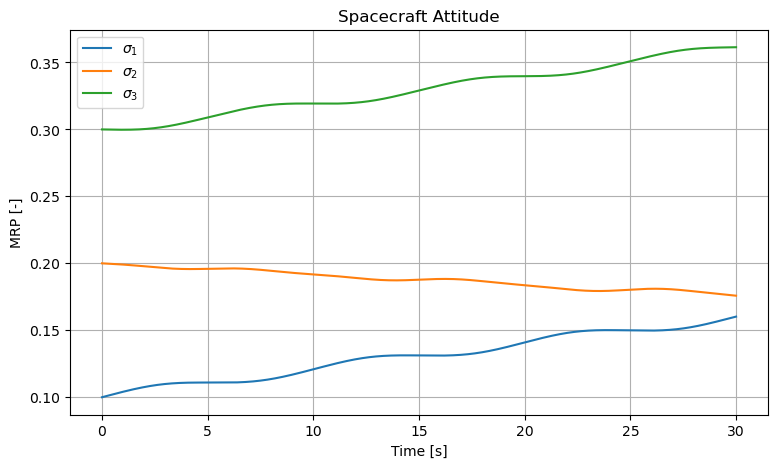

In [14]:
"""
Plot the spacecraft Modified Rodrigues Parameters over the simulation.

The three MRP components describe the evolving spacecraft attitude
sigma_BN relative to the inertial frame.
"""

time = solution.t

sigma_history = solution.y[0:3, :]

plt.figure(figsize=(9, 5))

plt.plot(time, sigma_history[0], label=r"$\sigma_1$")
plt.plot(time, sigma_history[1], label=r"$\sigma_2$")
plt.plot(time, sigma_history[2], label=r"$\sigma_3$")

plt.xlabel("Time [s]")
plt.ylabel("MRP [-]")
plt.title("Spacecraft Attitude")
plt.grid(True)
plt.legend()

plt.show()

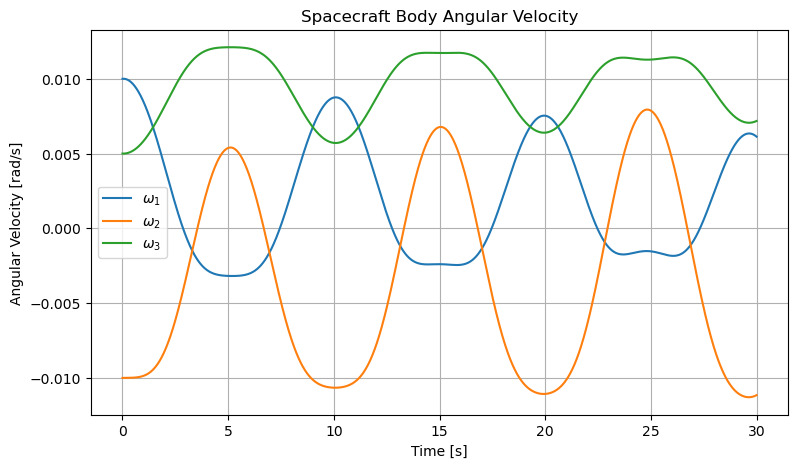

In [15]:
"""
Plot the spacecraft angular-velocity components expressed in B.

These rates evolve even though no external torque is applied because
angular momentum is exchanged internally with the VSCMG.
"""

omega_history = solution.y[3:6, :]

plt.figure(figsize=(9, 5))

plt.plot(time, omega_history[0], label=r"$\omega_1$")
plt.plot(time, omega_history[1], label=r"$\omega_2$")
plt.plot(time, omega_history[2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
plt.title("Spacecraft Body Angular Velocity")
plt.grid(True)
plt.legend()

plt.show()

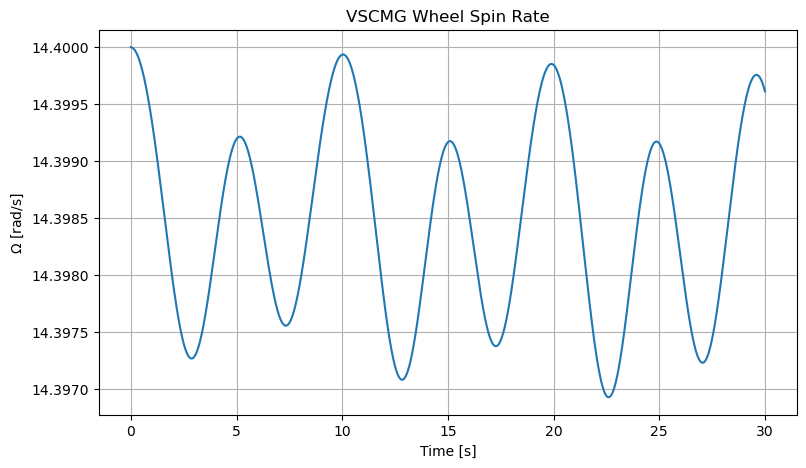

In [16]:
"""
Plot the VSCMG wheel spin rate.

Even with zero wheel motor torque, the wheel speed is not mathematically
forced to remain constant because the wheel remains dynamically coupled
to the moving spacecraft and gimbal.
"""

Omega_history = solution.y[8, :]

plt.figure(figsize=(9, 5))

plt.plot(time, Omega_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\Omega$ [rad/s]")
plt.title("VSCMG Wheel Spin Rate")
plt.grid(True)

plt.show()

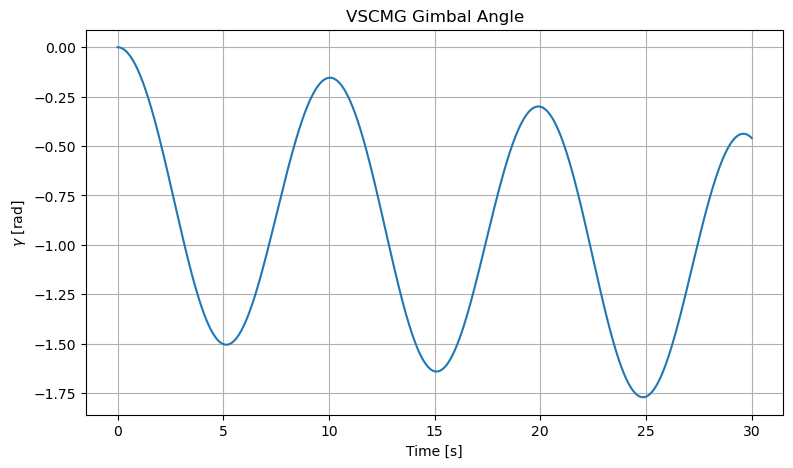

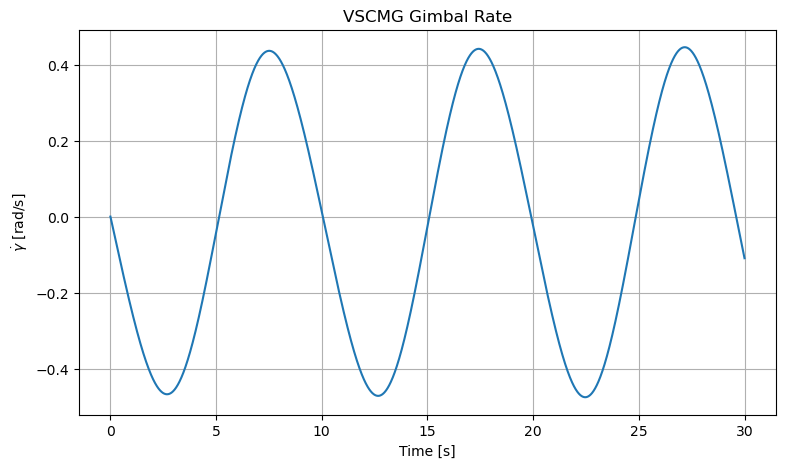

In [17]:
"""
Plot the VSCMG gimbal motion.

The zero gimbal motor torque does not lock the gimbal. The gimbal is a
free dynamic degree of freedom and responds to the gyroscopic coupling
within the spacecraft/VSCMG system.
"""

gamma_history = solution.y[6, :]
gamma_dot_history = solution.y[7, :]

plt.figure(figsize=(9, 5))

plt.plot(time, gamma_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\gamma$ [rad]")
plt.title("VSCMG Gimbal Angle")
plt.grid(True)

plt.show()


plt.figure(figsize=(9, 5))

plt.plot(time, gamma_dot_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{\gamma}$ [rad/s]")
plt.title("VSCMG Gimbal Rate")
plt.grid(True)

plt.show()

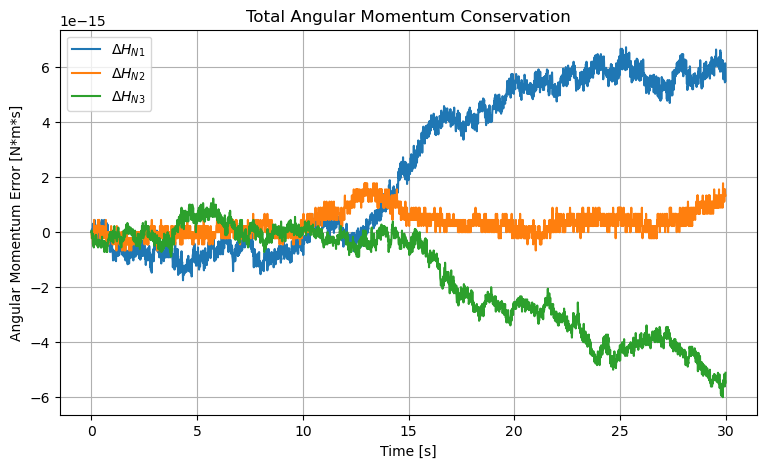

In [18]:
"""
Plot the inertial angular-momentum conservation error.

With zero external torque,

    dH_N/dt = 0.

Therefore each inertial component of the total angular momentum should
remain constant. Any observed drift here is numerical error.
"""

plt.figure(figsize=(9, 5))

plt.plot(time, H_error_history[:, 0], label=r"$\Delta H_{N1}$")
plt.plot(time, H_error_history[:, 1], label=r"$\Delta H_{N2}$")
plt.plot(time, H_error_history[:, 2], label=r"$\Delta H_{N3}$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Momentum Error [N*m*s]")
plt.title("Total Angular Momentum Conservation")
plt.grid(True)
plt.legend()

plt.show()

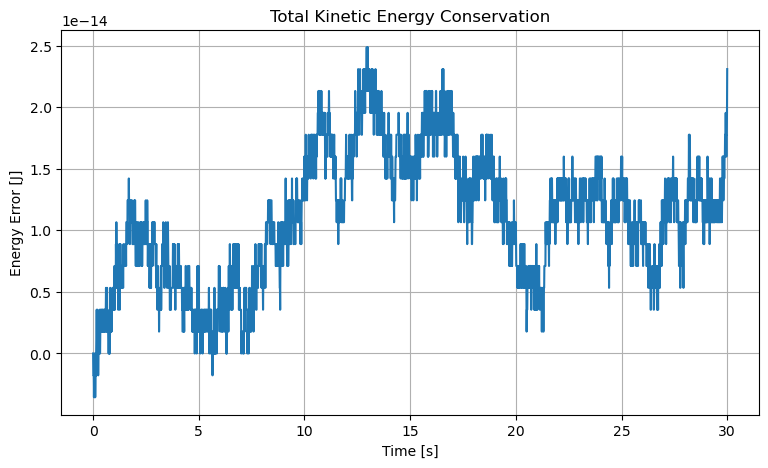

In [19]:
"""
Plot the kinetic-energy conservation error.

The work-energy relation gives

    T_dot = omega^T L + gamma_dot*u_g + Omega*u_s.

For this simulation,

    L = 0
    u_g = 0
    u_s = 0

so T_dot = 0 and the total kinetic energy should remain constant.
"""

plt.figure(figsize=(9, 5))

plt.plot(time, T_error_history)

plt.xlabel("Time [s]")
plt.ylabel("Energy Error [J]")
plt.title("Total Kinetic Energy Conservation")
plt.grid(True)

plt.show()

In [20]:
"""
Extract the required verification quantities at t_f = 30 seconds.

Required quiz outputs:

    H_N        : total angular momentum expressed in N [N*m*s]
    T          : total kinetic energy [J]
    sigma_BN   : spacecraft attitude MRPs [-]
    omega_BN_B : spacecraft angular velocity expressed in B [rad/s]
    Omega      : wheel spin rate [rad/s]
    gamma      : gimbal angle [rad]

The MRP shadow transformation is applied to the final attitude so that
the reported attitude uses the short-rotation / principal MRP set.
"""

# Final propagated state
x_f = solution.y[:, -1]

# Spacecraft attitude, principal MRP set [-]
sigma_BN = ak.MRP_shadow(x_f[0:3])

# Spacecraft angular velocity expressed in B [rad/s]
omega_BN_B = x_f[3:6]

# Gimbal angle [rad]
gamma = x_f[6]

# Gimbal rate [rad/s]
gamma_dot = x_f[7]

# Wheel spin rate [rad/s]
Omega = x_f[8]

# Total angular momentum expressed in N [N*m*s]
H_N = total_angular_momentum_N(
    sigma_BN=sigma_BN,
    omega_BN_B=omega_BN_B,
    Omega=Omega,
    gamma=gamma,
    gamma_dot=gamma_dot
)

# Total kinetic energy [J]
T = total_kinetic_energy(
    omega_BN_B=omega_BN_B,
    Omega=Omega,
    gamma=gamma,
    gamma_dot=gamma_dot
)

print(f"Results at t_f = {solution.t[-1]:.1f} s")
print("-" * 60)

print("H_N [N*m*s] =")
print(H_N)

print("\nT [J] =")
print(T)

print("\nsigma_BN [-] =")
print(sigma_BN)

print("\nomega_BN_B [rad/s] =")
print(omega_BN_B)

print("\nOmega [rad/s] =")
print(Omega)

print("\ngamma [rad] =")
print(gamma)

Results at t_f = 30.0 s
------------------------------------------------------------
H_N [N*m*s] =
[0.18038596 1.07456123 0.46786442]

T [J] =
10.36357101442844

sigma_BN [-] =
[0.16020254 0.17581713 0.36139187]

omega_BN_B [rad/s] =
[ 0.00613048 -0.01115198  0.00717923]

Omega [rad/s] =
14.399612994027407

gamma [rad] =
-0.45941617258745177


# 2 - Multi-VSCMG Modeling

## 2.1 - Extending the Model to Multiple VSCMGs

The single-VSCMG model developed in Section 1 gave us more than just the solution to one numerical problem. In constructing it, we already separated several ideas that naturally appear in a larger spacecraft simulation: fixed hardware properties, mounting geometry, dynamic states, equations of motion, numerical integration, and post-processing.

This section takes that single-device implementation and asks how those pieces can be reorganized into a small reusable simulation architecture that can support an arbitrary number of momentum exchange devices.

This is **not intended to become a full spacecraft 6DOF simulator**. A true six-degree-of-freedom model would at minimum couple the spacecraft's translational and rotational motion, while a more complete spacecraft simulation would normally also introduce environmental models, sensors, actuator models, state estimation, flight-software logic, timing, and other subsystems. Those topics are well beyond the scope of this notebook.

Instead, the goal here is much narrower: build a lightweight attitude-dynamics framework around the momentum-exchange-device problem we have already derived.

It can therefore be thought of loosely as a **6DOF-lite architecture**: not because it models all six spacecraft degrees of freedom, but because it begins to adopt some of the same software-design ideas that a larger simulator would require.

The development will focus on

$$
\boxed{
\text{device definition}
\rightarrow
\text{spacecraft model}
\rightarrow
\text{state}
\rightarrow
\text{dynamics}
\rightarrow
\text{integration}
\rightarrow
\text{verification}
}
$$

The objective is to keep every software abstraction close enough to the equations that the physical meaning remains visible. These tools can then serve as groundwork for a more complete 6DOF implementation should that thread be pursued later.

### 2.1.1 - The RK4 Integrator

Before introducing any new spacecraft or momentum-device objects, we can reuse a numerical tool developed previously.

In the first specialization, the classical fourth-order Runge-Kutta method was implemented as a generic single-step integrator. The important design choice was that the integrator itself contained no spacecraft dynamics. It only required a function capable of evaluating a first-order system of the form

$$
\boxed{
\dot{\mathbf{x}} = f(t,\mathbf{x}).
}
$$

The meaning and size of $\mathbf{x}$ are therefore irrelevant to RK4. In the previous attitude-control problem, the state contained the spacecraft MRPs and body rates. In the present problem, the same integrator can later propagate a larger state containing the spacecraft attitude, body rates, and the internal states of multiple momentum exchange devices.

The classical RK4 update evaluates the state derivative four times,

$$
\mathbf{k}_1 = f(t_k,\mathbf{x}_k),
$$

$$
\mathbf{k}_2 = f\left(t_k+\frac{\Delta t}{2},\mathbf{x}_k+\frac{\Delta t}{2}\mathbf{k}_1\right),
$$

$$
\mathbf{k}_3 = f\left(t_k+\frac{\Delta t}{2},\mathbf{x}_k+\frac{\Delta t}{2}\mathbf{k}_2\right),
$$

$$
\mathbf{k}_4 = f\left(t_k+\Delta t,\mathbf{x}_k+\Delta t\,\mathbf{k}_3\right),
$$

and combines them as

$$
\boxed{
\mathbf{x}_{k+1} =
\mathbf{x}_k
+
\frac{\Delta t}{6}
\left(
\mathbf{k}_1
+
2\mathbf{k}_2
+
2\mathbf{k}_3
+
\mathbf{k}_4
\right).
}
$$

This separation between the **numerical integrator** and the **state-derivative model** is useful because the dynamics can become considerably more complicated without requiring any change to the RK4 algorithm itself.

For this notebook, a fixed-step RK4 integrator is retained because it is transparent, deterministic, and sufficiently accurate for studying the coupled attitude and momentum-device dynamics. This should not be interpreted as RK4 being the preferred integrator for every spacecraft simulation. Step-size control, computational cost, stiffness, conservation properties, and long-duration numerical behaviour can all influence the choice of integration method.

> **TODO - Numerical Integration Study:**  
> A separate study should compare fixed- and variable-step integration methods, including Euler, RK2, RK4, adaptive Runge-Kutta methods, higher-order schemes such as DOP853, and structure-preserving methods for rotational dynamics. Particular attention should be given to accuracy, computational cost, timestep sensitivity, and conservation of mechanical invariants. This study is tracked separately under `studies/Numerical Integration Methods/`.

In [21]:
def rk4_step(f, t, x, dt, *args, **kwargs):
    """
    Advance one timestep using classical 4th-order Runge–Kutta (RK4).
    
    Parameters
    ----------
    f : callable
        RHS function with signature f(t, x, *args, **kwargs) -> xdot.
    t : float
        Current time.
    x : np.ndarray
        Current state vector.
    dt : float
        Timestep size.
    *args, **kwargs
        Extra arguments passed through to `f`.
    
    Returns
    -------
    x_next : np.ndarray
        State advanced by one RK4 step of size `dt`.
    """
    k1 = f(t, x, *args, **kwargs)
    k2 = f(t + 0.5*dt, x + 0.5*dt*k1, *args, **kwargs)
    k3 = f(t + 0.5*dt, x + 0.5*dt*k2, *args, **kwargs)
    k4 = f(t + dt, x + dt*k3, *args, **kwargs)
    
    x_next = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    
    return x_next

### 2.1.2 - The `MomentumExchangeDevice` object

The first physical building block of the attitude model is a single momentum exchange device.

Reaction wheels, CMGs, and VSCMGs share the same basic hardware description: inertial properties, a spin axis, a mounting orientation relative to the spacecraft, and actuator limits. The `MomentumExchangeDevice` class is therefore intended to define **what the hardware is**, not how its dynamics evolve.

For the course equations, the combined device inertia is represented by

$$ {}^G[J] = \operatorname{diag}(J_s,J_t,J_g), $$

with

$$ J = (J_s,J_t,J_g), $$

while the wheel spin-axis inertia $I_{W_s}$ is retained separately because it appears explicitly in the wheel momentum and motor dynamics.

The reference mounting orientation is

$$ \boxed{C_{BG_0} = \begin{bmatrix}\hat{\mathbf g}_{s_0,B} & \hat{\mathbf g}_{t_0,B} & \hat{\mathbf g}_{g,B}\end{bmatrix}}, $$

which defines the device frame at $\gamma=0$.

The main distinction between the three device types is:

| Device | Wheel speed $\Omega$ | Gimbal angle $\gamma$ | Main specialization |
|---|---|---|---|
| RW | Time-varying | Fixed | $\dot{\gamma}=\ddot{\gamma}=0$ |
| CMG | Fixed by inner servo | Time-varying | $\dot{\Omega}=0$ |
| VSCMG | Time-varying | Time-varying | Both internal DOFs active |

The device class should therefore contain fixed hardware properties such as `J`, `I_Ws`, `C_BG_ref`, device mode, and actuator limits. Dynamic quantities such as $\gamma$, $\dot{\gamma}$, $\Omega$, motor torques, and their derivatives belong to the propagated state or inputs.

The actual equations of motion should be handled by a separate dynamics model. That model can inspect the device mode and apply the appropriate specialization, such as locking the gimbal for an RW or enforcing constant wheel speed for a CMG.

For now, the implementation stores the minimum inertia quantities required by the course problems. A future extension could allow construction from separate gimbal and wheel inertia tensors, $I_G$ and $I_W$, and derive

$$ J = I_G + I_W $$

internally. This would make the class more suitable for higher-fidelity actuator modelling or actual RW/CMG/VSCMG hardware design without complicating the current course implementation.

In [22]:
from dataclasses import dataclass
from typing import Literal


@dataclass
class MomentumExchangeDevice:
    """
    Define the fixed physical properties, mounting, and hardware limits
    of a momentum exchange device.

    Parameters
    ----------
    mode : {"RW", "CMG", "VSCMG"}
        Momentum exchange device type.
    J : tuple[float, float, float] or None
        Combined MED principal inertias (J_s, J_t, J_g) expressed in
        the device frame [kg*m^2], where J = I_G + I_W.

        May be None for a reduced reaction-wheel model when the fixed
        non-spin device inertia is already incorporated into the
        supplied spacecraft inertia.
    I_Ws : float
        Wheel spin-axis moment of inertia [kg*m^2].
    C_BG_ref : np.ndarray
        Reference device-frame orientation relative to the spacecraft
        body frame at gamma = 0. Its columns are
        (g_s_ref_B, g_t_ref_B, g_g_B).
    Omega_bounds : tuple[float, float], optional
        Lower and upper wheel spin-rate limits [rad/s].
    u_s_bounds : tuple[float, float], optional
        Lower and upper wheel motor torque limits [N*m].
    gamma_bounds : tuple[float, float], optional
        Lower and upper gimbal-angle limits [rad].
    gamma_dot_bounds : tuple[float, float], optional
        Lower and upper gimbal-rate limits [rad/s].
    u_g_bounds : tuple[float, float], optional
        Lower and upper gimbal motor torque limits [N*m].

    Notes
    -----
    The present dynamics model stores the minimum inertia quantities
    required by the course equations: the combined device inertia J
    and the wheel spin-axis inertia I_Ws.

    A higher-fidelity hardware model could instead accept separate
    gimbal and wheel inertia tensors I_G and I_W, then derive
    J = I_G + I_W and I_Ws from those component properties.
    """

    mode: Literal["RW", "CMG", "VSCMG"]
    J: tuple[float, float, float] | None
    I_Ws: float
    C_BG_ref: np.ndarray

    Omega_bounds: tuple[float, float] | None = None
    u_s_bounds: tuple[float, float] | None = None
    gamma_bounds: tuple[float, float] | None = None
    gamma_dot_bounds: tuple[float, float] | None = None
    u_g_bounds: tuple[float, float] | None = None

    def __post_init__(self):
        if self.mode not in ("RW", "CMG", "VSCMG"):
            raise ValueError("mode must be 'RW', 'CMG', or 'VSCMG'.")

        self.I_Ws = float(self.I_Ws)
        self.C_BG_ref = np.asarray(self.C_BG_ref, dtype=float)

        if self.I_Ws <= 0.0:
            raise ValueError("I_Ws must be positive.")

        if self.C_BG_ref.shape != (3, 3):
            raise ValueError("C_BG_ref must be a 3x3 DCM.")

        if not np.allclose(self.C_BG_ref.T @ self.C_BG_ref, np.eye(3)):
            raise ValueError("C_BG_ref must be orthogonal.")

        if not np.isclose(np.linalg.det(self.C_BG_ref), 1.0):
            raise ValueError("C_BG_ref must be a proper rotation matrix.")

        if self.J is not None:
            if len(self.J) != 3:
                raise ValueError("J must contain (J_s, J_t, J_g).")

            J_s, J_t, J_g = self.J

            self.J = (
                float(J_s),
                float(J_t),
                float(J_g)
            )

            if any(J_i <= 0.0 for J_i in self.J):
                raise ValueError("All principal inertias in J must be positive.")

        if self.mode in ("CMG", "VSCMG") and self.J is None:
            raise ValueError(f"{self.mode} requires J.")

        self.Omega_bounds = self._validate_bounds(self.Omega_bounds, "Omega_bounds")
        self.u_s_bounds = self._validate_bounds(self.u_s_bounds, "u_s_bounds")
        self.gamma_bounds = self._validate_bounds(self.gamma_bounds, "gamma_bounds")
        self.gamma_dot_bounds = self._validate_bounds(self.gamma_dot_bounds, "gamma_dot_bounds")
        self.u_g_bounds = self._validate_bounds(self.u_g_bounds, "u_g_bounds")

    @classmethod
    def rw(cls, I_Ws, C_BG_ref, J=None, Omega_bounds=None, u_s_bounds=None,
           gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a reaction wheel.
        """
        device = cls(
            mode="RW",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @classmethod
    def cmg(cls, J, I_Ws, C_BG_ref, Omega_bounds=None, u_s_bounds=None,
            gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a control moment gyroscope.
        """
        device = cls(
            mode="CMG",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @classmethod
    def vscmg(cls, J, I_Ws, C_BG_ref, Omega_bounds=None, u_s_bounds=None,
              gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a variable-speed control moment gyroscope.
        """
        device = cls(
            mode="VSCMG",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @staticmethod
    def _validate_bounds(
        bounds: tuple[float, float] | None,
        name: str
    ) -> tuple[float, float] | None:
        """
        Validate an optional (lower, upper) hardware bound pair.
        """
        if bounds is None:
            validated_bounds = None
            return validated_bounds

        if len(bounds) != 2:
            raise ValueError(f"{name} must contain (lower, upper).")

        lower = float(bounds[0])
        upper = float(bounds[1])

        if lower >= upper:
            raise ValueError(f"{name} must satisfy lower < upper.")

        validated_bounds = (lower, upper)

        return validated_bounds

    @property
    def is_rw(self):
        is_rw = self.mode == "RW"
        return is_rw

    @property
    def is_cmg(self):
        is_cmg = self.mode == "CMG"
        return is_cmg

    @property
    def is_vscmg(self):
        is_vscmg = self.mode == "VSCMG"
        return is_vscmg

    @property
    def has_combined_inertia(self):
        has_combined_inertia = self.J is not None
        return has_combined_inertia

    @property
    def J_s(self):
        J = self._require_combined_inertia()
        J_s = J[0]
        return J_s

    @property
    def J_t(self):
        J = self._require_combined_inertia()
        J_t = J[1]
        return J_t

    @property
    def J_g(self):
        J = self._require_combined_inertia()
        J_g = J[2]
        return J_g

    @property
    def g_s_ref_B(self):
        g_s_ref_B = self.C_BG_ref[:, 0]
        return g_s_ref_B

    @property
    def g_t_ref_B(self):
        g_t_ref_B = self.C_BG_ref[:, 1]
        return g_t_ref_B

    @property
    def g_g_B(self):
        g_g_B = self.C_BG_ref[:, 2]
        return g_g_B

    def _require_combined_inertia(self) -> tuple[float, float, float]:
        """
        Return the combined MED principal inertia tuple when available.
        """
        if self.J is None:
            raise ValueError("Combined device inertia J was not supplied.")
        J = self.J
        return J

    def axes_B(self, gamma):
        """
        Return the instantaneous device axes expressed in B.

        Parameters
        ----------
        gamma : float
            Current gimbal angle measured from the reference
            orientation [rad].

        Returns
        -------
        g_s_B : np.ndarray
            Current spin axis expressed in B.
        g_t_B : np.ndarray
            Current transverse axis expressed in B.
        g_g_B : np.ndarray
            Gimbal axis expressed in B.
        """
        g_s_B =  np.cos(gamma)*self.g_s_ref_B + np.sin(gamma)*self.g_t_ref_B
        g_t_B = -np.sin(gamma)*self.g_s_ref_B + np.cos(gamma)*self.g_t_ref_B
        g_g_B = self.g_g_B
        return g_s_B, g_t_B, g_g_B

    def C_BG(self, gamma):
        """
        Return the instantaneous device-frame DCM relative to B.
        """
        g_s_B, g_t_B, g_g_B = self.axes_B(gamma)
        C_BG = np.column_stack((g_s_B, g_t_B, g_g_B))
        return C_BG

    def inertia_B(self, gamma):
        """
        Return the combined MED inertia expressed in B.

        Requires the combined principal inertia tuple J.
        """
        J = self._require_combined_inertia()
        C_BG = self.C_BG(gamma)
        J_matrix = np.diag(J)
        J_B = C_BG @ J_matrix @ C_BG.T
        return J_B

In [23]:
"""
Exercise the MomentumExchangeDevice class using representative RW, CMG,
and VSCMG configurations.

The VSCMG properties are taken from the single-device problem developed
previously. Hardware limits below are arbitrary test values used only to
verify the dataclass interface.
"""

theta = np.deg2rad(54.75)

# Combined MED principal inertias and wheel spin inertia [kg*m^2]
J = (0.13, 0.04, 0.03)
I_Ws = 0.10

# Reference device axes expressed in B at gamma = 0
g_s_ref_B = np.array([0.0, 1.0, 0.0])
g_g_ref_B = np.array([np.cos(theta), 0.0, np.sin(theta)])
g_t_ref_B = np.cross(g_g_ref_B, g_s_ref_B)

# Reference device-frame orientation at gamma = 0
C_BG_ref = np.column_stack((
    g_s_ref_B,
    g_t_ref_B,
    g_g_ref_B
))

# Arbitrary hardware limits used only to exercise the class interface
Omega_bounds = (-100.0, 120.0)
u_s_bounds = (-0.08, 0.10)
gamma_bounds = (-np.pi, np.pi)
gamma_dot_bounds = (-0.5, 0.6)
u_g_bounds = (-0.12, 0.15)


# Instantiate each momentum exchange device type
vscmg = MomentumExchangeDevice.vscmg(
    J=J,
    I_Ws=I_Ws,
    C_BG_ref=C_BG_ref,
    Omega_bounds=Omega_bounds,
    u_s_bounds=u_s_bounds,
    gamma_bounds=gamma_bounds,
    gamma_dot_bounds=gamma_dot_bounds,
    u_g_bounds=u_g_bounds
)

cmg = MomentumExchangeDevice.cmg(
    J=J,
    I_Ws=I_Ws,
    C_BG_ref=C_BG_ref
)

rw = MomentumExchangeDevice.rw(
    I_Ws=I_Ws,
    C_BG_ref=C_BG_ref
)


# Evaluate the VSCMG geometry at a sample gimbal angle
gamma = np.deg2rad(30.0)

g_s_B, g_t_B, g_g_B = vscmg.axes_B(gamma)
C_BG = vscmg.C_BG(gamma)
J_B = vscmg.inertia_B(gamma)


# Device-type checks
print("Device-type checks:")
print(f"VSCMG -> mode={vscmg.mode}, is_vscmg={vscmg.is_vscmg}, "
      f"is_cmg={vscmg.is_cmg}, is_rw={vscmg.is_rw}")
print(f"CMG   -> mode={cmg.mode}, is_vscmg={cmg.is_vscmg}, "
      f"is_cmg={cmg.is_cmg}, is_rw={cmg.is_rw}")
print(f"RW    -> mode={rw.mode}, is_vscmg={rw.is_vscmg}, "
      f"is_cmg={rw.is_cmg}, is_rw={rw.is_rw}")


# Inertia-property checks
print("\nInertia-property checks:")
print(f"VSCMG has combined inertia: {vscmg.has_combined_inertia}")
print(f"RW has combined inertia:    {rw.has_combined_inertia}")

print(f"\nJ [kg*m^2]: {vscmg.J}")
print(f"J_s [kg*m^2]: {vscmg.J_s}")
print(f"J_t [kg*m^2]: {vscmg.J_t}")
print(f"J_g [kg*m^2]: {vscmg.J_g}")
print(f"I_Ws [kg*m^2]: {vscmg.I_Ws}")


# Reference mounting checks
print("\nReference mounting:")
print(f"g_s_ref_B = {vscmg.g_s_ref_B}")
print(f"g_t_ref_B = {vscmg.g_t_ref_B}")
print(f"g_g_B     = {vscmg.g_g_B}")

print(f"\nC_BG_ref:\n{vscmg.C_BG_ref}")


# Instantaneous geometry checks
print(f"\nGeometry at gamma = {np.rad2deg(gamma):.1f} deg:")
print(f"g_s_B = {g_s_B}")
print(f"g_t_B = {g_t_B}")
print(f"g_g_B = {g_g_B}")

print(f"\nC_BG:\n{C_BG}")
print(f"\nJ_B [kg*m^2]:\n{J_B}")


# Hardware-limit checks
print("\nHardware bounds:")
print(f"Omega_bounds     = {vscmg.Omega_bounds}")
print(f"u_s_bounds       = {vscmg.u_s_bounds}")
print(f"gamma_bounds     = {vscmg.gamma_bounds}")
print(f"gamma_dot_bounds = {vscmg.gamma_dot_bounds}")
print(f"u_g_bounds       = {vscmg.u_g_bounds}")


# Basic consistency checks
assert vscmg.is_vscmg
assert cmg.is_cmg
assert rw.is_rw

assert vscmg.has_combined_inertia
assert cmg.has_combined_inertia
assert not rw.has_combined_inertia

assert np.allclose(C_BG.T @ C_BG, np.eye(3))
assert np.isclose(np.linalg.det(C_BG), 1.0)

assert np.allclose(g_s_B @ g_t_B, 0.0)
assert np.allclose(g_s_B @ g_g_B, 0.0)
assert np.allclose(g_t_B @ g_g_B, 0.0)

assert np.isclose(np.linalg.norm(g_s_B), 1.0)
assert np.isclose(np.linalg.norm(g_t_B), 1.0)
assert np.isclose(np.linalg.norm(g_g_B), 1.0)


# A reduced RW does not contain a separately modelled combined inertia J
try:
    rw.inertia_B(gamma=0.0)

except ValueError as error:
    print("\nReduced-RW inertia check:")
    print(error)


print("\nMomentumExchangeDevice checks completed.")

Device-type checks:
VSCMG -> mode=VSCMG, is_vscmg=True, is_cmg=False, is_rw=False
CMG   -> mode=CMG, is_vscmg=False, is_cmg=True, is_rw=False
RW    -> mode=RW, is_vscmg=False, is_cmg=False, is_rw=True

Inertia-property checks:
VSCMG has combined inertia: True
RW has combined inertia:    False

J [kg*m^2]: (0.13, 0.04, 0.03)
J_s [kg*m^2]: 0.13
J_t [kg*m^2]: 0.04
J_g [kg*m^2]: 0.03
I_Ws [kg*m^2]: 0.1

Reference mounting:
g_s_ref_B = [0. 1. 0.]
g_t_ref_B = [-0.81664156  0.          0.57714519]
g_g_B     = [0.57714519 0.         0.81664156]

C_BG_ref:
[[ 0.         -0.81664156  0.57714519]
 [ 1.          0.          0.        ]
 [ 0.          0.57714519  0.81664156]]

Geometry at gamma = 30.0 deg:
g_s_B = [-0.40832078  0.8660254   0.2885726 ]
g_t_B = [-0.70723233 -0.5         0.4998224 ]
g_g_B = [0.57714519 0.         0.81664156]

C_BG:
[[-0.40832078 -0.70723233  0.57714519]
 [ 0.8660254  -0.5         0.        ]
 [ 0.2885726   0.4998224   0.81664156]]

J_B [kg*m^2]:
[[ 0.05167436 -0.03182

### 2.1.3 - State Representation

Before defining the spacecraft dynamics, the quantities being propagated must first be specified. For this notebook, the state contains the spacecraft attitude and body rate together with the internal states of each momentum exchange device.

For $N$ momentum exchange devices, define

$$
\boldsymbol{\gamma} =
\begin{bmatrix}
\gamma_1 & \gamma_2 & \cdots & \gamma_N
\end{bmatrix}^T,
$$

$$
\dot{\boldsymbol{\gamma}} =
\begin{bmatrix}
\dot{\gamma}_1 & \dot{\gamma}_2 & \cdots & \dot{\gamma}_N
\end{bmatrix}^T,
$$

$$
\boldsymbol{\Omega} =
\begin{bmatrix}
\Omega_1 & \Omega_2 & \cdots & \Omega_N
\end{bmatrix}^T.
$$

The complete state vector is then

$$
\boxed{
\mathbf{x} =
\begin{bmatrix}
\boldsymbol{\sigma}_{B/N} \\
{}^B\boldsymbol{\omega}_{B/N} \\
\boldsymbol{\gamma} \\
\dot{\boldsymbol{\gamma}} \\
\boldsymbol{\Omega}
\end{bmatrix}
\in \mathbb{R}^{6+3N}.
}
$$

The dimension follows directly from the states being propagated,

$$
\underbrace{3}_{\boldsymbol{\sigma}_{B/N}}
+
\underbrace{3}_{{}^B\boldsymbol{\omega}_{B/N}}
+
\underbrace{N}_{\gamma_i}
+
\underbrace{N}_{\dot{\gamma}_i}
+
\underbrace{N}_{\Omega_i} =
\boxed{6+3N}.
$$

The corresponding state derivative is

$$
\boxed{
\dot{\mathbf{x}} =
\begin{bmatrix}
\dot{\boldsymbol{\sigma}}_{B/N} \\
{}^B\dot{\boldsymbol{\omega}}_{B/N} \\
\dot{\boldsymbol{\gamma}} \\
\ddot{\boldsymbol{\gamma}} \\
\dot{\boldsymbol{\Omega}}
\end{bmatrix}.
}
$$

This state definition is kept separate from both the physical model and the numerical integrator. The `SpacecraftAttitudeModel` determines how the state evolves,

$$
\boxed{
\dot{\mathbf{x}} =
f(t,\mathbf{x},\mathbf{u}),
}
$$

while RK4 only advances the resulting state vector through time.

The small `pack_state()` and `unpack_state()` utilities below keep this state layout explicit without repeating numerical array indices throughout the dynamics model.

In [24]:
def pack_state(sigma_BN, omega_BN_B, gamma, gamma_dot, Omega):
    """
    Pack the spacecraft and momentum-device states into a single state vector.

    Parameters
    ----------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].

    Returns
    -------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    """
    sigma_BN   = np.asarray(sigma_BN, dtype=float)
    omega_BN_B = np.asarray(omega_BN_B, dtype=float)
    gamma      = np.atleast_1d(np.asarray(gamma, dtype=float))
    gamma_dot  = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
    Omega      = np.atleast_1d(np.asarray(Omega, dtype=float))

    if sigma_BN.shape != (3,):
        raise ValueError("sigma_BN must contain three elements.")

    if omega_BN_B.shape != (3,):
        raise ValueError("omega_BN_B must contain three elements.")

    if not (gamma.size == gamma_dot.size == Omega.size):
        raise ValueError("gamma, gamma_dot, and Omega must have equal length.")

    x = np.hstack((sigma_BN, omega_BN_B, gamma, gamma_dot, Omega))
    return x

In [25]:
def unpack_state(x, N):
    """
    Unpack the spacecraft and momentum-device state vector.

    Parameters
    ----------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    N : int
        Number of momentum exchange devices represented in the state.

    Returns
    -------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise ValueError("x must be a one-dimensional state vector.")

    if x.size != 6 + 3*N:
        raise ValueError(f"x must contain {6 + 3*N} elements for N = {N}.")

    sigma_BN   = x[0:3]
    omega_BN_B = x[3:6]
    gamma      = x[6:6 + N]
    gamma_dot  = x[6 + N:6 + 2*N]
    Omega      = x[6 + 2*N:6 + 3*N]

    return sigma_BN, omega_BN_B, gamma, gamma_dot, Omega

### 2.1.4 - The `SpacecraftAttitudeDynamicsModel` object

A single `MomentumExchangeDevice` describes one actuator. The `SpacecraftAttitudeDynamicsModel` combines the spacecraft hub and a collection of these devices into one coupled rotational plant.

The fixed configuration is therefore

$$
\boxed{
\text{SpacecraftAttitudeDynamicsModel} =
[I_s]
+
\left\{
\text{MomentumExchangeDevice}_i
\right\}_{i=1}^{N}.
}
$$

The device objects define **what hardware is mounted**, while the dynamics model determines **how that hardware interacts with the spacecraft**.

For an explicitly modelled CMG or VSCMG, device $i$ contributes the body-frame inertia

$$
[J_i](\gamma_i) =
[C_{BG_i}(\gamma_i)]
\,{}^G[J_i]\,
[C_{BG_i}(\gamma_i)]^T,
$$

so the instantaneous spacecraft-device inertia is

$$
\boxed{
[I](\boldsymbol{\gamma}) =
[I_s]
+
\sum_{i=1}^{N}
[J_i](\gamma_i).
}
$$

Since $\hat{\mathbf g}_{s_i}$ and $\hat{\mathbf g}_{t_i}$ rotate with the gimbal, the body-frame representation of $[J_i]$ changes with $\gamma_i$.

The dynamics model will also support reduced formulations where some fixed MED inertia has already been incorporated into a supplied spacecraft inertia, such as $[I_{RW}]$. The important requirement is that each inertia contribution is included exactly once.

**<ins>Evaluating the Dynamics at One Instant</ins>**

The dynamics model does not internally propagate the state. Instead, at some instant $t$, it is given the current state

$$
\mathbf{x} =
\begin{bmatrix}
\boldsymbol{\sigma} \\
\boldsymbol{\omega} \\
\boldsymbol{\gamma} \\
\dot{\boldsymbol{\gamma}} \\
\boldsymbol{\Omega}
\end{bmatrix},
$$

together with the current inputs,

$$
\mathbf{L},
\qquad
\mathbf{u}_s,
\qquad
\mathbf{u}_g.
$$

These quantities are already known at the current instant. From them, the model can evaluate the current MED axes, projected spacecraft rates, inertia, and nonlinear gyroscopic terms.

The quantities still unknown are the accelerations

$$
\boxed{
\dot{\boldsymbol{\omega}},
\qquad
\dot{\boldsymbol{\Omega}},
\qquad
\ddot{\boldsymbol{\gamma}}.
}
$$

We need these accelerations because the numerical integrator requires the complete state derivative,

$$
\dot{\mathbf{x}} =
\begin{bmatrix}
\dot{\boldsymbol{\sigma}} \\
\dot{\boldsymbol{\omega}} \\
\dot{\boldsymbol{\gamma}} \\
\ddot{\boldsymbol{\gamma}} \\
\dot{\boldsymbol{\Omega}}
\end{bmatrix}.
$$

The MRP kinematics provide

$$
\dot{\boldsymbol{\sigma}} =
\frac{1}{4}
[B(\boldsymbol{\sigma})]\boldsymbol{\omega},
$$

while $\dot{\boldsymbol{\gamma}}$ is already part of the current state.

The dynamics solve must therefore determine

$$
\boxed{
\mathbf{a} =
\begin{bmatrix}
\dot{\boldsymbol{\omega}} \\
\dot{\Omega}_1 \\
\vdots \\
\dot{\Omega}_N \\
\ddot{\gamma}_1 \\
\vdots \\
\ddot{\gamma}_N
\end{bmatrix}
\in
\mathbb{R}^{3+2N}.
}
$$

The dimension follows directly from

$$
\underbrace{3}_{\dot{\boldsymbol{\omega}}}
+
\underbrace{N}_{\dot{\boldsymbol{\Omega}}}
+
\underbrace{N}_{\ddot{\boldsymbol{\gamma}}} =
3+2N.
$$

**<ins>Why the Accelerations Must Be Solved Together</ins>**

For $N$ VSCMGs, Slide 35 introduces the device-axis matrices

$$
[G_s] =
\begin{bmatrix}
\hat{\mathbf g}_{s_1} & \cdots & \hat{\mathbf g}_{s_N}
\end{bmatrix},
$$

$$
[G_t] =
\begin{bmatrix}
\hat{\mathbf g}_{t_1} & \cdots & \hat{\mathbf g}_{t_N}
\end{bmatrix},
$$

$$
[G_g] =
\begin{bmatrix}
\hat{\mathbf g}_{g_1} & \cdots & \hat{\mathbf g}_{g_N}
\end{bmatrix}.
$$

Slide 37 then writes the multiple-VSCMG spacecraft EOM as

$$
\boxed{
[I]\dot{\boldsymbol{\omega}} =
-\boldsymbol{\omega}\times[I]\boldsymbol{\omega}
-[G_s]\boldsymbol{\tau}_s
-[G_t]\boldsymbol{\tau}_t
-[G_g]\boldsymbol{\tau}_g
+\mathbf{L}.
}
$$

The torque-like vectors $\boldsymbol{\tau}_s$, $\boldsymbol{\tau}_t$, and $\boldsymbol{\tau}_g$ introduced on Slide 36 collect the contributions of all MEDs along their respective device axes.

The important point for the numerical model is that these terms contain the same accelerations we are trying to determine. In particular, the detailed wheel and gimbal dynamics contain

$$
\dot{\Omega}_i,
\qquad
\hat{\mathbf g}_{s_i}^T\dot{\boldsymbol{\omega}},
\qquad
\ddot{\gamma}_i,
\qquad
\hat{\mathbf g}_{g_i}^T\dot{\boldsymbol{\omega}}.
$$

For device $i$, the wheel motor equation is

$$
u_{s_i} =
I_{W_{s_i}}
\left(
\dot{\Omega}_i
+
\hat{\mathbf g}_{s_i}^T\dot{\boldsymbol{\omega}}
+
\dot{\gamma}_i\omega_{t_i}
\right),
$$

while the gimbal motor equation is

$$
u_{g_i} =
J_{g_i}
\left(
\hat{\mathbf g}_{g_i}^T\dot{\boldsymbol{\omega}}
+
\ddot{\gamma}_i
\right)
-(J_{s_i}-J_{t_i})\omega_{s_i}\omega_{t_i}
-I_{W_{s_i}}\Omega_i\omega_{t_i}.
$$

Thus, $\dot{\boldsymbol{\omega}}$, $\dot{\Omega}_i$, and $\ddot{\gamma}_i$ depend on one another and cannot generally be solved sequentially.

At a fixed state, however, the equations are linear in these unknown accelerations. We can therefore collect their coefficients and solve the complete system simultaneously as

$$
\boxed{
[M]\mathbf{a} =
\mathbf{b}.
}
$$

Here, $[M]$ contains the coefficients multiplying the unknown accelerations, while $\mathbf{r}$ contains the applied torques and all state-dependent terms that are already known.

**<ins>Constructing the Coupled Coefficient Matrix, $[M]$</ins>**

At any instant in the simulation, the current state and inputs are already known. For a spacecraft carrying $N$ VSCMGs, these include

$$
\boldsymbol{\omega},
\qquad
\boldsymbol{\gamma},
\qquad
\dot{\boldsymbol{\gamma}},
\qquad
\boldsymbol{\Omega},
\qquad
\mathbf{L},
\qquad
\mathbf{u}_s,
\qquad
\mathbf{u}_g.
$$

The hardware properties and current device geometry are also known, so quantities such as

$$
[I],
\qquad
\hat{\mathbf g}_{s_i},
\qquad
\hat{\mathbf g}_{t_i},
\qquad
\hat{\mathbf g}_{g_i},
\qquad
\omega_{s_i},
\qquad
\omega_{t_i},
\qquad
\omega_{g_i}
$$

can all be evaluated from the current state.

What remains unknown are the accelerations

$$
\boxed{
\dot{\boldsymbol{\omega}},
\qquad
\dot{\boldsymbol{\Omega}},
\qquad
\ddot{\boldsymbol{\gamma}}.
}
$$

These quantities are required to construct $\dot{\mathbf{x}}$ and therefore propagate the simulation forward.

At a fixed instant, the coupled equations of motion are linear in these unknown accelerations. We can therefore collect them into

$$
\boxed{
\mathbf{a} =
\begin{bmatrix}
\dot{\boldsymbol{\omega}} \\
\dot{\boldsymbol{\Omega}} \\
\ddot{\boldsymbol{\gamma}}
\end{bmatrix},
}
$$

and rearrange the equations into the standard system of linear equations

$$
\boxed{
[M]\mathbf{a}=\mathbf{b}.
}
$$

Here,

$$
\boxed{
[M] = \text{coefficients multiplying the unknown accelerations},
}
$$

while

$$
\boxed{
\mathbf{b} = \text{quantities already known at the current instant}.
}
$$

A useful way to interpret the matrix construction is

$$
\boxed{
\text{rows}=\text{equations},
\qquad
\text{columns}=\text{unknown accelerations}.
}
$$

**Consider a spacecraft with two VSCMGs.**

The unknown acceleration vector becomes

$$
\boxed{
\mathbf{a} =
\begin{bmatrix}
\dot{\omega}_1 &
\dot{\omega}_2 &
\dot{\omega}_3 &
\dot{\Omega}_1 &
\dot{\Omega}_2 &
\ddot{\gamma}_1 &
\ddot{\gamma}_2
\end{bmatrix}^T
\in\mathbb{R}^7.
}
$$

There are therefore seven unknowns, so we require seven independent equations:

- $3$ spacecraft rotational equations,
- $2$ wheel motor equations,
- $2$ gimbal motor equations.

The spacecraft rotational EOM provides the first three equations. Collecting only the acceleration-dependent terms on the left gives

$$
[I]\dot{\boldsymbol{\omega}}
+
I_{W_{s_1}}\hat{\mathbf g}_{s_1}\dot{\Omega}_1
+
I_{W_{s_2}}\hat{\mathbf g}_{s_2}\dot{\Omega}_2
+
J_{g_1}\hat{\mathbf g}_{g_1}\ddot{\gamma}_1
+
J_{g_2}\hat{\mathbf g}_{g_2}\ddot{\gamma}_2 =
\mathbf{b}_B.
$$

Everything contained in $\mathbf{b}_B$ is already known from the current state and applied torque. For the two-VSCMG case,

$$
\begin{aligned}
\mathbf{b}_B ={}&
-\boldsymbol{\omega}\times[I]\boldsymbol{\omega}
+\mathbf{L} \\[1mm]
&-\sum_{i=1}^{2}
\hat{\mathbf g}_{s_i}
\left[
(J_{s_i}-J_{t_i}+J_{g_i})
\dot{\gamma}_i\omega_{t_i}
\right] \\[1mm]
&-\sum_{i=1}^{2}
\hat{\mathbf g}_{t_i}
\left[
\left(
(J_{s_i}-J_{t_i}-J_{g_i})\omega_{s_i}
+
I_{W_{s_i}}\Omega_i
\right)\dot{\gamma}_i
+
I_{W_{s_i}}\Omega_i\omega_{g_i}
\right] \\[1mm]
&+\sum_{i=1}^{2}
\hat{\mathbf g}_{g_i}
I_{W_{s_i}}\Omega_i\omega_{t_i}.
\end{aligned}
$$

The two wheel equations are obtained from the wheel motor relation,

$$
I_{W_{s_1}}\hat{\mathbf g}_{s_1}^T\dot{\boldsymbol{\omega}}
+
I_{W_{s_1}}\dot{\Omega}_1 =
b_{W_1},
$$

$$
I_{W_{s_2}}\hat{\mathbf g}_{s_2}^T\dot{\boldsymbol{\omega}}
+
I_{W_{s_2}}\dot{\Omega}_2 =
b_{W_2},
$$

where

$$
\boxed{
b_{W_i} = u_{s_i} - I_{W_{s_i}}\dot{\gamma}_i\omega_{t_i}.
}
$$

Likewise, the two gimbal equations are

$$
J_{g_1}\hat{\mathbf g}_{g_1}^T\dot{\boldsymbol{\omega}}
+
J_{g_1}\ddot{\gamma}_1 =
b_{G_1},
$$

$$
J_{g_2}\hat{\mathbf g}_{g_2}^T\dot{\boldsymbol{\omega}}
+
J_{g_2}\ddot{\gamma}_2 =
b_{G_2},
$$

where

$$
\boxed{
b_{G_i} =
u_{g_i}
+
(J_{s_i}-J_{t_i})\omega_{s_i}\omega_{t_i}
+
I_{W_{s_i}}\Omega_i\omega_{t_i}.
}
$$

The complete known-term vector is therefore

$$
\boxed{
\mathbf{b} =
\begin{bmatrix}
\mathbf{b}_B \\
b_{W_1} \\
b_{W_2} \\
b_{G_1} \\
b_{G_2}
\end{bmatrix}
\in\mathbb{R}^7.
}
$$

Note that $\mathbf{b}_B\in\mathbb{R}^3$, while each wheel and gimbal equation contributes one scalar entry.

Before expanding $[M]$, write the instantaneous spacecraft inertia tensor in its generic form,

$$
\boxed{
[I] =
\begin{bmatrix}
I_{11} & I_{12} & I_{13} \\
I_{21} & I_{22} & I_{23} \\
I_{31} & I_{32} & I_{33}
\end{bmatrix}.
}
$$

Similarly, write the spin and gimbal axes of device $i$ as

$$
\hat{\mathbf g}_{s_i} =
\begin{bmatrix}
g_{s_i,1} \\
g_{s_i,2} \\
g_{s_i,3}
\end{bmatrix},
\qquad
\hat{\mathbf g}_{g_i} =
\begin{bmatrix}
g_{g_i,1} \\
g_{g_i,2} \\
g_{g_i,3}
\end{bmatrix}.
$$

We can now read the coefficient multiplying every unknown acceleration directly from the seven equations above.

For two VSCMGs, the complete coefficient matrix is

$$
\boxed{
[M] =
\begin{bmatrix}
I_{11} & I_{12} & I_{13}
& I_{W_{s_1}}g_{s_1,1}
& I_{W_{s_2}}g_{s_2,1}
& J_{g_1}g_{g_1,1}
& J_{g_2}g_{g_2,1}
\\
I_{21} & I_{22} & I_{23}
& I_{W_{s_1}}g_{s_1,2}
& I_{W_{s_2}}g_{s_2,2}
& J_{g_1}g_{g_1,2}
& J_{g_2}g_{g_2,2}
\\
I_{31} & I_{32} & I_{33}
& I_{W_{s_1}}g_{s_1,3}
& I_{W_{s_2}}g_{s_2,3}
& J_{g_1}g_{g_1,3}
& J_{g_2}g_{g_2,3}
\\
I_{W_{s_1}}g_{s_1,1}
& I_{W_{s_1}}g_{s_1,2}
& I_{W_{s_1}}g_{s_1,3}
& I_{W_{s_1}}
& 0
& 0
& 0
\\
I_{W_{s_2}}g_{s_2,1}
& I_{W_{s_2}}g_{s_2,2}
& I_{W_{s_2}}g_{s_2,3}
& 0
& I_{W_{s_2}}
& 0
& 0
\\
J_{g_1}g_{g_1,1}
& J_{g_1}g_{g_1,2}
& J_{g_1}g_{g_1,3}
& 0
& 0
& J_{g_1}
& 0
\\
J_{g_2}g_{g_2,1}
& J_{g_2}g_{g_2,2}
& J_{g_2}g_{g_2,3}
& 0
& 0
& 0
& J_{g_2}
\end{bmatrix}.
}
$$

The complete system is therefore

$$
\boxed{
[M]
\begin{bmatrix}
\dot{\omega}_1 \\
\dot{\omega}_2 \\
\dot{\omega}_3 \\
\dot{\Omega}_1 \\
\dot{\Omega}_2 \\
\ddot{\gamma}_1 \\
\ddot{\gamma}_2
\end{bmatrix} =
\begin{bmatrix}
b_{B_1} \\
b_{B_2} \\
b_{B_3} \\
b_{W_1} \\
b_{W_2} \\
b_{G_1} \\
b_{G_2}
\end{bmatrix}.
}
$$

The structure of $[M]$ now follows directly from the physics.

The upper-left $3\times3$ block is the instantaneous spacecraft inertia tensor $[I]$. The next two columns contain the coefficients multiplying the wheel accelerations $\dot{\Omega}_1$ and $\dot{\Omega}_2$, while the final two columns contain the coefficients multiplying the gimbal accelerations $\ddot{\gamma}_1$ and $\ddot{\gamma}_2$.

The wheel and gimbal rows also contain coefficients in the first three columns because their dynamics depend on the spacecraft angular acceleration $\dot{\boldsymbol{\omega}}$.

However, wheel $1$ does not directly depend on $\dot{\Omega}_2$, wheel $2$ does not directly depend on $\dot{\Omega}_1$, and neither wheel equation contains a gimbal acceleration. Likewise, each gimbal equation contains only its own $\ddot{\gamma}_i$. These absent couplings appear naturally as zeros in $[M]$.

This makes $[M]$ relatively sparse and, more importantly, straightforward to construct numerically.

Rather than introducing additional diagonal matrices simply to compress the notation, the implementation can begin with a zero matrix, insert $[I]$ into the upper-left $3\times3$ block, and then process each `MomentumExchangeDevice` individually.

Each device contributes

1. one column to the spacecraft equations associated with $\dot{\Omega}_i$,
2. one column to the spacecraft equations associated with $\ddot{\gamma}_i$,
3. one wheel equation,
4. one gimbal equation.

For $N$ devices,

$$
\mathbf{a}\in\mathbb{R}^{3+2N},
\qquad
\mathbf{b}\in\mathbb{R}^{3+2N},
$$

and therefore

$$
\boxed{
[M]\in\mathbb{R}^{(3+2N)\times(3+2N)}.
}
$$

Adding another MED introduces one additional wheel acceleration and one additional gimbal acceleration. The system therefore gains two columns for the new unknowns and two rows for the corresponding wheel and gimbal equations, while the same construction pattern is preserved.

**<ins>Generalizing the Dynamics Model to $N$ Momentum Exchange Devices</ins>**

The two-VSCMG example above makes the construction of the coupled system explicit, but the same pattern extends directly to any number of mounted momentum exchange devices.

For $N$ devices, the unknown acceleration vector is

$$
\mathbf a =
\begin{bmatrix}
\dot{\boldsymbol{\omega}} \\
\dot{\boldsymbol{\Omega}} \\
\ddot{\boldsymbol{\gamma}}
\end{bmatrix}
\in\mathbb R^{3+2N},
$$

so the corresponding system has

$$
\boxed{
[M]\in\mathbb R^{(3+2N)\times(3+2N)},
\qquad
\mathbf b\in\mathbb R^{3+2N}.
}
$$

The first three rows always correspond to the spacecraft rotational equations. Each additional momentum exchange device then contributes one wheel equation and one gimbal equation. Likewise, each device adds one column associated with $\dot{\Omega}_i$ and one column associated with $\ddot{\gamma}_i$.

The matrix structure therefore does not need to be hard-coded for a particular number of actuators. The `SpacecraftAttitudeDynamicsModel` can determine $N$ directly from its collection of `MomentumExchangeDevice` objects, allocate $[M]$ and $\mathbf b$ with the appropriate dimensions, insert the spacecraft inertia into the upper-left $3\times3$ block, and then process each device individually.

For device $i$, the model first evaluates the current device axes,

$$
\hat{\mathbf g}_{s_i},
\qquad
\hat{\mathbf g}_{t_i},
\qquad
\hat{\mathbf g}_{g_i},
$$

and the corresponding spacecraft angular-rate projections,

$$
\omega_{s_i} =
\hat{\mathbf g}_{s_i}^{T}\boldsymbol{\omega},
\qquad
\omega_{t_i} =
\hat{\mathbf g}_{t_i}^{T}\boldsymbol{\omega},
\qquad
\omega_{g_i} =
\hat{\mathbf g}_{g_i}^{T}\boldsymbol{\omega}.
$$

These quantities, together with the hardware properties stored by the device, determine the coefficients inserted into $[M]$ and the known nonlinear and applied-torque terms placed into $\mathbf b$.

The `mode` of each `MomentumExchangeDevice` determines which internal degrees of freedom remain dynamic. A VSCMG retains both $\dot{\Omega}_i$ and $\ddot{\gamma}_i$ as unknown accelerations, while the special cases impose

$$
\text{RW:}
\qquad
\dot{\gamma}_i = 0,
\qquad
\ddot{\gamma}_i = 0,
$$

and

$$
\text{CMG:}
\qquad
\dot{\Omega}_i = 0.
$$

A constrained degree of freedom can therefore be enforced by replacing its corresponding dynamic equation with the required constraint before solving the system.

Importantly,

$$
\boxed{
\text{fixed state}
\neq
\text{zero state}.
}
$$

A CMG may operate at a non-zero wheel speed while satisfying $\dot{\Omega}_i=0$, while an RW may remain at a non-zero fixed gimbal angle while satisfying $\dot{\gamma}_i=\ddot{\gamma}_i=0$.

Once $[M]$ and $\mathbf b$ have been assembled, the spacecraft and actuator accelerations are obtained simultaneously from

$$
\boxed{
[M]\mathbf a=\mathbf b.
}
$$

The resulting

$$
\dot{\boldsymbol{\omega}},
\qquad
\dot{\boldsymbol{\Omega}},
\qquad
\ddot{\boldsymbol{\gamma}}
$$

are then combined with the attitude kinematics and current gimbal rates to form the complete state derivative,

$$
\boxed{
\dot{\mathbf x} =
\begin{bmatrix}
\dot{\boldsymbol{\sigma}} \\
\dot{\boldsymbol{\omega}} \\
\dot{\boldsymbol{\gamma}} \\
\ddot{\boldsymbol{\gamma}} \\
\dot{\boldsymbol{\Omega}}
\end{bmatrix}.
}
$$

This state derivative is returned to the numerical integrator, which remains separate from the physical model and is responsible only for propagating the state through time.

The `SpacecraftAttitudeDynamicsModel` must also provide physical diagnostics for verifying that the propagated solution remains consistent with the underlying spacecraft dynamics. In particular, the same spacecraft-device model can be used to evaluate

$$
\boxed{
\mathbf H,
\qquad
T,
\qquad
\dot T,
}
$$

where $\mathbf H$ is the total spacecraft-device angular momentum, $T$ is the rotational kinetic energy, and $\dot T$ is the instantaneous kinetic-energy rate.

These quantities are not required directly to advance the state, but they provide important checks on the implementation. For example, in the absence of external torque, the inertial angular momentum should remain constant, while the work-energy relation provides an independent check on the change in rotational kinetic energy.

The responsibility of the `SpacecraftAttitudeDynamicsModel` can therefore be divided into two closely related tasks.

**Dynamics propagation**

1. combine the spacecraft and mounted MED inertial properties,
2. evaluate the instantaneous MED geometry from the current state,
3. assemble the coupled coefficient matrix $[M]$ and known-term vector $\mathbf b$,
4. apply the appropriate RW, CMG, or VSCMG constraints,
5. solve simultaneously for $\dot{\boldsymbol{\omega}}$, $\dot{\boldsymbol{\Omega}}$, and $\ddot{\boldsymbol{\gamma}}$,
6. construct and return the complete state derivative $\dot{\mathbf x}$.

**Dynamics diagnostics and verification**

1. evaluate the total spacecraft-device angular momentum,
2. express that angular momentum in the body or inertial frame as required,
3. evaluate the total rotational kinetic energy,
4. evaluate the analytical kinetic-energy rate for comparison with the propagated solution.

The `MomentumExchangeDevice` objects therefore describe the individual actuator hardware, while the `SpacecraftAttitudeDynamicsModel` combines those devices into the spacecraft-level plant and evaluates

$$
\boxed{
\dot{\mathbf x},
\qquad
\mathbf H,
\qquad
T,
\qquad
\dot T.
}
$$

With these responsibilities established, the Python implementation can now follow the mathematical structure directly while remaining independent of the number and arrangement of mounted momentum exchange devices.

In [26]:
class SpacecraftAttitudeDynamicsModel:
    """
    Model the coupled rotational dynamics of a spacecraft and its
    momentum exchange devices.

    Parameters
    ----------
    I_s_B : np.ndarray
        Baseline spacecraft inertia expressed in B [kg*m^2].

        For devices with an explicitly modelled combined inertia J,
        I_s_B represents the spacecraft hub inertia and the device
        inertias are added internally.

        For a reduced RW with J=None, I_s_B must already include that
        wheel's fixed non-spin inertia, as in the I_RW formulation.
    devices : list[MomentumExchangeDevice]
        Momentum exchange devices mounted to the spacecraft.

    Notes
    -----
    Devices with J=(J_s, J_t, J_g) use the full MED formulation.

    A reaction wheel may instead use J=None when its fixed non-spin
    inertia is already incorporated into I_s_B. In this reduced RW
    formulation, the spin-axis dynamics remain explicitly modelled
    using I_Ws.
    """

    def __init__(self, I_s_B, devices):
        self.I_s_B = np.asarray(I_s_B, dtype=float)
        self.devices = list(devices)

        if self.I_s_B.shape != (3, 3):
            raise ValueError("I_s_B must be a 3x3 inertia tensor.")

        if not np.allclose(self.I_s_B, self.I_s_B.T):
            raise ValueError("I_s_B must be symmetric.")

        if np.any(np.linalg.eigvalsh(self.I_s_B) <= 0.0):
            raise ValueError("I_s_B must be positive definite.")

        if not all(isinstance(device, MomentumExchangeDevice) for device in self.devices):
            raise TypeError("All devices must be MomentumExchangeDevice objects.")

    @property
    def num_devices(self) -> int:
        """Return the number of momentum exchange devices."""
        num_devices = len(self.devices)
        return num_devices

    def inertia_B(self, gamma) -> np.ndarray:
        """
        Compute the instantaneous inertia tensor used by the EOM.

        Parameters
        ----------
        gamma : np.ndarray
            Gimbal angle of each momentum exchange device [rad].

        Returns
        -------
        I_B : np.ndarray
            Instantaneous spacecraft-device inertia tensor [kg*m^2].
        """
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))

        if gamma.size != self.num_devices:
            raise ValueError("gamma must contain one value per device.")

        I_B = self.I_s_B.copy()

        for device, gamma_i in zip(self.devices, gamma):
            if device.has_combined_inertia:
                I_B += device.inertia_B(gamma_i)

        return I_B

    def solve_coupled_eom(
        self,
        omega_BN_B,
        gamma,
        gamma_dot,
        Omega,
        L_B=None,
        u_s=None,
        u_g=None
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Solve the coupled spacecraft and MED equations of motion.

        Parameters
        ----------
        omega_BN_B : np.ndarray
            Spacecraft angular velocity expressed in B [rad/s].
        gamma : np.ndarray
            Device gimbal angles [rad].
        gamma_dot : np.ndarray
            Device gimbal rates [rad/s].
        Omega : np.ndarray
            Device wheel speeds [rad/s].
        L_B : np.ndarray, optional
            External torque expressed in B [N*m].
        u_s : np.ndarray, optional
            Wheel motor torques [N*m].
        u_g : np.ndarray, optional
            Gimbal motor torques [N*m].

        Returns
        -------
        omega_dot_B : np.ndarray
            Spacecraft angular acceleration expressed in B [rad/s^2].
        Omega_dot : np.ndarray
            Device wheel accelerations [rad/s^2].
        gamma_ddot : np.ndarray
            Device gimbal accelerations [rad/s^2].
        """
        N = self.num_devices

        omega_BN_B = np.asarray(omega_BN_B, dtype=float)
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))
        gamma_dot = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
        Omega = np.atleast_1d(np.asarray(Omega, dtype=float))

        if omega_BN_B.shape != (3,):
            raise ValueError("omega_BN_B must contain three elements.")

        if not (gamma.size == gamma_dot.size == Omega.size == N):
            raise ValueError("gamma, gamma_dot, and Omega must contain one value per device.")

        L_B = (
            np.zeros(3)
            if L_B is None
            else np.asarray(L_B, dtype=float)
        )

        u_s = (
            np.zeros(N)
            if u_s is None
            else np.atleast_1d(np.asarray(u_s, dtype=float))
        )

        u_g = (
            np.zeros(N)
            if u_g is None
            else np.atleast_1d(np.asarray(u_g, dtype=float))
        )

        if L_B.shape != (3,):
            raise ValueError("L_B must contain three elements.")

        if u_s.size != N or u_g.size != N:
            raise ValueError("u_s and u_g must contain one value per device.")

        I_B = self.inertia_B(gamma)

        # Current MED geometry and projected spacecraft rates
        G_s = np.zeros((3, N))
        G_t = np.zeros((3, N))
        G_g = np.zeros((3, N))

        J_s = np.zeros(N)
        J_t = np.zeros(N)
        J_g = np.zeros(N)
        I_Ws = np.zeros(N)

        omega_s = np.zeros(N)
        omega_t = np.zeros(N)
        omega_g = np.zeros(N)

        for i, device in enumerate(self.devices):
            g_s_B, g_t_B, g_g_B = device.axes_B(gamma[i])

            G_s[:, i] = g_s_B
            G_t[:, i] = g_t_B
            G_g[:, i] = g_g_B

            I_Ws[i] = device.I_Ws

            if device.has_combined_inertia:
                J_s[i] = device.J_s
                J_t[i] = device.J_t
                J_g[i] = device.J_g

            omega_s[i] = g_s_B @ omega_BN_B
            omega_t[i] = g_t_B @ omega_BN_B
            omega_g[i] = g_g_B @ omega_BN_B

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(f"RW device {i} requires gamma_dot = 0.")

        # Coupled system:
        #
        #     M @ a = b
        #
        # where
        #
        #     a = [omega_dot_B, Omega_dot, gamma_ddot]
        #
        M = np.zeros((3 + 2*N, 3 + 2*N))
        b = np.zeros(3 + 2*N)

        # Spacecraft rotational EOM
        M[0:3, 0:3] = I_B

        b_B = (
            -np.cross(
                omega_BN_B,
                I_B @ omega_BN_B
            )
            + L_B
        )

        for i, device in enumerate(self.devices):
            i_Omega = 3 + i
            i_gamma = 3 + N + i

            wheel_row = 3 + i
            gimbal_row = 3 + N + i

            g_s_B = G_s[:, i]
            g_t_B = G_t[:, i]
            g_g_B = G_g[:, i]

            if device.has_combined_inertia:
                # Full MED contribution to spacecraft EOM,
                # w.r.t. single-VSCMG EOM on slide 27
                M[0:3, i_Omega] = I_Ws[i]*g_s_B
                M[0:3, i_gamma] = J_g[i]*g_g_B

                b_s_i = (
                    g_s_B
                    * (J_s[i] - J_t[i] + J_g[i])
                    * gamma_dot[i]
                    * omega_t[i]
                )

                b_t_i = g_t_B*(
                    (
                        (J_s[i] - J_t[i] - J_g[i])*omega_s[i]
                        + I_Ws[i]*Omega[i]
                    )*gamma_dot[i]
                    + I_Ws[i]*Omega[i]*omega_g[i]
                )

                b_g_i = (
                    g_g_B
                    * I_Ws[i]
                    * Omega[i]
                    * omega_t[i]
                )

                b_B += -b_s_i - b_t_i + b_g_i

            else:
                # Reduced RW formulation.
                #
                # I_s_B already contains the fixed non-spin RW inertia,
                # while the spin-axis momentum remains explicit.
                h_s_i = (
                    I_Ws[i]
                    * (omega_s[i] + Omega[i])
                )

                b_B -= np.cross(
                    omega_BN_B,
                    h_s_i*g_s_B
                )

                b_B -= u_s[i]*g_s_B

            # Wheel dynamics / CMG fixed-speed constraint
            if device.is_cmg:
                M[wheel_row, i_Omega] = 1.0
                b[wheel_row] = 0.0

            else:
                M[wheel_row, 0:3] = I_Ws[i]*g_s_B
                M[wheel_row, i_Omega] = I_Ws[i]

                b[wheel_row] = (
                    u_s[i]
                    - I_Ws[i]
                    * gamma_dot[i]
                    * omega_t[i]
                )

            # Gimbal dynamics / RW locked-gimbal constraint
            if device.is_rw:
                M[gimbal_row, i_gamma] = 1.0
                b[gimbal_row] = 0.0

            else:
                M[gimbal_row, 0:3] = J_g[i]*g_g_B
                M[gimbal_row, i_gamma] = J_g[i]

                b[gimbal_row] = (
                    u_g[i]
                    + (J_s[i] - J_t[i])
                    * omega_s[i]
                    * omega_t[i]
                    + I_Ws[i]
                    * Omega[i]
                    * omega_t[i]
                )

        b[0:3] = b_B

        a = np.linalg.solve(M, b)

        omega_dot_B = a[0:3]
        Omega_dot = a[3:3 + N]
        gamma_ddot = a[3 + N:3 + 2*N]

        return omega_dot_B, Omega_dot, gamma_ddot

    def state_derivative(
        self,
        t,
        x,
        input_function=None
    ) -> np.ndarray:
        """
        Evaluate the complete state derivative.

        Parameters
        ----------
        t : float
            Current simulation time [s].
        x : np.ndarray
            Spacecraft and momentum-device state vector.
        input_function : callable, optional
            Function with signature input_function(t, x) returning
            (L_B, u_s, u_g).

        Returns
        -------
        x_dot : np.ndarray
            State derivative corresponding to x.
        """
        N = self.num_devices

        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        if input_function is None:
            L_B = np.zeros(3)
            u_s = np.zeros(N)
            u_g = np.zeros(N)

        else:
            L_B, u_s, u_g = input_function(t, x)

        sigma_dot_BN = 0.25 * ak.Bmat_MRP(sigma_BN) @ omega_BN_B

        omega_dot_B, Omega_dot, gamma_ddot = self.solve_coupled_eom(
            omega_BN_B,
            gamma,
            gamma_dot,
            Omega,
            L_B=L_B,
            u_s=u_s,
            u_g=u_g
        )

        x_dot = np.hstack((
            sigma_dot_BN,
            omega_dot_B,
            gamma_dot,
            gamma_ddot,
            Omega_dot
        ))

        return x_dot

    def angular_momentum_B(self, x) -> np.ndarray:
        """
        Compute the total spacecraft-device angular momentum in B.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_B : np.ndarray
            Total angular momentum expressed in B [N*m*s].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        I_B = self.inertia_B(gamma)

        H_B = I_B @ omega_BN_B

        for i, device in enumerate(self.devices):
            g_s_B, _, g_g_B = device.axes_B(gamma[i])

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

            if device.has_combined_inertia:
                H_B += (
                    device.I_Ws
                    * Omega[i]
                    * g_s_B
                    + device.J_g
                    * gamma_dot[i]
                    * g_g_B
                )

            else:
                omega_s_i = g_s_B @ omega_BN_B

                h_s_i = (
                    device.I_Ws
                    * (omega_s_i + Omega[i])
                )

                H_B += h_s_i*g_s_B

        return H_B

    def angular_momentum_N(self, x) -> np.ndarray:
        """
        Compute the total spacecraft-device angular momentum in N.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_N : np.ndarray
            Total angular momentum expressed in N [N*m*s].
        """
        sigma_BN, _, _, _, _ = unpack_state(x, self.num_devices)

        H_B = self.angular_momentum_B(x)
        C_BN = ak.MRP_to_DCM(sigma_BN)

        H_N = C_BN.T @ H_B

        return H_N

    def kinetic_energy(self, x) -> float:
        """
        Compute the total rotational kinetic energy.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        T : float
            Total rotational kinetic energy [J].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        I_B = self.inertia_B(gamma)

        T = (
            0.5
            * omega_BN_B
            @ I_B
            @ omega_BN_B
        )

        for i, device in enumerate(self.devices):
            g_s_B, _, g_g_B = device.axes_B(gamma[i])

            omega_s_i = g_s_B @ omega_BN_B
            omega_g_i = g_g_B @ omega_BN_B

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

            if device.has_combined_inertia:
                T += (
                    device.I_Ws
                    * Omega[i]
                    * omega_s_i
                    + 0.5
                    * device.I_Ws
                    * Omega[i]**2
                    + device.J_g
                    * gamma_dot[i]
                    * omega_g_i
                    + 0.5
                    * device.J_g
                    * gamma_dot[i]**2
                )

            else:
                T += (
                    0.5
                    * device.I_Ws
                    * (omega_s_i + Omega[i])**2
                )

        return float(T)

    def kinetic_energy_rate(
        self,
        x,
        L_B=None,
        u_s=None,
        u_g=None
    ) -> float:
        """
        Compute the instantaneous rotational kinetic-energy rate.

        For CMGs, the wheel speed is constrained to remain constant.
        The wheel-servo torque required to enforce that constraint is
        therefore recovered from the wheel dynamics.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.
        L_B : np.ndarray, optional
            External torque expressed in B [N*m].
        u_s : np.ndarray, optional
            Wheel motor torques [N*m].
        u_g : np.ndarray, optional
            Gimbal motor torques [N*m].

        Returns
        -------
        T_dot : float
            Instantaneous kinetic-energy rate [W].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        L_B = (
            np.zeros(3)
            if L_B is None
            else np.asarray(L_B, dtype=float)
        )

        u_s = (
            np.zeros(N)
            if u_s is None
            else np.atleast_1d(
                np.asarray(u_s, dtype=float)
            )
        )

        u_g = (
            np.zeros(N)
            if u_g is None
            else np.atleast_1d(
                np.asarray(u_g, dtype=float)
            )
        )

        if L_B.shape != (3,):
            raise ValueError(
                "L_B must contain three elements."
            )

        if u_s.size != N or u_g.size != N:
            raise ValueError(
                "u_s and u_g must contain one value per device."
            )

        for i, device in enumerate(self.devices):
            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

        u_s_actual = u_s.copy()

        # Recover the wheel-servo torque required to hold
        # Omega constant for each CMG.
        if any(
            device.is_cmg
            for device in self.devices
        ):
            omega_dot_B, Omega_dot, _ = self.solve_coupled_eom(
                omega_BN_B,
                gamma,
                gamma_dot,
                Omega,
                L_B=L_B,
                u_s=u_s,
                u_g=u_g
            )

            for i, device in enumerate(self.devices):
                if not device.is_cmg:
                    continue

                g_s_B, g_t_B, _ = device.axes_B(
                    gamma[i]
                )

                omega_t_i = (
                    g_t_B @ omega_BN_B
                )

                u_s_actual[i] = (
                    device.I_Ws
                    * (
                        Omega_dot[i]
                        + g_s_B @ omega_dot_B
                        + gamma_dot[i]*omega_t_i
                    )
                )

        # Work-energy relation
        T_dot = (
            omega_BN_B @ L_B
            + gamma_dot @ u_g
            + Omega @ u_s_actual
        )

        return float(T_dot)

### 2.1.5 - Simulation Driver

In [27]:
def simulate_attitude_dynamics(model, x_0, t_0, t_f, dt, input_function=None):
    """
    Propagate a spacecraft attitude dynamics model and collect simulation histories.

    Parameters
    ----------
    model : SpacecraftAttitudeDynamicsModel
        Spacecraft attitude model to propagate.
    x_0 : np.ndarray
        Initial spacecraft and momentum-device state vector.
    t_0 : float
        Initial simulation time [s].
    t_f : float
        Final simulation time [s].
    dt : float
        Nominal fixed integration timestep [s].
    input_function : callable, optional
        Function with signature input_function(t, x) returning
        (L_B, u_s, u_g).

    Returns
    -------
    results : dict
        Time, state, and diagnostic histories from the simulation.
    """
    if t_f <= t_0:
        raise ValueError("t_f must be greater than t_0.")
    if dt <= 0.0:
        raise ValueError("dt must be positive.")

    N = model.num_devices
    x = np.asarray(x_0, dtype=float).copy()

    # Unpack Validate the initial state layout
    sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

    # Construct the simulation time grid
    time = np.arange(t_0, t_f, dt, dtype=float)
    time = np.append(time, t_f)
    num_samples = time.size

    # Allocate state and diagnostic histories
    state_history = np.zeros((num_samples, x.size))
    sigma_BN_history = np.zeros((num_samples, 3))
    omega_BN_B_history = np.zeros((num_samples, 3))
    gamma_history = np.zeros((num_samples, N))
    gamma_dot_history = np.zeros((num_samples, N))
    Omega_history = np.zeros((num_samples, N))
    H_N_history = np.zeros((num_samples, 3))
    T_history = np.zeros(num_samples)
    T_dot_history = np.zeros(num_samples)

    # Store the initial condition
    state_history[0] = x
    sigma_BN_history[0] = sigma_BN
    omega_BN_B_history[0] = omega_BN_B
    gamma_history[0] = gamma
    gamma_dot_history[0] = gamma_dot
    Omega_history[0] = Omega

    H_N_history[0] = model.angular_momentum_N(x)
    T_history[0] = model.kinetic_energy(x)

    if input_function is None:
        L_B = np.zeros(3)
        u_s = np.zeros(N)
        u_g = np.zeros(N)
    else:
        L_B, u_s, u_g = input_function(time[0], x)

    T_dot_history[0] = model.kinetic_energy_rate(
        x,
        L_B=L_B,
        u_s=u_s,
        u_g=u_g
    )

    # Propagate the state
    for k in range(num_samples - 1):
        dt_k = time[k + 1] - time[k]

        x = rk4_step(
            model.state_derivative,
            time[k],
            x,
            dt_k,
            input_function
        )

        # Apply MRP shadow switching after the accepted integration step
        x[0:3] = ak.MRP_shadow(x[0:3])

        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        # Store the propagated state
        state_history[k + 1] = x
        sigma_BN_history[k + 1] = sigma_BN
        omega_BN_B_history[k + 1] = omega_BN_B
        gamma_history[k + 1] = gamma
        gamma_dot_history[k + 1] = gamma_dot
        Omega_history[k + 1] = Omega

        # Store physical diagnostics
        H_N_history[k + 1] = model.angular_momentum_N(x)
        T_history[k + 1] = model.kinetic_energy(x)

        if input_function is None:
            L_B = np.zeros(3)
            u_s = np.zeros(N)
            u_g = np.zeros(N)
        else:
            L_B, u_s, u_g = input_function(time[k + 1], x)

        T_dot_history[k + 1] = model.kinetic_energy_rate(
            x,
            L_B=L_B,
            u_s=u_s,
            u_g=u_g
        )

    results = {
        "time": time,
        "state": state_history,
        "sigma_BN": sigma_BN_history,
        "omega_BN_B": omega_BN_B_history,
        "gamma": gamma_history,
        "gamma_dot": gamma_dot_history,
        "Omega": Omega_history,
        "H_N": H_N_history,
        "T": T_history,
        "T_dot": T_dot_history,
    }

    return results

## 2.2 - 4-VSCMG Numerical Simulation (and Debugging)

In [28]:
# Spacecraft hub inertia [kg*m^2]
I_s_B = np.diag([86.0, 85.0, 113.0])

# VSCMG inertia properties [kg*m^2]
J = (0.13, 0.04, 0.03)
I_Ws = 0.10

N = 4
theta = np.deg2rad(54.75)

# Initial spacecraft attitude and body rate
sigma_BN_0 = np.array([0.1, 0.2, 0.3])
omega_BN_B_0 = np.array([0.01, -0.01, 0.005])

# Initial VSCMG states
gamma_0 = np.deg2rad([0.0, 0.0, 90.0, -90.0])
gamma_dot_0 = np.zeros(N)
Omega_0 = np.full(N, 14.4)

# Individual VSCMG gimbal axes expressed in B
g_g1_B = np.array([ np.cos(theta),  0.0,            np.sin(theta)])
g_g2_B = np.array([-np.cos(theta),  0.0,            np.sin(theta)])
g_g3_B = np.array([ 0.0,             np.cos(theta), np.sin(theta)])
g_g4_B = np.array([ 0.0,            -np.cos(theta), np.sin(theta)])

# Stack the gimbal axes for indexed access
g_g_B = np.array([
    g_g1_B,
    g_g2_B,
    g_g3_B,
    g_g4_B
])

# Individual initial VSCMG spin axes expressed in B
g_s1_B_0 = np.array([ 0.0,  1.0, 0.0])
g_s2_B_0 = np.array([ 0.0, -1.0, 0.0])
g_s3_B_0 = np.array([ 1.0,  0.0, 0.0])
g_s4_B_0 = np.array([-1.0,  0.0, 0.0])

# Stack the initial spin axes for indexed access
g_s_B_0 = np.array([
    g_s1_B_0,
    g_s2_B_0,
    g_s3_B_0,
    g_s4_B_0
])

In [29]:
def reference_dcm_from_initial_axes(g_s_B_0, g_g_B, gamma_0):
    """
    Recover the reference device-frame DCM from its initial orientation.

    Parameters
    ----------
    g_s_B_0 : np.ndarray
        Spin axis expressed in B at the initial gimbal angle.
    g_g_B : np.ndarray
        Gimbal axis expressed in B.
    gamma_0 : float
        Initial gimbal angle [rad].

    Returns
    -------
    C_BG_ref : np.ndarray
        Device-frame DCM relative to B at gamma = 0.
    """
    g_t_B_0 = np.cross(g_g_B, g_s_B_0)

    g_s_ref_B = np.cos(gamma_0)*g_s_B_0 - np.sin(gamma_0)*g_t_B_0
    g_t_ref_B = np.sin(gamma_0)*g_s_B_0 + np.cos(gamma_0)*g_t_B_0

    C_BG_ref = np.column_stack((g_s_ref_B, g_t_ref_B, g_g_B))
    return C_BG_ref

In [30]:
devices = []

for i in range(N):

    g_t_B_0 = np.cross(g_g_B[i], g_s_B_0[i])

    g_s_ref_B = np.cos(gamma_0[i])*g_s_B_0[i] - np.sin(gamma_0[i])*g_t_B_0
    g_t_ref_B = np.sin(gamma_0[i])*g_s_B_0[i] + np.cos(gamma_0[i])*g_t_B_0

    C_BG_ref = np.column_stack((g_s_ref_B, g_t_ref_B, g_g_B[i]))
    
    device = MomentumExchangeDevice.vscmg(
        J=J,
        I_Ws=I_Ws,
        C_BG_ref=C_BG_ref
    )

    devices.append(device)

print(devices[0])

MomentumExchangeDevice(mode='VSCMG', J=(0.13, 0.04, 0.03), I_Ws=0.1, C_BG_ref=array([[ 0.        , -0.81664156,  0.57714519],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.57714519,  0.81664156]]), Omega_bounds=None, u_s_bounds=None, gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None)


In [31]:
for i, device in enumerate(devices):
    g_s_B, _, g_g_B_i = device.axes_B(gamma_0[i])

    print(
        f"VSCMG {i + 1}: "
        f"spin-axis error = {np.linalg.norm(g_s_B - g_s_B_0[i]):.3e}, "
        f"gimbal-axis error = {np.linalg.norm(g_g_B_i - g_g_B[i]):.3e}"
    )

VSCMG 1: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 2: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 3: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 4: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00


In [32]:
attitude_model = SpacecraftAttitudeDynamicsModel(
    I_s_B=I_s_B,
    devices=devices
)

print(f"Model type: {type(attitude_model).__name__}")
print(f"Number of momentum exchange devices: {attitude_model.num_devices}")
print(f"Device modes: {[device.mode for device in attitude_model.devices]}")
print(f"Initial total inertia [kg*m^2]:\n{attitude_model.inertia_B(gamma_0)}")
print()

for i, device in enumerate(attitude_model.devices):
    print(
        f"Device {i + 1}: "
        f"mode={device.mode}, "
        f"J={device.J}, "
        f"I_Ws={device.I_Ws}"
    )

Model type: SpacecraftAttitudeDynamicsModel
Number of momentum exchange devices: 4
Device modes: ['VSCMG', 'VSCMG', 'VSCMG', 'VSCMG']
Initial total inertia [kg*m^2]:
[[ 86.33333807   0.           0.        ]
 [  0.          85.33333807   0.        ]
 [  0.           0.         113.13332386]]

Device 1: mode=VSCMG, J=(0.13, 0.04, 0.03), I_Ws=0.1
Device 2: mode=VSCMG, J=(0.13, 0.04, 0.03), I_Ws=0.1
Device 3: mode=VSCMG, J=(0.13, 0.04, 0.03), I_Ws=0.1
Device 4: mode=VSCMG, J=(0.13, 0.04, 0.03), I_Ws=0.1


In [33]:
x_0 = pack_state(
    sigma_BN=sigma_BN_0,
    omega_BN_B=omega_BN_B_0,
    gamma=gamma_0,
    gamma_dot=gamma_dot_0,
    Omega=Omega_0
)

print(f"State dimension: {x_0.size}")
print(f"Expected dimension: {6 + 3*N}")
print(x_0)

State dimension: 18
Expected dimension: 18
[ 1.00000000e-01  2.00000000e-01  3.00000000e-01  1.00000000e-02
 -1.00000000e-02  5.00000000e-03  0.00000000e+00  0.00000000e+00
  1.57079633e+00 -1.57079633e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  1.44000000e+01  1.44000000e+01
  1.44000000e+01  1.44000000e+01]


In [34]:
def zero_inputs(t, x):
    """Return zero external, wheel-motor, and gimbal-motor torques."""
    L_B = np.zeros(3)
    u_s = np.zeros(N)
    u_g = np.zeros(N)
    return L_B, u_s, u_g

In [35]:
t_0 = 0.0
t_f = 30.0
dt = 0.01

results = simulate_attitude_dynamics(
    model=attitude_model,
    x_0=x_0,
    t_0=t_0,
    t_f=t_f,
    dt=dt,
    input_function=zero_inputs
)

results

{'time': array([0.000e+00, 1.000e-02, 2.000e-02, ..., 2.998e+01, 2.999e+01,
        3.000e+01]),
 'state': array([[ 0.1       ,  0.2       ,  0.3       , ..., 14.4       ,
         14.4       , 14.4       ],
        [ 0.10004175,  0.1999915 ,  0.2999965 , ..., 14.400002  ,
         14.3999985 , 14.40000114],
        [ 0.1000835 ,  0.19998301,  0.299993  , ..., 14.4000045 ,
         14.39999749, 14.40000107],
        ...,
        [ 0.10919487,  0.19827476,  0.3164043 , ..., 14.40909377,
         14.40827862, 14.39180003],
        [ 0.10919994,  0.19827737,  0.31640716, ..., 14.40905862,
         14.40820776, 14.39185931],
        [ 0.10920522,  0.19828003,  0.31641011, ..., 14.40902333,
         14.40813619, 14.39191878]]),
 'sigma_BN': array([[0.1       , 0.2       , 0.3       ],
        [0.10004175, 0.1999915 , 0.2999965 ],
        [0.1000835 , 0.19998301, 0.299993  ],
        ...,
        [0.10919487, 0.19827476, 0.3164043 ],
        [0.10919994, 0.19827737, 0.31640716],
        [0.1

In [36]:
sigma_BN_f = results["sigma_BN"][-1]
omega_BN_B_f = results["omega_BN_B"][-1]
gamma_f = results["gamma"][-1]
gamma_dot_f = results["gamma_dot"][-1]
Omega_f = results["Omega"][-1]

H_N_f = results["H_N"][-1]
T_f = results["T"][-1]

np.set_printoptions(precision=10, suppress=True)

print(f"Final inertial angular momentum, H_N [N*m*s]:\n{H_N_f}")
print(f"\nFinal rotational kinetic energy, T [J]:\n{T_f}")
print(f"\nFinal attitude MRPs, sigma_BN:\n{sigma_BN_f}")
print(f"\nFinal body angular velocity, omega_BN_B [rad/s]:\n{omega_BN_B_f}")
print(f"\nFinal wheel speeds, Omega [rad/s]:\n{Omega_f}")
print(f"\nFinal gimbal angles, gamma [rad]:\n{gamma_f}")
print(f"\nFinal gimbal rates, gamma_dot [rad/s]:\n{gamma_dot_f}")

Final inertial angular momentum, H_N [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963138]

Final rotational kinetic energy, T [J]:
41.481997500352335

Final attitude MRPs, sigma_BN:
[0.1092052242 0.1982800331 0.316410115 ]

Final body angular velocity, omega_BN_B [rad/s]:
[0.0016701023 0.0001051235 0.001630373 ]

Final wheel speeds, Omega [rad/s]:
[14.389803792  14.4090233328 14.4081361855 14.391918781 ]

Final gimbal angles, gamma [rad]:
[-0.2234050658  0.4826704375  0.9822076331 -1.2262317143]

Final gimbal rates, gamma_dot [rad/s]:
[ 0.1438856597 -0.6389408543  0.4637969517 -0.0408592477]


In [37]:
H_N_0 = results["H_N"][0]
H_N_f = results["H_N"][-1]

T_0 = results["T"][0]
T_f = results["T"][-1]

delta_H_N = H_N_f - H_N_0
delta_H_norm = np.linalg.norm(delta_H_N)

delta_T = T_f - T_0

print(f"Initial inertial angular momentum, H_N(0) [N*m*s]:\n{H_N_0}")
print(f"\nFinal inertial angular momentum, H_N(t_f) [N*m*s]:\n{H_N_f}")
print(f"\nChange in inertial angular momentum, Delta H_N [N*m*s]:\n{delta_H_N}")
print(f"\nAngular momentum conservation error, ||Delta H_N|| [N*m*s]:\n{delta_H_norm:.3e}")

print(f"\nInitial rotational kinetic energy, T(0) [J]:\n{T_0:.12f}")
print(f"Final rotational kinetic energy, T(t_f) [J]:\n{T_f:.12f}")
print(f"Change in rotational kinetic energy, Delta T [J]:\n{delta_T:.3e}")

Initial inertial angular momentum, H_N(0) [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963139]

Final inertial angular momentum, H_N(t_f) [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963138]

Change in inertial angular momentum, Delta H_N [N*m*s]:
[-0. -0.  0.]

Angular momentum conservation error, ||Delta H_N|| [N*m*s]:
4.115e-11

Initial rotational kinetic energy, T(0) [J]:
41.481997500355
Final rotational kinetic energy, T(t_f) [J]:
41.481997500352
Change in rotational kinetic energy, Delta T [J]:
-2.814e-12


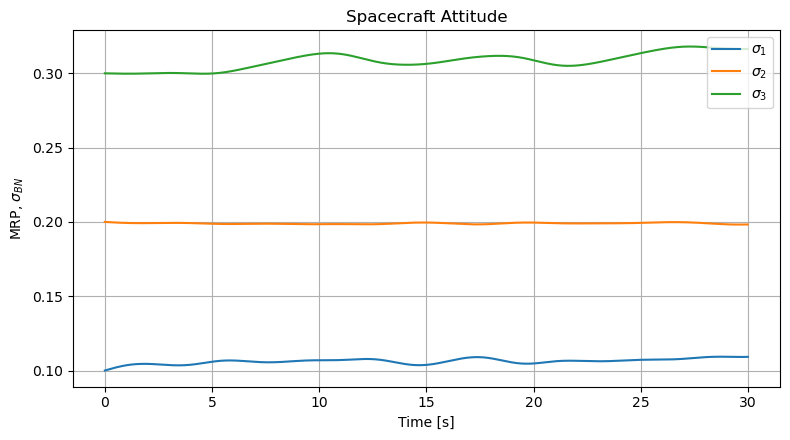

In [38]:
time = results["time"]

plt.figure(figsize=(8, 4.5))

plt.plot(time, results["sigma_BN"][:, 0], label=r"$\sigma_1$")
plt.plot(time, results["sigma_BN"][:, 1], label=r"$\sigma_2$")
plt.plot(time, results["sigma_BN"][:, 2], label=r"$\sigma_3$")

plt.xlabel("Time [s]")
plt.ylabel("MRP, $\\sigma_{BN}$")
plt.title("Spacecraft Attitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

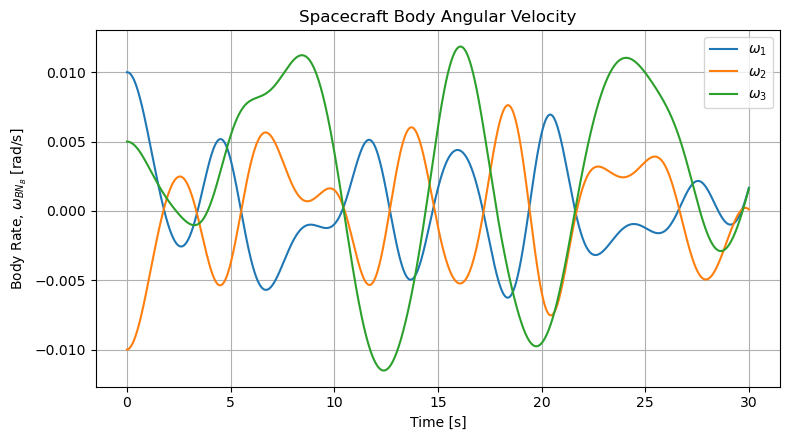

In [39]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["omega_BN_B"][:, 0], label=r"$\omega_1$")
plt.plot(time, results["omega_BN_B"][:, 1], label=r"$\omega_2$")
plt.plot(time, results["omega_BN_B"][:, 2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Body Rate, $\\omega_{BN_B}$ [rad/s]")
plt.title("Spacecraft Body Angular Velocity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

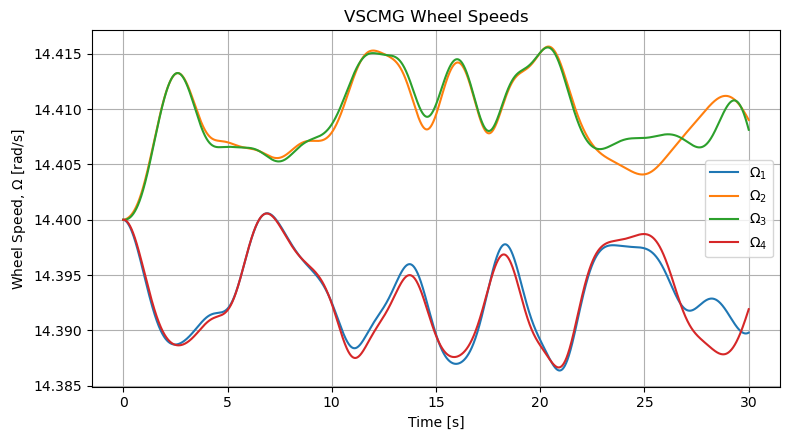

In [40]:
plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, results["Omega"][:, i], label=rf"$\Omega_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Wheel Speed, $\\Omega$ [rad/s]")
plt.title("VSCMG Wheel Speeds")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

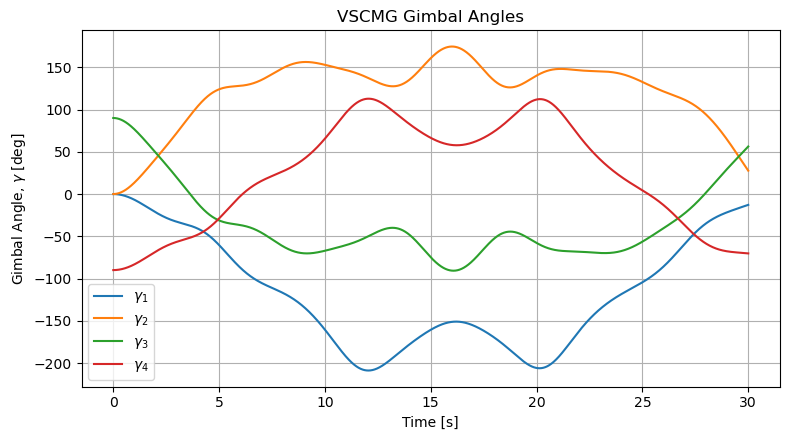

In [41]:
gamma_deg = np.rad2deg(results["gamma"])

plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, gamma_deg[:, i], label=rf"$\gamma_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Gimbal Angle, $\\gamma$ [deg]")
plt.title("VSCMG Gimbal Angles")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

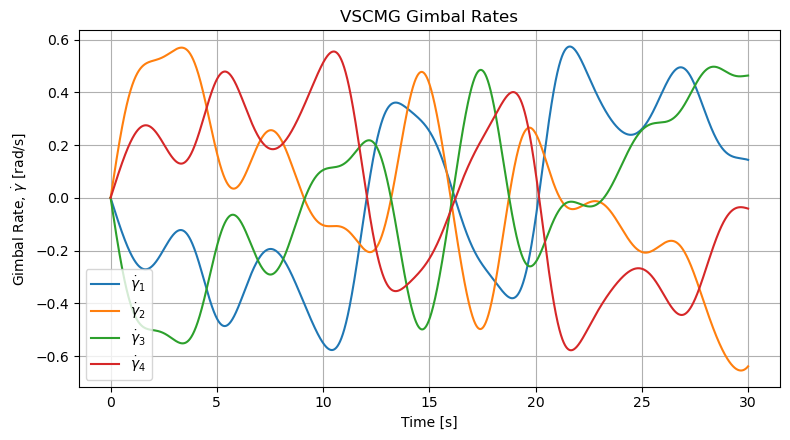

In [42]:
plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, results["gamma_dot"][:, i], label=rf"$\dot{{\gamma}}_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Gimbal Rate, $\\dot{\\gamma}$ [rad/s]")
plt.title("VSCMG Gimbal Rates")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

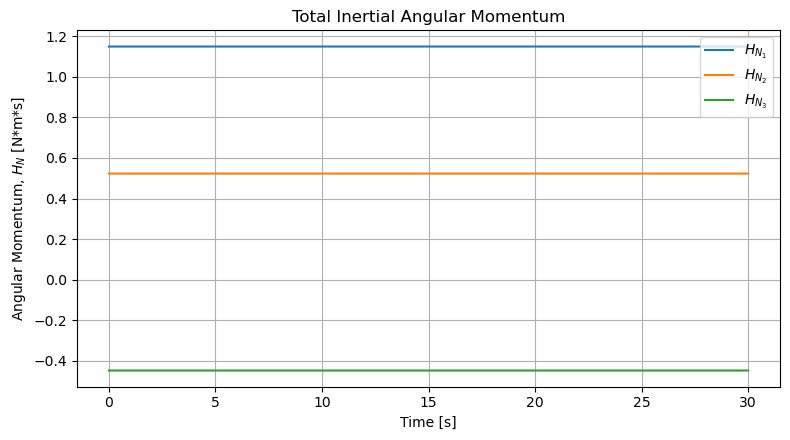

In [43]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["H_N"][:, 0], label=r"$H_{N_1}$")
plt.plot(time, results["H_N"][:, 1], label=r"$H_{N_2}$")
plt.plot(time, results["H_N"][:, 2], label=r"$H_{N_3}$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Momentum, $H_N$ [N*m*s]")
plt.title("Total Inertial Angular Momentum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

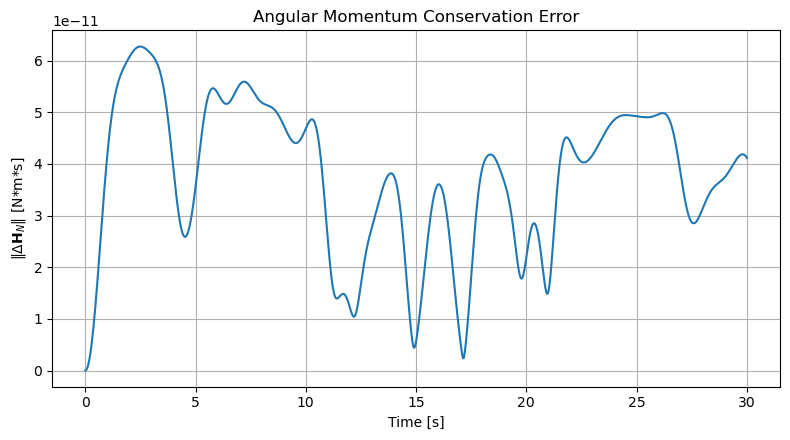

In [44]:
H_N_error = results["H_N"] - results["H_N"][0]
H_N_error_norm = np.linalg.norm(H_N_error, axis=1)

plt.figure(figsize=(8, 4.5))

plt.plot(time, H_N_error_norm)

plt.xlabel("Time [s]")
plt.ylabel(r"$\|\Delta\mathbf{H}_N\|$ [N*m*s]")
plt.title("Angular Momentum Conservation Error")
plt.grid(True)
plt.tight_layout()
plt.show()

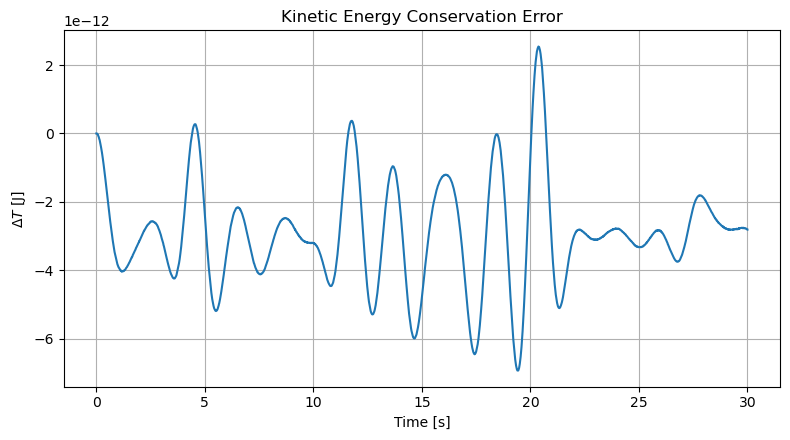

In [45]:
T_error = results["T"] - results["T"][0]

plt.figure(figsize=(8, 4.5))

plt.plot(time, T_error)

plt.xlabel("Time [s]")
plt.ylabel(r"$\Delta T$ [J]")
plt.title("Kinetic Energy Conservation Error")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.3 - Work-Energy Verification

In [46]:
# Quiz 10 external torque
L_B_quiz10 = np.array([0.1, 0.1, -0.1])

def quiz10_inputs(t, x):
    """Return the Quiz 10 external torque with zero VSCMG motor torques."""
    L_B = L_B_quiz10
    u_s = np.zeros(N)
    u_g = np.zeros(N)
    return L_B, u_s, u_g

In [47]:
t_0 = 0.0
t_f = 40.0
dt = 0.01

results_quiz10 = simulate_attitude_dynamics(
    model=attitude_model,
    x_0=x_0,
    t_0=t_0,
    t_f=t_f,
    dt=dt,
    input_function=quiz10_inputs
)

In [48]:
T_f = results_quiz10["T"][-1]
T_dot_analytical_f = results_quiz10["T_dot"][-1]

print(f"Final rotational kinetic energy, T(t_f) [J]:\n{T_f:.12f}")
print(f"\nAnalytical energy rate, T_dot(t_f) [J/s]:\n{T_dot_analytical_f:.12f}")

Final rotational kinetic energy, T(t_f) [J]:
41.531075960443

Analytical energy rate, T_dot(t_f) [J/s]:
0.004485754224


In [49]:
time = results_quiz10["time"]
T = results_quiz10["T"]

T_dot_numerical = np.gradient(T, time, edge_order=2)
T_dot_numerical_f = T_dot_numerical[-1]

print(f"Numerical energy rate, T_dot(t_f) [J/s]:\n{T_dot_numerical_f:.12f}")
print(f"\nAnalytical energy rate, T_dot(t_f) [J/s]:\n{T_dot_analytical_f:.12f}")
print(f"\nDifference [J/s]:\n{T_dot_numerical_f - T_dot_analytical_f:.3e}")

Numerical energy rate, T_dot(t_f) [J/s]:
0.004485687208

Analytical energy rate, T_dot(t_f) [J/s]:
0.004485754224

Difference [J/s]:
-6.702e-08


In [50]:
T_dot_backward_f = (results_quiz10["T"][-1] - results_quiz10["T"][-2]) / (results_quiz10["time"][-1] - results_quiz10["time"][-2])

print(f"Backward-difference energy rate, T_dot(t_f) [J/s]:\n{T_dot_backward_f:.12f}")

Backward-difference energy rate, T_dot(t_f) [J/s]:
0.004475855014


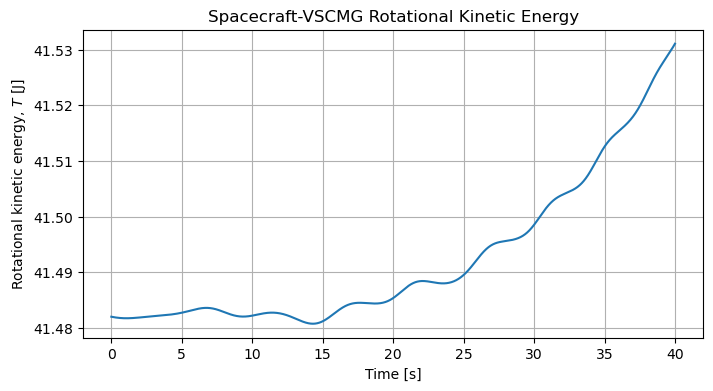

In [51]:
plt.figure(figsize=(8, 4))

plt.plot(
    results_quiz10["time"],
    results_quiz10["T"]
)

plt.xlabel("Time [s]")
plt.ylabel("Rotational kinetic energy, $T$ [J]")
plt.title("Spacecraft-VSCMG Rotational Kinetic Energy")
plt.grid(True)

plt.show()

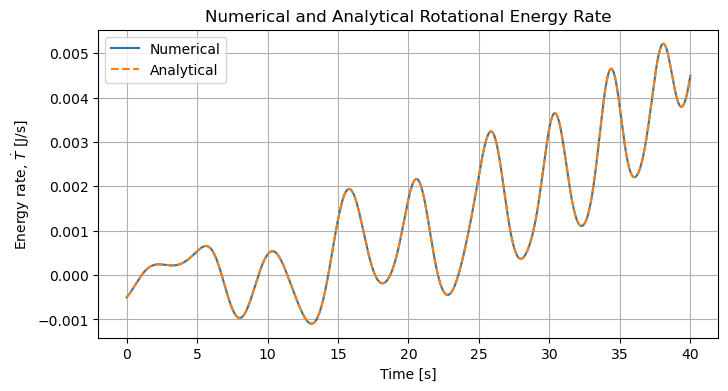

In [52]:
plt.figure(figsize=(8, 4))

plt.plot(
    results_quiz10["time"],
    T_dot_numerical,
    label="Numerical"
)

plt.plot(
    results_quiz10["time"],
    results_quiz10["T_dot"],
    "--",
    label="Analytical"
)

plt.xlabel("Time [s]")
plt.ylabel("Energy rate, $\\dot{T}$ [J/s]")
plt.title("Numerical and Analytical Rotational Energy Rate")
plt.legend()
plt.grid(True)

plt.show()

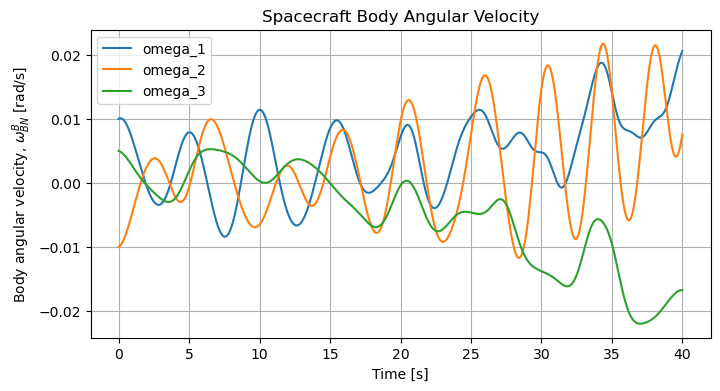

In [53]:
plt.figure(figsize=(8, 4))

plt.plot(
    results_quiz10["time"],
    results_quiz10["omega_BN_B"][:, 0],
    label="omega_1"
)

plt.plot(
    results_quiz10["time"],
    results_quiz10["omega_BN_B"][:, 1],
    label="omega_2"
)

plt.plot(
    results_quiz10["time"],
    results_quiz10["omega_BN_B"][:, 2],
    label="omega_3"
)

plt.xlabel("Time [s]")
plt.ylabel("Body angular velocity, $\\omega_{BN}^B$ [rad/s]")
plt.title("Spacecraft Body Angular Velocity")
plt.legend()
plt.grid(True)

plt.show()

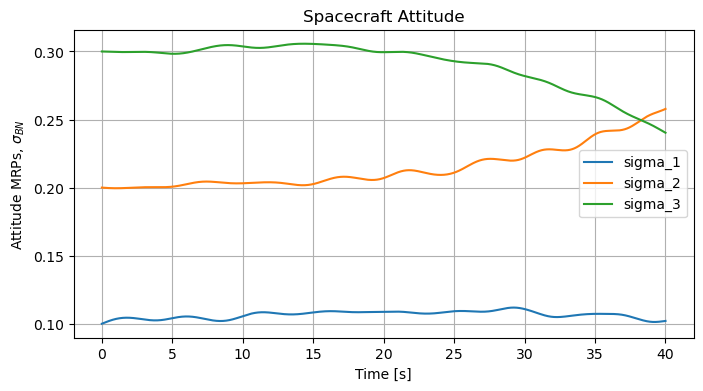

In [54]:
plt.figure(figsize=(8, 4))

plt.plot(
    results_quiz10["time"],
    results_quiz10["sigma_BN"][:, 0],
    label="sigma_1"
)

plt.plot(
    results_quiz10["time"],
    results_quiz10["sigma_BN"][:, 1],
    label="sigma_2"
)

plt.plot(
    results_quiz10["time"],
    results_quiz10["sigma_BN"][:, 2],
    label="sigma_3"
)

plt.xlabel("Time [s]")
plt.ylabel("Attitude MRPs, $\\sigma_{BN}$")
plt.title("Spacecraft Attitude")
plt.legend()
plt.grid(True)

plt.show()

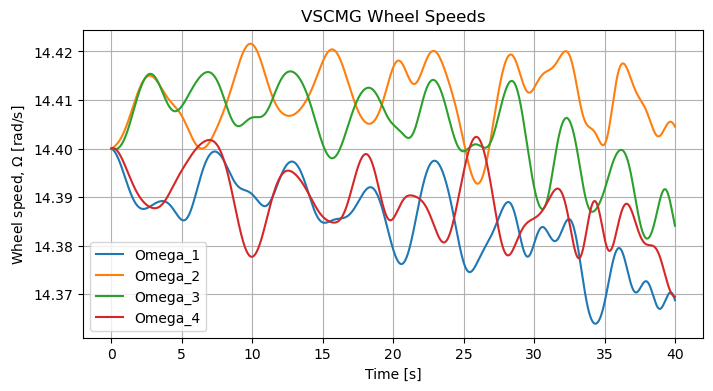

In [55]:
plt.figure(figsize=(8, 4))

for i in range(N):
    plt.plot(
        results_quiz10["time"],
        results_quiz10["Omega"][:, i],
        label=f"Omega_{i + 1}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Wheel speed, $\\Omega$ [rad/s]")
plt.title("VSCMG Wheel Speeds")
plt.legend()
plt.grid(True)

plt.show()

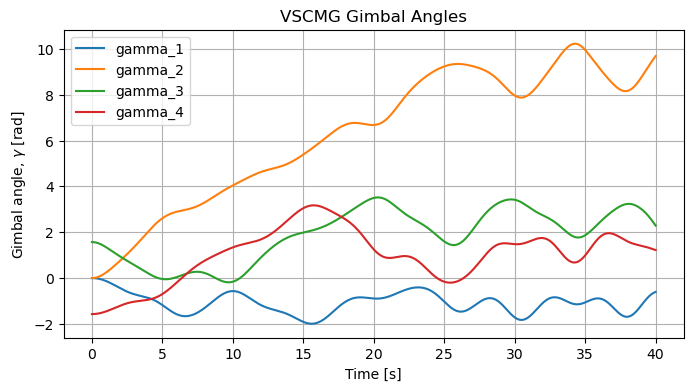

In [56]:
plt.figure(figsize=(8, 4))

for i in range(N):
    plt.plot(
        results_quiz10["time"],
        results_quiz10["gamma"][:, i],
        label=f"gamma_{i + 1}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Gimbal angle, $\\gamma$ [rad]")
plt.title("VSCMG Gimbal Angles")
plt.legend()
plt.grid(True)

plt.show()

---

Notes & Codes Structured by John G.